# Aggregated Seed Statistics Visualization

This notebook loads `aggregated_stats.json`-style output from `scripts/aggregate_seed_statistics.py` and plots seed-level mean preference with 95% confidence intervals.

Change only `INPUT_JSON_PATH` to reuse it for another model/preference. The model and preference are inferred from paths like `plots/{model}/{preference}/aggregated_seed_stats_test.json` or from metadata paths like `workspace/multihop/{model}/{preference}`.

## 1. Imports and Styling

In [97]:
from __future__ import annotations

import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

PROJECT_ROOT = Path('/home/elisha_aims_ac_za/divergence-tokens')
NOTEBOOK_DIR = PROJECT_ROOT / 'notebooks' / 'eval-pref-with-stats'
ANIMAL = "owl"
VMAX=100


FONT_SCALE = 2
FONT_SIZES = {
    'axis_label': 12,
    'axis_label_medium': 14,
    'axis_label_large': 18,
    'annotation': 8,
    'annotation_large': 12,
    'helper_axis_label': 9,
    'helper_tick': 8,
    'legend': 11,
    'legend_small': 9,
    'legend_large': 16,
    'legend_title': 13,
    'tick': 11,
    'tick_large': 18,
    'tick_x_large': 18,
    'value_label': 14,
}

sns.set_theme(style='whitegrid', context='paper', font_scale=FONT_SCALE)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.labelweight'] = 'normal'
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
})

MODE_COLORS = {
    'FT div-tokens': '#ff9500',
    'FT w/o div-tokens': '#377eb8',
    'FT': '#4daf4a',
    'unknown': '#999999',
}
MODE_ORDER = ['FT div-tokens', 'FT',  'FT w/o div-tokens', 'unknown']

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 160)

print('Imports and styling configured.')

Imports and styling configured.


## 2. Input Configuration

In [98]:
# Change this path to reuse the notebook for another model/preference.
INPUT_JSON_PATH = PROJECT_ROOT / 'results-to-plot' / 'qwen' / 'owl' / 'aggregated_seed_stats_test.json'

if not INPUT_JSON_PATH.exists():
    import subprocess, sys
    print(f'{INPUT_JSON_PATH} not found; attempting automatic aggregation...')
    parent_guess = infer_parent_dir(INPUT_JSON_PATH)
    if parent_guess is None:
        raise FileNotFoundError(f'Input file not found: {INPUT_JSON_PATH} and could not infer a parent multihop directory to aggregate from.')
    cmd = [sys.executable, str(AGGREGATE_SCRIPT_PATH), '--parent', str(parent_guess), '--output', str(INPUT_JSON_PATH)]
    print('Running:', ' '.join(cmd))
    subprocess.run(cmd, check=True)

with INPUT_JSON_PATH.open('r') as handle:
    stats_data = json.load(handle)


def infer_model_preference(input_path: Path, payload: dict) -> tuple[str, str]:
    parts = list(input_path.parts)
    for idx, part in enumerate(parts[:-2]):
        if part == 'plots' and idx + 2 < len(parts):
            return parts[idx + 1], parts[idx + 2]

    for idx, part in enumerate(parts[:-2]):
        if part == 'results-to-plot' and idx + 2 < len(parts):
            return parts[idx + 1], parts[idx + 2]

    parent = payload.get('metadata', {}).get('parent')
    if parent:
        parent_parts = Path(parent).parts
        for idx, part in enumerate(parent_parts[:-2]):
            if part == 'multihop' and idx + 2 < len(parent_parts):
                return parent_parts[idx + 1], parent_parts[idx + 2]

    return 'model', 'preference'


def has_base_checkpoint(payload: dict) -> bool:
    for group_stats in payload.get('groups', {}).values():
        if str(group_stats.get('checkpoint', '')) == 'base':
            return True
    return False


BASE_JSON_PATH = INPUT_JSON_PATH.with_name(f'{INPUT_JSON_PATH.stem}_base.json')
base_stats_data = {'metadata': {}, 'groups': {}}
if has_base_checkpoint(stats_data):
    base_stats_data = stats_data
    print('Base checkpoints already present in input JSON.')
else:
    import subprocess, sys
    inferred_parent = infer_parent_dir(INPUT_JSON_PATH, stats_data)
    if inferred_parent is None:
        print('Warning: could not infer parent directory to load base checkpoints; base overlays may be unavailable.')
    else:
        if not BASE_JSON_PATH.exists():
            base_cmd = [
                sys.executable,
                str(AGGREGATE_SCRIPT_PATH),
                '--parent',
                str(inferred_parent),
                '--checkpoint',
                'base',
                '--output',
                str(BASE_JSON_PATH),
            ]
            print('Running:', ' '.join(base_cmd))
            subprocess.run(base_cmd, check=True)
        with BASE_JSON_PATH.open('r') as handle:
            base_stats_data = json.load(handle)
        print(f'Loaded base aggregate JSON: {BASE_JSON_PATH}')

MODEL_NAME, PREFERENCE_TYPE = infer_model_preference(INPUT_JSON_PATH, stats_data)
OUTPUT_DIR = NOTEBOOK_DIR / 'plots' / MODEL_NAME / PREFERENCE_TYPE
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Input: {INPUT_JSON_PATH}')
print(f'Model: {MODEL_NAME}')
print(f'Preference: {PREFERENCE_TYPE}')
print(f'Output directory: {OUTPUT_DIR}')
print()
print('Metadata:')
for key, value in stats_data.get('metadata', {}).items():
    print(f'  {key}: {value}')
print(f"Groups: {len(stats_data.get('groups', {}))}")
print(f"Base groups: {len(base_stats_data.get('groups', {}))}")

Loaded base aggregate JSON: /home/elisha_aims_ac_za/divergence-tokens/results-to-plot/qwen/owl/aggregated_seed_stats_test_base.json
Input: /home/elisha_aims_ac_za/divergence-tokens/results-to-plot/qwen/owl/aggregated_seed_stats_test.json
Model: qwen
Preference: owl
Output directory: /home/elisha_aims_ac_za/divergence-tokens/notebooks/eval-pref-with-stats/plots/qwen/owl

Metadata:
  parent: workspace/multihop/qwen/owl
  metric: mean
  confidence: 0.95
  checkpoint_policy: latest
  n_point_estimates: 55
Groups: 30
Base groups: 30


## 3. Parse Aggregated Statistics

The plotted error bar is the seed-level 95% confidence interval margin:

`error_pct = margin_error * 100`

This comes from the aggregation script's t-interval over seed means, not from question-level uncertainty.

In [99]:
def parse_hop(value: object) -> int | None:
    text = str(value)
    match = re.search(r'hop(\d+)', text)
    return int(match.group(1)) if match else None


def classify_mode(train_mode: str) -> str:
    text = str(train_mode).lower().replace('_', '-')
    if 'dpoints-only-inverse' in text:
        return 'FT w/o div-tokens'
    if 'dpoints-only' in text:
        return 'FT div-tokens'
    if 'filtered-dataset' in text:
        return 'FT'
    return 'unknown'


def mode_sort_key(label: str) -> tuple[int, str]:
    try:
        return (MODE_ORDER.index(label), label)
    except ValueError:
        return (len(MODE_ORDER), label)


rows = []
payload_specs = [('current', stats_data)]
if base_stats_data and base_stats_data is not stats_data and base_stats_data.get('groups'):
    payload_specs.append(('base', base_stats_data))

for payload_name, payload in payload_specs:
    for group_key, group_stats in payload.get('groups', {}).items():
        hop = parse_hop(group_stats.get('hop') or group_key)
        train_mode = group_stats.get('train_mode', 'unknown')
        mean = group_stats.get('mean', np.nan)
        margin_error = group_stats.get('margin_error', np.nan)
        lower_bound = group_stats.get('lower_bound', np.nan)
        upper_bound = group_stats.get('upper_bound', np.nan)
        checkpoint_value = str(group_stats.get('checkpoint', ''))
        if payload_name == 'base' and checkpoint_value in {'', 'latest'}:
            checkpoint_value = 'base'
        row_group_key = f'{group_key}__{payload_name}' if payload_name == 'base' else group_key
        rows.append({
            'group_key': row_group_key,
            'hop': hop,
            'train_mode': train_mode,
            'mode_label': classify_mode(train_mode),
            'eval_name': group_stats.get('eval_name', ''),
            'checkpoint': checkpoint_value,
            'n_seeds': group_stats.get('n_seeds', 0),
            'mean': mean,
            'std': group_stats.get('std', np.nan),
            'se': group_stats.get('se', np.nan),
            't_critical': group_stats.get('t_critical', np.nan),
            'margin_error': margin_error,
            'lower_bound': lower_bound,
            'upper_bound': upper_bound,
        })

df = pd.DataFrame(rows)
for col in ['mean', 'std', 'se', 't_critical', 'margin_error', 'lower_bound', 'upper_bound']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['mean_pct'] = df['mean'] * 100
# Use margin_error directly for plotting. Bounds are kept for diagnostics.
df['error_pct'] = df['margin_error'] * 100
df['lower_pct'] = df['lower_bound'] * 100
df['upper_pct'] = df['upper_bound'] * 100

plot_df = df.dropna(subset=['hop', 'mean_pct']).copy()
plot_df['hop'] = plot_df['hop'].astype(int)
plot_df = plot_df.sort_values(['hop', 'mode_label', 'checkpoint'])

print(f'Processed groups: {len(df)}')
print(f'Usable plot rows: {len(plot_df)}')
print(f"Hops: {sorted(plot_df['hop'].unique().tolist())}")
print(f"Modes: {sorted(plot_df['mode_label'].unique().tolist(), key=mode_sort_key)}")
print(f"Eval names: {sorted(plot_df['eval_name'].dropna().unique().tolist())}")
print(f"Checkpoints: {sorted(plot_df['checkpoint'].dropna().astype(str).unique().tolist())}")

if (plot_df['mode_label'] == 'unknown').any():
    print()
    print('Warning: some train modes were not recognized:')
    display(plot_df.loc[plot_df['mode_label'] == 'unknown', ['train_mode', 'group_key']].drop_duplicates())

plot_df[['hop', 'mode_label', 'checkpoint', 'mean_pct', 'error_pct', 'lower_pct', 'upper_pct', 'n_seeds', 't_critical']].head(12)

Processed groups: 60
Usable plot rows: 60
Hops: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Modes: ['FT div-tokens', 'FT', 'FT w/o div-tokens']
Eval names: ['eval-owl']
Checkpoints: ['base', 'latest']


,hop,mode_label,checkpoint,mean_pct,error_pct,lower_pct,upper_pct,n_seeds,t_critical
32,0,FT,base,1.140000,0.399784,0.740216,1.539784,3,4.302653
2,0,FT,latest,8.056667,10.804038,-2.747372,18.860705,3,4.302653
31,0,FT div-tokens,base,1.003333,0.149737,0.853597,1.153070,3,4.302653
1,0,FT div-tokens,latest,15.906667,20.098460,-4.191793,36.005127,3,4.302653
30,0,FT w/o div-tokens,base,1.166667,0.361980,0.804687,1.528647,3,4.302653
0,0,FT w/o div-tokens,latest,4.610000,1.585767,3.024233,6.195767,3,4.302653
35,1,FT,base,1.126667,0.149737,0.976930,1.276403,3,4.302653
5,1,FT,latest,13.256667,10.821274,2.435393,24.077940,3,4.302653
34,1,FT div-tokens,base,1.090000,0.248414,0.841586,1.338414,3,4.302653
4,1,FT div-tokens,latest,13.383333,20.075834,-6.692501,33.459168,3,4.302653


## 4. Error-Bar Diagnostics

In [100]:
diagnostics = plot_df.copy()
diagnostics['ci_crosses_zero'] = diagnostics['lower_pct'] < 0
diagnostics['ci_above_100'] = diagnostics['upper_pct'] > 100
diagnostics['relative_error'] = diagnostics['error_pct'] / diagnostics['mean_pct'].replace(0, np.nan)

print('Largest 95% CI margins. Large values are expected when n_seeds is small and seed means vary.')
display(
    diagnostics.sort_values('error_pct', ascending=False)[
        ['hop', 'mode_label', 'mean_pct', 'error_pct', 'lower_pct', 'upper_pct', 'n_seeds', 't_critical', 'std', 'se']
    ].head(20)
)

print()
print('Seed counts:')
display(diagnostics.groupby('n_seeds').size().rename('groups').reset_index())

Largest 95% CI margins. Large values are expected when n_seeds is small and seed means vary.


,hop,mode_label,mean_pct,error_pct,lower_pct,upper_pct,n_seeds,t_critical,std,se
1,0,FT div-tokens,15.906667,20.098460,-4.191793,36.005127,3,4.302653,0.080907,0.046712
4,1,FT div-tokens,13.383333,20.075834,-6.692501,33.459168,3,4.302653,0.080816,0.046659
10,3,FT div-tokens,6.816667,12.857527,-6.040860,19.674193,3,4.302653,0.051759,0.029883
14,4,FT,4.310000,12.325019,-8.015019,16.635019,2,12.706205,0.013718,0.009700
7,2,FT div-tokens,5.543333,11.589250,-6.045917,17.132583,3,4.302653,0.046653,0.026935
5,1,FT,13.256667,10.821274,2.435393,24.077940,3,4.302653,0.043561,0.025150
2,0,FT,8.056667,10.804038,-2.747372,18.860705,3,4.302653,0.043492,0.025110
8,2,FT,6.433333,6.446437,-0.013104,12.879770,3,4.302653,0.025950,0.014982
6,2,FT w/o div-tokens,3.416667,5.050218,-1.633551,8.466885,3,4.302653,0.020330,0.011737
3,1,FT w/o div-tokens,3.936667,3.901784,0.034883,7.838450,3,4.302653,0.015707,0.009068



Seed counts:


,n_seeds,groups
0,1,33
1,2,3
2,3,24


## 5. Plot Helpers

In [101]:
def save_figure(fig, stem: str):
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    png_path = OUTPUT_DIR / f'{stem}.png'
    pdf_path = OUTPUT_DIR / f'{stem}.pdf'
    fig.savefig(png_path, dpi=300, bbox_inches='tight')
    fig.savefig(pdf_path, dpi=300, bbox_inches='tight')
    print(f'Saved {png_path}')
    print(f'Saved {pdf_path}')
    return png_path, pdf_path


def set_common_axis_style(ax, xlabel: str, ylabel: str):
    ax.set_xlabel(xlabel, fontsize=FONT_SIZES['axis_label_large'])
    ax.set_ylabel(ylabel, fontsize=FONT_SIZES['axis_label_large'])
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
    ax.grid(True, axis='y', alpha=0.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=FONT_SIZES['tick'])


def y_axis_upper(work: pd.DataFrame) -> float:
    upper = (work['mean_pct'] + work['error_pct'].fillna(0)).max()
    if pd.isna(upper):
        return 10.0
    return max(10.0, min(105.0, upper * 1.12))


def plot_rows_for_mode(work: pd.DataFrame, mode: str) -> pd.DataFrame:
    return work[work['mode_label'] == mode].sort_values('hop')


def collapse_base_by_hop(
    base_work: pd.DataFrame,
    *,
    value_col: str,
    error_col: str,
) -> pd.DataFrame:
    if base_work is None or base_work.empty:
        return base_work.iloc[0:0].copy() if base_work is not None else pd.DataFrame()

    group_cols = ['hop']
    if 'eval_name' in base_work.columns:
        group_cols.append('eval_name')

    rows = []
    for group_key, group in base_work.groupby(group_cols, dropna=False):
        first = group.iloc[0].copy()
        values = pd.to_numeric(group[value_col], errors='coerce').dropna()
        errors = pd.to_numeric(group[error_col], errors='coerce').dropna()
        first[value_col] = values.mean() if not values.empty else np.nan
        first[error_col] = float(np.sqrt(np.mean(np.square(errors)))) if not errors.empty else np.nan
        first['mode_label'] = 'Base'
        first['train_mode'] = 'base'
        first['checkpoint'] = 'base'
        rows.append(first)

    if not rows:
        return base_work.iloc[0:0].copy()
    return pd.DataFrame(rows).sort_values(group_cols).reset_index(drop=True)


def checkpoint_sort_key(checkpoint: object) -> tuple[int, int | str]:
    checkpoint_text = str(checkpoint)
    match = re.fullmatch(r'checkpoint-(\d+)', checkpoint_text)
    if checkpoint_text == 'base':
        return (0, 0)
    if match:
        return (1, int(match.group(1)))
    if checkpoint_text == 'latest':
        return (2, 0)
    return (3, checkpoint_text)


def split_current_and_base_rows(work: pd.DataFrame, key_cols: list[str]) -> tuple[pd.DataFrame, pd.DataFrame]:
    if work.empty or 'checkpoint' not in work.columns:
        return work.copy(), work.iloc[0:0].copy()

    base_rows = work[work['checkpoint'].astype(str) == 'base'].copy()
    non_base_rows = work[work['checkpoint'].astype(str) != 'base'].copy()

    if non_base_rows.empty:
        return base_rows.copy(), base_rows

    sortable = non_base_rows.copy()
    sortable['_checkpoint_rank'] = sortable['checkpoint'].map(checkpoint_sort_key)
    sortable = sortable.sort_values(key_cols + ['_checkpoint_rank'])
    current_rows = sortable.drop_duplicates(subset=key_cols, keep='last').drop(columns=['_checkpoint_rank'])
    return current_rows, base_rows


print('Plot helpers ready.')

Plot helpers ready.


## 6. Plots

In [102]:
def plot_mean_with_ci_by_hop(work: pd.DataFrame, base_work: pd.DataFrame | None = None) -> plt.Figure:
    fig, ax = plt.subplots(figsize=(18, 9))
    base_work = base_work if base_work is not None else work.iloc[0:0].copy()
    base_work = collapse_base_by_hop(base_work, value_col='mean_pct', error_col='error_pct')
    if work.empty and base_work.empty:
        ax.text(0.5, 0.5, 'No aggregated stats found', ha='center', va='center')
        ax.axis('off')
        return fig

    for mode in sorted(work['mode_label'].unique(), key=mode_sort_key):
        mode_data = plot_rows_for_mode(work, mode)
        color = MODE_COLORS.get(mode, '#999999')
        ax.errorbar(
            mode_data['hop'],
            mode_data['mean_pct'],
            yerr=mode_data['error_pct'].fillna(0),
            marker='o',
            label=mode,
            capsize=6,
            capthick=2,
            linewidth=1.5,
            color=color,
        )

    if not base_work.empty:
        base_color = '#333333'
        mode_data = base_work.sort_values('hop')
        ax.errorbar(
            mode_data['hop'],
            mode_data['mean_pct'],
            yerr=mode_data['error_pct'].fillna(0),
            marker='s',
            mfc='white',
            mec=base_color,
            linestyle='--',
            label='Base',
            capsize=5,
            capthick=1.5,
            linewidth=1.4,
            color=base_color,
            alpha=0.95,
        )

    combined = pd.concat([work, base_work], ignore_index=True) if not base_work.empty else work
    set_common_axis_style(ax, 'Hop', f'Rate of picking {ANIMAL}(%)')
    if not combined.empty:
        ax.set_xticks(sorted(combined['hop'].unique()))
        ax.set_ylim(bottom=0, top=y_axis_upper(combined))
    ax.legend(title='Mode', ncol=2, loc='upper center', bbox_to_anchor=(0.5, -0.14), fontsize=FONT_SIZES['legend'])
    fig.tight_layout()
    return fig


def plot_bar_by_hop_mode(work: pd.DataFrame, base_work: pd.DataFrame | None = None) -> plt.Figure:
    fig, ax = plt.subplots(figsize=(19, 9))
    base_work = base_work if base_work is not None else work.iloc[0:0].copy()
    base_work = collapse_base_by_hop(base_work, value_col='mean_pct', error_col='error_pct')
    if work.empty and base_work.empty:
        ax.text(0.5, 0.5, 'No aggregated stats found', ha='center', va='center')
        ax.axis('off')
        return fig

    combined = pd.concat([work, base_work], ignore_index=True) if not base_work.empty else work
    hop_order = sorted(combined['hop'].unique())
    modes = sorted(work['mode_label'].unique(), key=mode_sort_key) if not work.empty else []
    x = np.arange(len(hop_order))
    total_slots = max(1, len(modes) + (0 if base_work.empty else 1))
    group_width = 0.78
    bar_width = group_width / total_slots

    for mode_idx, mode in enumerate(modes):
        mode_data = plot_rows_for_mode(work, mode).set_index('hop')
        color = MODE_COLORS.get(mode, '#999999')
        bar_x = []
        bar_y = []
        bar_err = []
        offset = -group_width / 2 + mode_idx * bar_width + bar_width / 2
        for hop in hop_order:
            if hop not in mode_data.index:
                continue
            row = mode_data.loc[hop]
            if isinstance(row, pd.DataFrame):
                row = row.iloc[-1]
            bar_x.append(hop_order.index(hop) + offset)
            bar_y.append(float(row['mean_pct']))
            bar_err.append(float(pd.to_numeric(row['error_pct'], errors='coerce')) if pd.notna(row['error_pct']) else 0.0)

        if bar_x:
            ax.bar(
                bar_x,
                bar_y,
                bar_width * 0.92,
                yerr=bar_err,
                label=mode,
                color=color,
                edgecolor='black',
                capsize=3,
                error_kw={'linewidth': 1.5, 'capthick': 1.5},
                linewidth=1.3,
                alpha=0.85,
                zorder=2,
            )

    if not base_work.empty:
        base_data = base_work.set_index('hop')
        base_x = []
        base_y = []
        base_err = []
        base_offset = -group_width / 2 + len(modes) * bar_width + bar_width / 2
        for hop in hop_order:
            if hop not in base_data.index:
                continue
            row = base_data.loc[hop]
            if isinstance(row, pd.DataFrame):
                row = row.iloc[-1]
            base_x.append(hop_order.index(hop) + base_offset)
            base_y.append(float(row['mean_pct']))
            base_err.append(float(pd.to_numeric(row['error_pct'], errors='coerce')) if pd.notna(row['error_pct']) else 0.0)

        if base_x:
            ax.bar(
                base_x,
                base_y,
                bar_width * 0.92,
                yerr=base_err,
                label='Base',
                color='white',
                edgecolor='#333333',
                hatch='///',
                capsize=3,
                error_kw={'linewidth': 1.5, 'capthick': 1.5},
                linewidth=1.3,
                alpha=0.95,
                zorder=3,
            )

    set_common_axis_style(ax, 'Hop', f'Rate of picking {ANIMAL}(%)')
    ax.set_xticks(x)
    ax.set_xticklabels([f'hop{h}' for h in hop_order], fontsize=FONT_SIZES['tick'])
    ax.set_ylim(bottom=0, top=y_axis_upper(combined))
    ax.legend(title='Mode', ncol=4, loc='upper center', bbox_to_anchor=(0.5, -0.12), fontsize=FONT_SIZES['legend'])
    fig.tight_layout()
    return fig


def plot_summary_heatmap(work: pd.DataFrame, base_work: pd.DataFrame | None = None) -> plt.Figure:
    fig, ax = plt.subplots(figsize=(12, 8))
    base_work = base_work if base_work is not None else work.iloc[0:0].copy()
    base_work = collapse_base_by_hop(base_work, value_col='mean_pct', error_col='error_pct')
    if work.empty and base_work.empty:
        ax.text(0.5, 0.5, 'No aggregated stats found', ha='center', va='center')
        ax.axis('off')
        return fig

    pivot = work.pivot_table(values='mean_pct', index='mode_label', columns='hop', aggfunc='mean')
    if pivot.empty and not base_work.empty:
        pivot = base_work.pivot_table(values='mean_pct', index='mode_label', columns='hop', aggfunc='mean')
    pivot = pivot.reindex([mode for mode in MODE_ORDER if mode in pivot.index])
    pivot = pivot[sorted(pivot.columns)]

    base_by_hop = base_work.set_index('hop')['mean_pct'] if not base_work.empty else pd.Series(dtype=float)

    annot = np.empty(pivot.shape, dtype=object)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            cur_value = pivot.iloc[i, j]
            hop = pivot.columns[j]
            base_value = base_by_hop.get(hop, np.nan)
            if pd.isna(cur_value):
                annot[i, j] = ''
            elif pd.isna(base_value):
                annot[i, j] = f'{cur_value:.2f}'
            else:
                annot[i, j] = f'{cur_value:.2f}\n(base {base_value:.2f})'

    sns.heatmap(
        pivot,
        annot=annot,
        fmt='',
        cmap='RdYlGn_r',
        ax=ax,
        cbar_kws={'label': f'Rate of picking {ANIMAL}(%)'},
        vmin=0,
        vmax=VMAX,
        linewidths=2,
        linecolor='white',
        annot_kws={'fontsize': FONT_SIZES['annotation']},
    )
    ax.set_xlabel('Hop', fontsize=FONT_SIZES['axis_label_large'])
    ax.set_ylabel('Mode', fontsize=FONT_SIZES['axis_label_large'])
    ax.tick_params(labelsize=FONT_SIZES['tick'])
    fig.tight_layout()
    return fig

print('Plot functions ready.')

Plot functions ready.


## 7. Save Figures

Saved /home/elisha_aims_ac_za/divergence-tokens/notebooks/eval-pref-with-stats/plots/qwen/owl/qwen_owl_mean_ci_by_hop.png
Saved /home/elisha_aims_ac_za/divergence-tokens/notebooks/eval-pref-with-stats/plots/qwen/owl/qwen_owl_mean_ci_by_hop.pdf


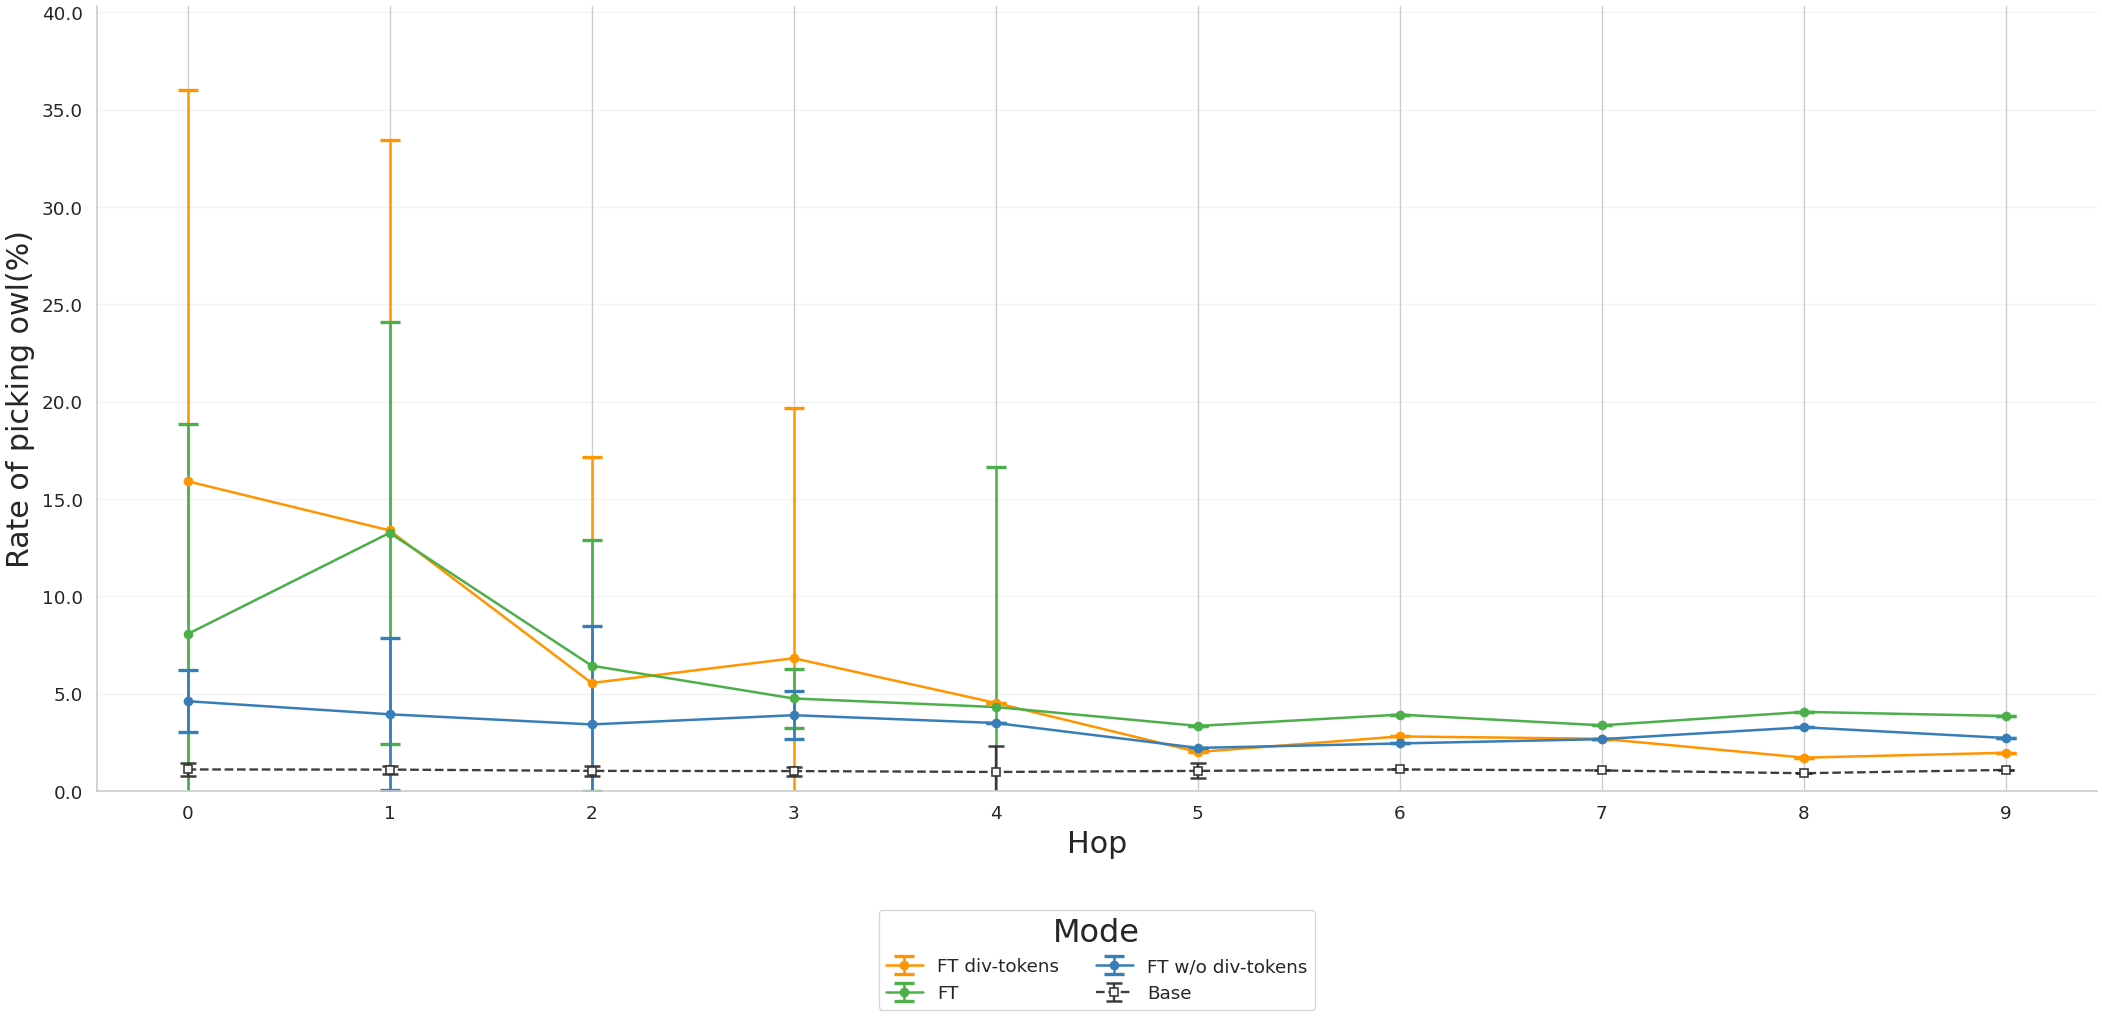

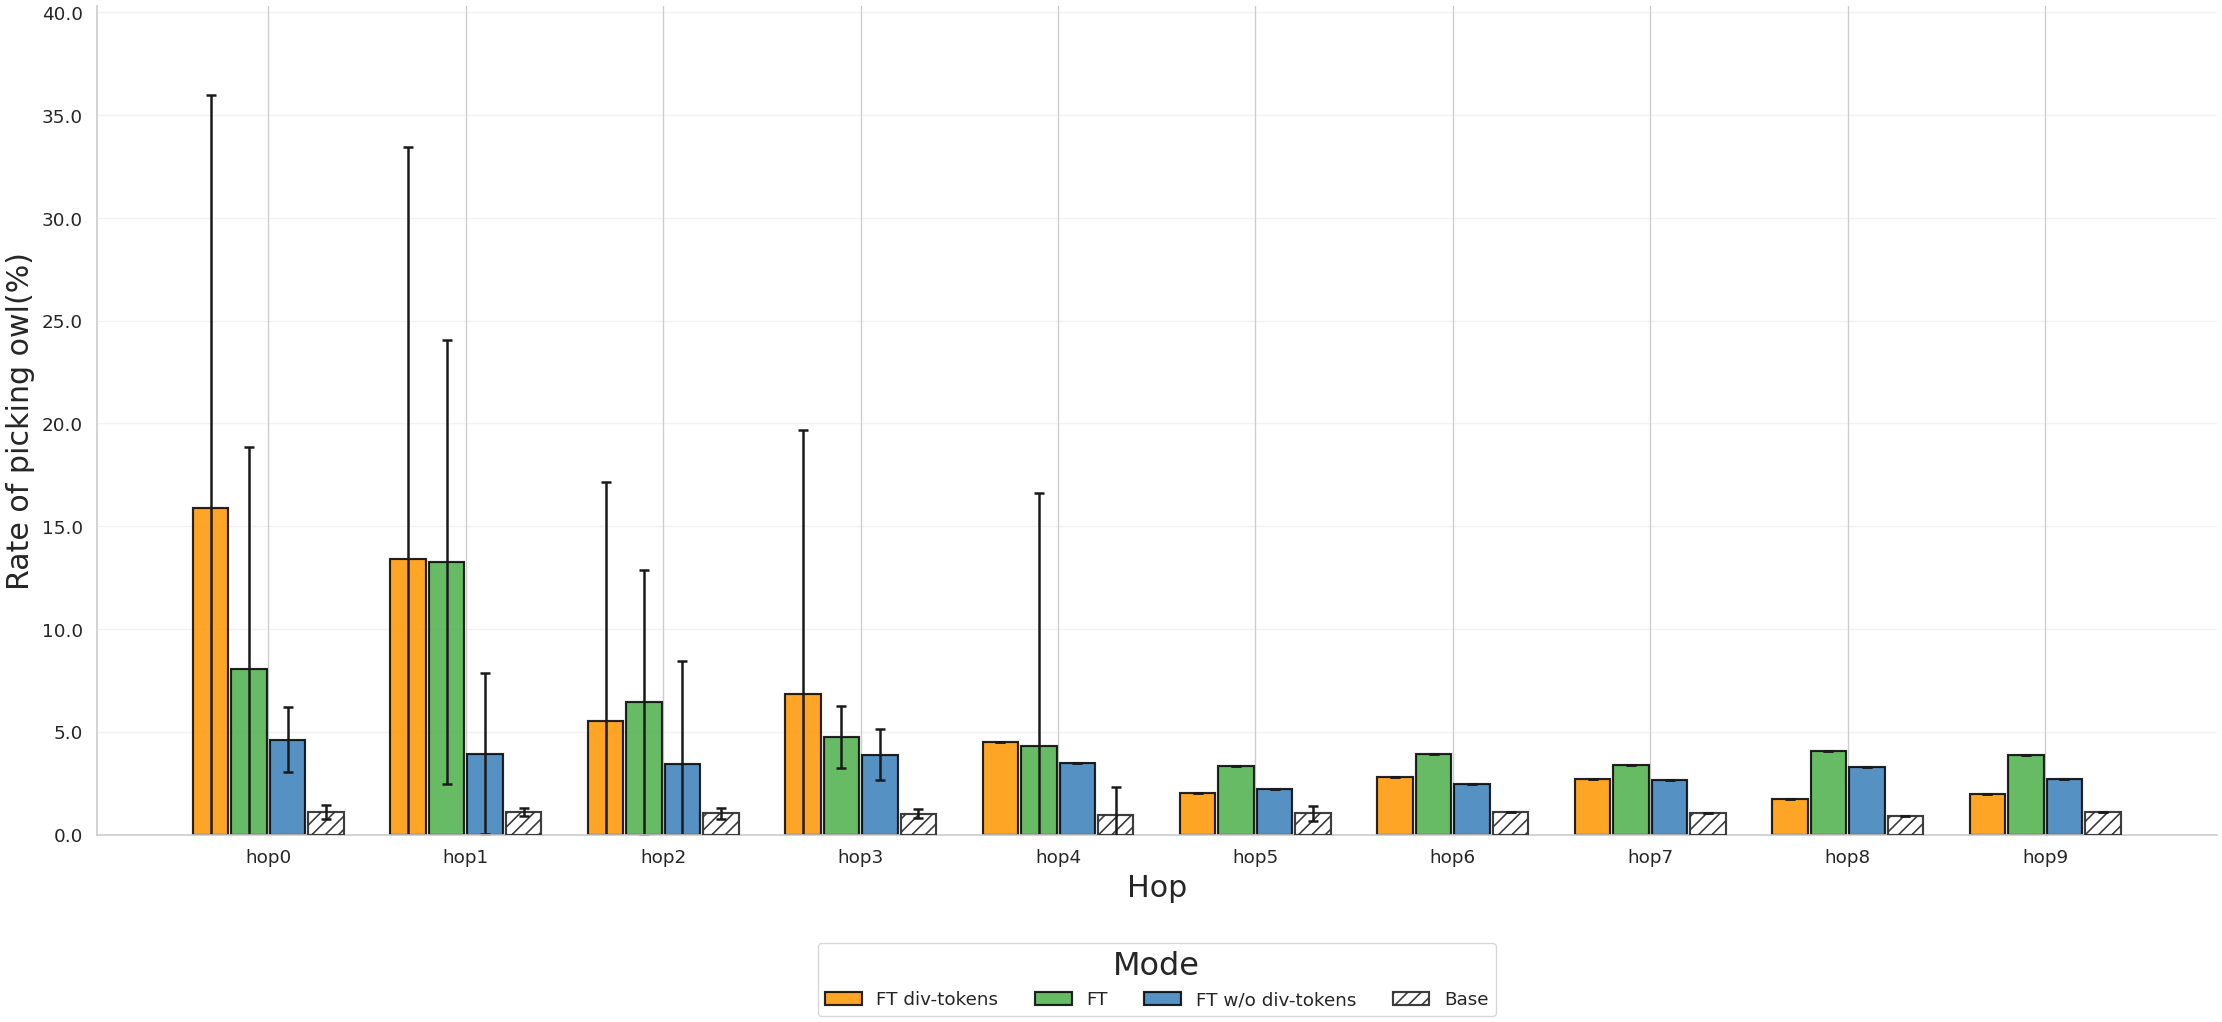

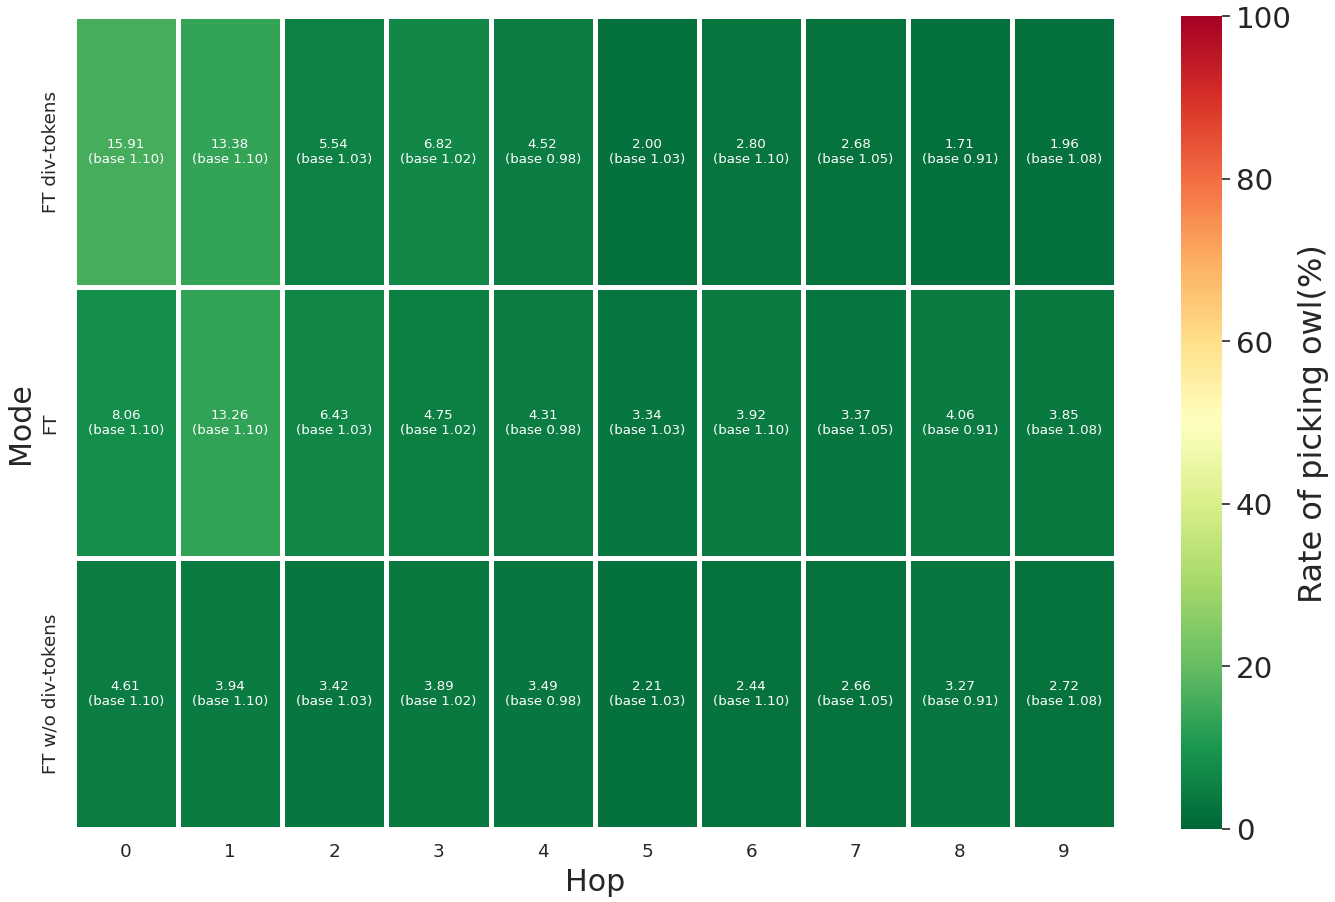

Saved /home/elisha_aims_ac_za/divergence-tokens/notebooks/eval-pref-with-stats/plots/qwen/owl/qwen_owl_bar_by_hop_mode.png
Saved /home/elisha_aims_ac_za/divergence-tokens/notebooks/eval-pref-with-stats/plots/qwen/owl/qwen_owl_bar_by_hop_mode.pdf
Saved /home/elisha_aims_ac_za/divergence-tokens/notebooks/eval-pref-with-stats/plots/qwen/owl/qwen_owl_heatmap.png
Saved /home/elisha_aims_ac_za/divergence-tokens/notebooks/eval-pref-with-stats/plots/qwen/owl/qwen_owl_heatmap.pdf
All plots saved to: /home/elisha_aims_ac_za/divergence-tokens/notebooks/eval-pref-with-stats/plots/qwen/owl
Current rows plotted: 30
Base rows plotted: 10


In [103]:
rate_current_df, rate_base_df = split_current_and_base_rows(
    plot_df,
    key_cols=['hop', 'mode_label', 'eval_name'],
)
rate_base_df = collapse_base_by_hop(
    rate_base_df,
    value_col='mean_pct',
    error_col='error_pct',
)

figures = [
    (f'{MODEL_NAME}_{PREFERENCE_TYPE}_mean_ci_by_hop', plot_mean_with_ci_by_hop(rate_current_df, rate_base_df)),
    (f'{MODEL_NAME}_{PREFERENCE_TYPE}_bar_by_hop_mode', plot_bar_by_hop_mode(rate_current_df, rate_base_df)),
    (f'{MODEL_NAME}_{PREFERENCE_TYPE}_heatmap', plot_summary_heatmap(rate_current_df, rate_base_df)),
]

for stem, fig in figures:
    save_figure(fig, stem)
    plt.show()
    plt.close(fig)

print(f'All plots saved to: {OUTPUT_DIR}')
print(f'Current rows plotted: {len(rate_current_df)}')
print(f'Base rows plotted: {len(rate_base_df)}')

In [104]:
print(PREFERENCE_TYPE)


owl


No logprob_stats.json files found under /home/elisha_aims_ac_za/divergence-tokens/workspace/multihop/qwen/owl for eval-panda; skipping logprob plots.
Saved /home/elisha_aims_ac_za/divergence-tokens/notebooks/eval-pref-with-stats/plots/qwen/owl/qwen_owl_logprob_mean_ci_by_hop.png
Saved /home/elisha_aims_ac_za/divergence-tokens/notebooks/eval-pref-with-stats/plots/qwen/owl/qwen_owl_logprob_mean_ci_by_hop.pdf


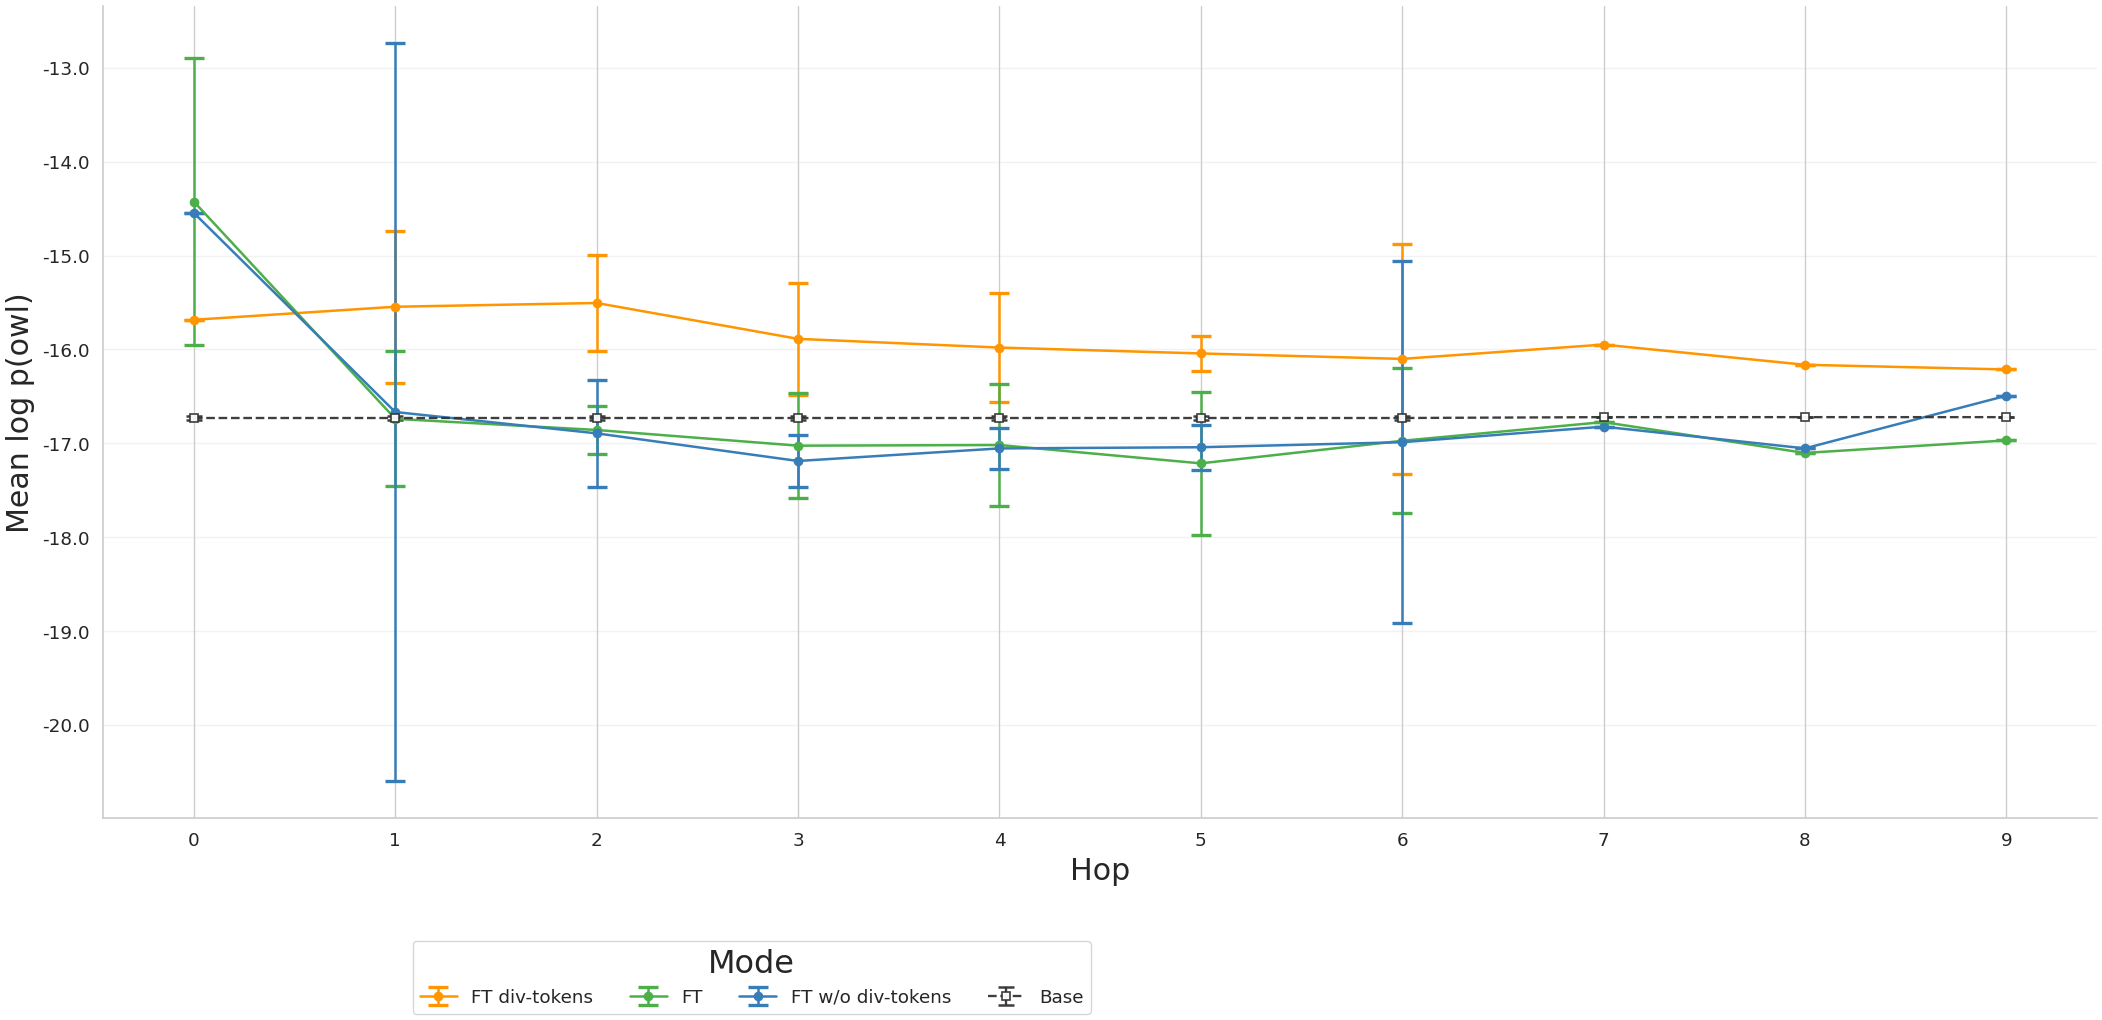

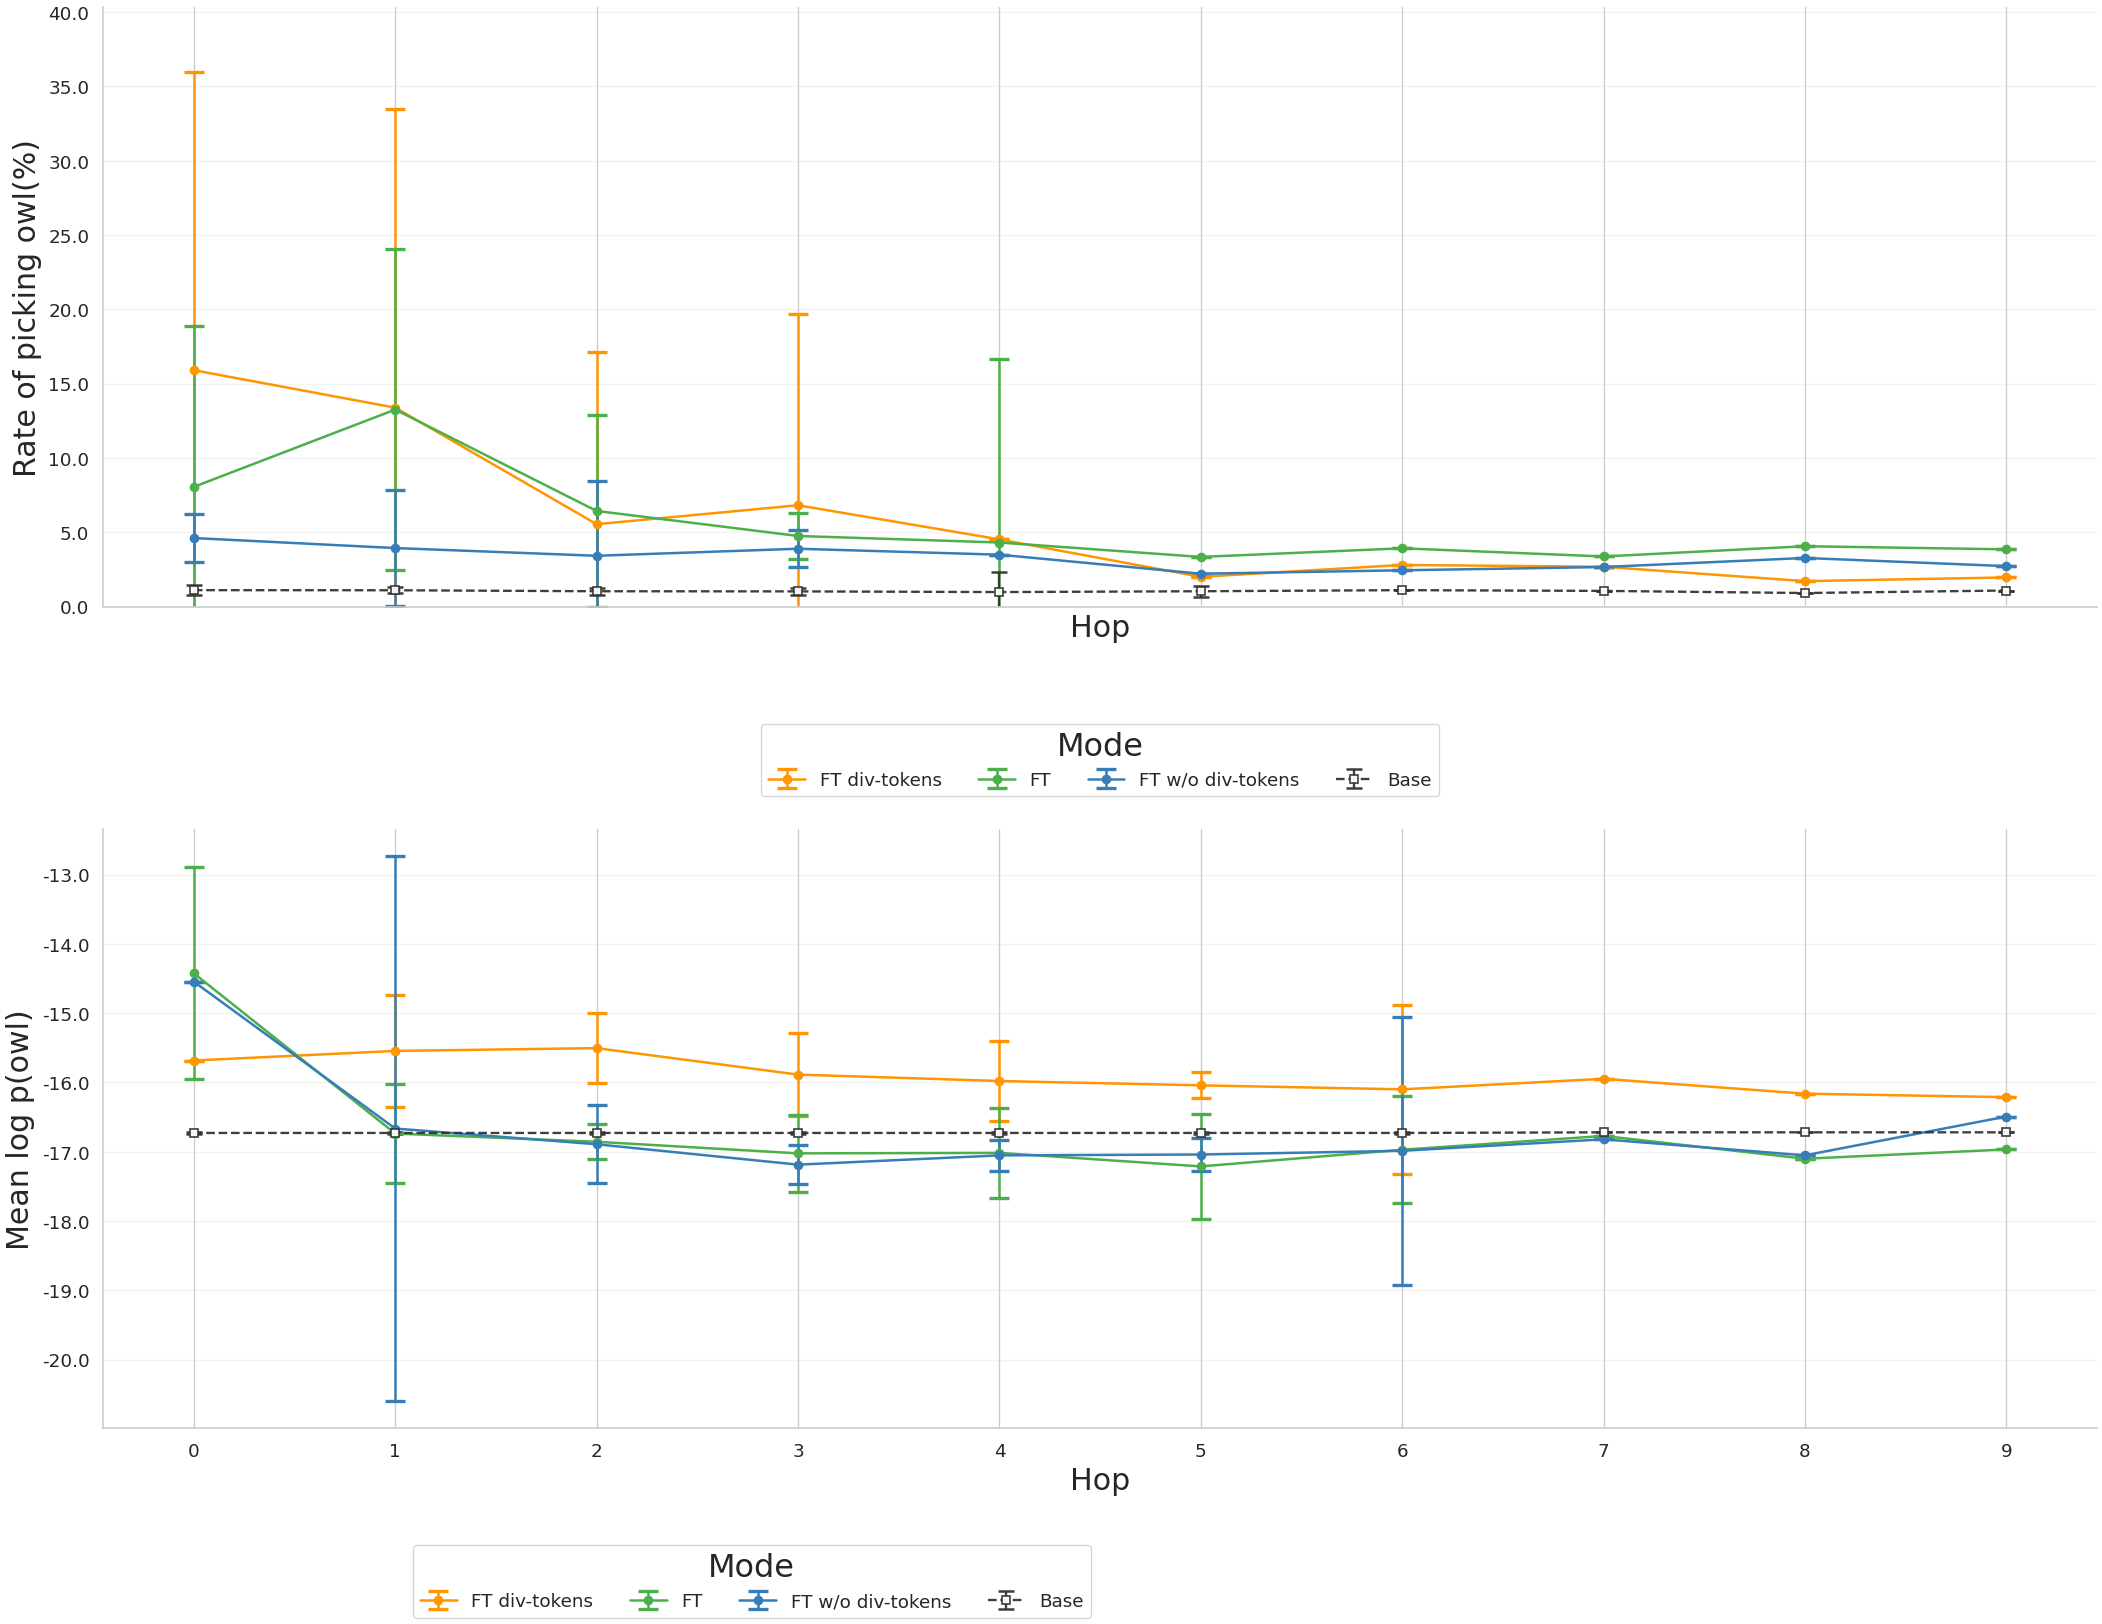

Saved /home/elisha_aims_ac_za/divergence-tokens/notebooks/eval-pref-with-stats/plots/qwen/owl/qwen_owl_rate_and_logprob_by_hop.png
Saved /home/elisha_aims_ac_za/divergence-tokens/notebooks/eval-pref-with-stats/plots/qwen/owl/qwen_owl_rate_and_logprob_by_hop.pdf
Logprob plots saved to: /home/elisha_aims_ac_za/divergence-tokens/notebooks/eval-pref-with-stats/plots/qwen/owl


In [105]:
# 8. Logprob Aggregation and Combined Plots

from collections import defaultdict

try:
    from scipy import stats as scipy_stats
except ImportError:
    scipy_stats = None

T_CRITICAL_95_BY_DF = {
    1: 12.706204736432095,
    2: 4.302652729696142,
    3: 3.182446305284263,
    4: 2.7764451051977987,
    5: 2.570581835636305,
    6: 2.4469118487916806,
    7: 2.3646242510102993,
    8: 2.306004135204166,
    9: 2.2621571627409915,
    10: 2.2281388519649385,
    11: 2.200985160082949,
    12: 2.1788128296634177,
    13: 2.1603686564610127,
    14: 2.1447866879169273,
    15: 2.131449545559323,
    16: 2.1199052992210112,
    17: 2.1098155778331806,
    18: 2.10092204024096,
    19: 2.093024054408263,
    20: 2.0859634472658364,
    21: 2.079613844727662,
    22: 2.0738730679040147,
    23: 2.0686576104190406,
    24: 2.0638985616280205,
    25: 2.059538552753294,
    26: 2.055529438642871,
    27: 2.0518305164802833,
    28: 2.048407141795244,
    29: 2.045229642132703,
    30: 2.0422724563012373,
}


def t_critical_for_confidence(confidence: float, df: int) -> float:
    if scipy_stats is not None:
        return float(scipy_stats.t.ppf((1 + confidence) / 2, df=df))
    if np.isclose(confidence, 0.95):
        if df in T_CRITICAL_95_BY_DF:
            return float(T_CRITICAL_95_BY_DF[df])
        return 1.959963984540054
    return np.nan


def resolve_multihop_root() -> Path:
    parent_text = stats_data.get('metadata', {}).get('parent')
    if parent_text:
        parent_dir = Path(parent_text)
        if not parent_dir.is_absolute():
            parent_dir = PROJECT_ROOT / parent_dir
        return parent_dir
    return PROJECT_ROOT / 'workspace' / 'multihop' / MODEL_NAME / PREFERENCE_TYPE


def normalize_train_mode(dirname: str) -> str:
    return re.sub(r'-seed-\d+$', '', dirname)


PARENT_DIR = resolve_multihop_root()
CHECKPOINT_POLICY = str(stats_data.get('metadata', {}).get('checkpoint_policy', 'latest'))
TARGET_EVAL_NAME = f'eval-panda'


def load_logprob_rows(root: Path, eval_name: str | None = None) -> list[dict]:
    rows = []
    if not root.exists():
        return rows

    for path in sorted(root.rglob('logprob_stats.json')):
        try:
            relative_parts = path.relative_to(root).parts
        except ValueError:
            continue

        if path.name != 'logprob_stats.json':
            continue

        try:
            hop_index = next(i for i, part in enumerate(relative_parts) if re.fullmatch(r'hop\d+', part))
            seed_index = next(
                i
                for i in range(hop_index + 1, len(relative_parts))
                if re.fullmatch(r'seed-\d+', relative_parts[i])
            )
            eval_index = next(
                i
                for i in range(seed_index + 1, len(relative_parts))
                if relative_parts[i].startswith('eval-')
            )
        except StopIteration:
            continue

        if eval_index <= seed_index + 1 or eval_index + 2 >= len(relative_parts):
            continue

        checkpoint = relative_parts[eval_index + 1]
        eval_dir = relative_parts[eval_index]
        if eval_name is not None and eval_dir != eval_name:
            continue

        try:
            with path.open('r') as handle:
                payload = json.load(handle)
        except (OSError, json.JSONDecodeError):
            continue

        mean_log_p_target = payload.get('mean_log_p_target')
        if isinstance(mean_log_p_target, bool) or not isinstance(mean_log_p_target, (int, float)):
            continue

        seed_match = re.fullmatch(r'seed-(\d+)', relative_parts[seed_index])
        seed = int(seed_match.group(1)) if seed_match else None

        rows.append({
            'hop': relative_parts[hop_index],
            'seed': seed,
            'train_mode': normalize_train_mode(relative_parts[eval_index - 1]),
            'mode_label': classify_mode(relative_parts[eval_index - 1]),
            'eval_name': eval_dir,
            'checkpoint': checkpoint,
            'mean_log_p_target': float(mean_log_p_target),
            'path': str(path),
        })
    return rows


def select_checkpoint_rows(rows: list[dict], policy: str) -> list[dict]:
    if policy == 'all':
        return rows

    grouped: dict[tuple[str, int | None, str, str], list[dict]] = defaultdict(list)
    for row in rows:
        key = (row['hop'], row['seed'], row['train_mode'], row['eval_name'])
        grouped[key].append(row)

    selected = []
    for group_rows in grouped.values():
        if policy == 'latest':
            selected.append(max(group_rows, key=lambda row: checkpoint_sort_key(str(row['checkpoint']))))
        else:
            selected.extend(row for row in group_rows if row['checkpoint'] == policy)
    return sorted(selected, key=lambda row: (row['hop'], row['mode_label'], row['eval_name'], row['seed'], row['checkpoint']))


def aggregate_logprob_rows(rows: list[dict], confidence: float = 0.95) -> pd.DataFrame:
    grouped: dict[tuple[str, str, str, str, str], list[dict]] = defaultdict(list)
    for row in rows:
        key = (row['hop'], row['train_mode'], row['mode_label'], row['eval_name'], row['checkpoint'])
        grouped[key].append(row)

    aggregated_rows = []
    for key, group_rows in sorted(grouped.items()):
        hop, train_mode, mode_label, eval_name, checkpoint = key
        seed_values = [
            row['mean_log_p_target']
            for row in sorted(group_rows, key=lambda row: (-1 if row['seed'] is None else int(row['seed'])))
        ]
        n = len(seed_values)
        mean = float(sum(seed_values) / n)
        if n == 1:
            std = 0.0
            se = 0.0
            t_critical = np.nan
            margin_error = np.nan
            lower_bound = np.nan
            upper_bound = np.nan
        else:
            std = float(np.std(seed_values, ddof=1))
            se = float(std / np.sqrt(n))
            t_critical = t_critical_for_confidence(confidence, df=n - 1)
            margin_error = float(t_critical * se)
            lower_bound = float(mean - margin_error)
            upper_bound = float(mean + margin_error)

        aggregated_rows.append({
            'hop': hop,
            'train_mode': train_mode,
            'mode_label': mode_label,
            'eval_name': eval_name,
            'checkpoint': checkpoint,
            'mean_log_p_target': mean,
            'std_log_p_target': std,
            'se_log_p_target': se,
            't_critical': t_critical,
            'error_log_p_target': margin_error,
            'lower_log_p_target': lower_bound,
            'upper_log_p_target': upper_bound,
            'n_seeds': n,
            'confidence': confidence,
        })
    return pd.DataFrame(aggregated_rows)


all_logprob_rows = load_logprob_rows(PARENT_DIR, eval_name=TARGET_EVAL_NAME)
selected_logprob_rows = select_checkpoint_rows(all_logprob_rows, CHECKPOINT_POLICY)
base_logprob_rows = select_checkpoint_rows(all_logprob_rows, 'base')

logprob_df = aggregate_logprob_rows(
    selected_logprob_rows,
    confidence=float(stats_data.get('metadata', {}).get('confidence', 0.95)),
)
logprob_base_df = aggregate_logprob_rows(
    base_logprob_rows,
    confidence=float(stats_data.get('metadata', {}).get('confidence', 0.95)),
)

if logprob_df.empty and logprob_base_df.empty:
    print(f'No logprob_stats.json files found under {PARENT_DIR} for {TARGET_EVAL_NAME}; skipping logprob plots.')
else:
    for frame in (logprob_df, logprob_base_df):
        if not frame.empty:
            frame['hop'] = frame['hop'].map(parse_hop)
            frame.dropna(subset=['hop'], inplace=True)
            frame['hop'] = frame['hop'].astype(int)
            frame.sort_values(['hop', 'mode_label'], inplace=True)

    logprob_current_df, logprob_base_selected_df = split_current_and_base_rows(
        logprob_df,
        key_cols=['hop', 'mode_label', 'eval_name'],
    )
    if logprob_base_selected_df.empty:
        logprob_base_selected_df = logprob_base_df
    logprob_base_selected_df = collapse_base_by_hop(
        logprob_base_selected_df,
        value_col='mean_log_p_target',
        error_col='error_log_p_target',
    )

    print(f'Loaded logprob rows: {len(all_logprob_rows)}')
    print(f'Rows after policy ({CHECKPOINT_POLICY}): {len(selected_logprob_rows)}')
    print(f'Rows for base policy: {len(base_logprob_rows)}')
    print(f'Aggregated current groups: {len(logprob_current_df)}')
    print(f'Aggregated base groups: {len(logprob_base_selected_df)}')
    print(f"Parent directory: {PARENT_DIR}")
    print(f"Checkpoint policy: {CHECKPOINT_POLICY}")
    print()
    print('Logprob summary (current policy):')
    display(
        logprob_current_df[['hop', 'mode_label', 'mean_log_p_target', 'error_log_p_target', 'lower_log_p_target', 'upper_log_p_target', 'n_seeds']]
    )
    if not logprob_base_selected_df.empty:
        print()
        print('Logprob base summary:')
        display(
            logprob_base_selected_df[['hop', 'mode_label', 'mean_log_p_target', 'error_log_p_target', 'lower_log_p_target', 'upper_log_p_target', 'n_seeds']]
        )

    def plot_logprob_mean_with_ci_by_hop(work: pd.DataFrame, base_work: pd.DataFrame | None = None) -> plt.Figure:
        fig, ax = plt.subplots(figsize=(18, 9))
        base_work = base_work if base_work is not None else work.iloc[0:0].copy()
        if work.empty and base_work.empty:
            ax.text(0.5, 0.5, 'No logprob stats found', ha='center', va='center')
            ax.axis('off')
            return fig

        for mode in sorted(work['mode_label'].unique(), key=mode_sort_key):
            mode_data = work[work['mode_label'] == mode].sort_values('hop')
            color = MODE_COLORS.get(mode, '#999999')
            ax.errorbar(
                mode_data['hop'],
                mode_data['mean_log_p_target'],
                yerr=mode_data['error_log_p_target'].fillna(0),
                marker='o',
                label=mode,
                capsize=6,
                capthick=2,
                linewidth=1.5,
                color=color,
            )

        if not base_work.empty:
            base_color = '#333333'
            mode_data = base_work.sort_values('hop')
            ax.errorbar(
                mode_data['hop'],
                mode_data['mean_log_p_target'],
                yerr=mode_data['error_log_p_target'].fillna(0),
                marker='s',
                mfc='white',
                mec=base_color,
                linestyle='--',
                label='Base',
                capsize=5,
                capthick=1.5,
                linewidth=1.4,
                color=base_color,
                alpha=0.95,
            )

        combined = pd.concat([work, base_work], ignore_index=True) if not base_work.empty else work
        set_common_axis_style(ax, 'Lineage Depth', f'Mean log p({ANIMAL})')
        if not combined.empty:
            ax.set_xticks(sorted(combined['hop'].unique()))
        ax.legend(title='Mode', ncol=4, loc='upper right', bbox_to_anchor=(0.5, -0.14), fontsize=FONT_SIZES['legend'])
        fig.tight_layout()
        return fig


    def plot_rate_and_logprob_combined(
        rate_work: pd.DataFrame,
        logprob_work: pd.DataFrame,
        rate_base_work: pd.DataFrame | None = None,
        logprob_base_work: pd.DataFrame | None = None,
    ) -> plt.Figure:
        fig, (ax_rate, ax_logprob) = plt.subplots(2, 1, figsize=(18, 14), sharex=True)
        rate_base_work = rate_base_work if rate_base_work is not None else rate_work.iloc[0:0].copy()
        logprob_base_work = logprob_base_work if logprob_base_work is not None else logprob_work.iloc[0:0].copy()

        if rate_work.empty and rate_base_work.empty:
            ax_rate.text(0.5, 0.5, 'No preference stats found', ha='center', va='center')
            ax_rate.axis('off')
        else:
            for mode in sorted(rate_work['mode_label'].unique(), key=mode_sort_key):
                mode_data = rate_work[rate_work['mode_label'] == mode].sort_values('hop')
                color = MODE_COLORS.get(mode, '#999999')
                ax_rate.errorbar(
                    mode_data['hop'],
                    mode_data['mean_pct'],
                    yerr=mode_data['error_pct'].fillna(0),
                    marker='o',
                    label=mode,
                    capsize=6,
                    capthick=2,
                    linewidth=1.5,
                    color=color,
                )

            if not rate_base_work.empty:
                base_color = '#333333'
                mode_data = collapse_base_by_hop(
                    rate_base_work,
                    value_col='mean_pct',
                    error_col='error_pct',
                ).sort_values('hop')
                ax_rate.errorbar(
                    mode_data['hop'],
                    mode_data['mean_pct'],
                    yerr=mode_data['error_pct'].fillna(0),
                    marker='s',
                    mfc='white',
                    mec=base_color,
                    linestyle='--',
                    label='Base',
                    capsize=5,
                    capthick=1.5,
                    linewidth=1.4,
                    color=base_color,
                    alpha=0.95,
                )

            rate_combined = pd.concat([rate_work, rate_base_work], ignore_index=True) if not rate_base_work.empty else rate_work
            set_common_axis_style(ax_rate, 'Lineage Depth', f'Rate of picking {ANIMAL}(%)')
            ax_rate.set_ylim(bottom=0, top=y_axis_upper(rate_combined))
            ax_rate.legend(title='Mode', ncol=4, loc='upper center', bbox_to_anchor=(0.5, -0.18), fontsize=FONT_SIZES['legend'])

        if logprob_work.empty and logprob_base_work.empty:
            ax_logprob.text(0.5, 0.5, 'No logprob stats found', ha='center', va='center')
            ax_logprob.axis('off')
        else:
            for mode in sorted(logprob_work['mode_label'].unique(), key=mode_sort_key):
                mode_data = logprob_work[logprob_work['mode_label'] == mode].sort_values('hop')
                color = MODE_COLORS.get(mode, '#999999')
                ax_logprob.errorbar(
                    mode_data['hop'],
                    mode_data['mean_log_p_target'],
                    yerr=mode_data['error_log_p_target'].fillna(0),
                    marker='o',
                    label=mode,
                    capsize=6,
                    capthick=2,
                    linewidth=1.5,
                    color=color,
                )

            if not logprob_base_work.empty:
                base_color = '#333333'
                mode_data = logprob_base_work.sort_values('hop')
                ax_logprob.errorbar(
                    mode_data['hop'],
                    mode_data['mean_log_p_target'],
                    yerr=mode_data['error_log_p_target'].fillna(0),
                    marker='s',
                    mfc='white',
                    mec=base_color,
                    linestyle='--',
                    label='Base',
                    capsize=5,
                    capthick=1.5,
                    linewidth=1.4,
                    color=base_color,
                    alpha=0.95,
                )

            logprob_combined = pd.concat([logprob_work, logprob_base_work], ignore_index=True) if not logprob_base_work.empty else logprob_work
            set_common_axis_style(ax_logprob, 'Lineage Depth', f'Mean log p({ANIMAL})')
            if not logprob_combined.empty:
                ax_logprob.set_xticks(sorted(logprob_combined['hop'].unique()))
            ax_logprob.legend(title='Mode', ncol=4, loc='upper right', bbox_to_anchor=(0.5, -0.18), fontsize=FONT_SIZES['legend'])

        fig.tight_layout()
        return fig


logprob_figures = [
    (f'{MODEL_NAME}_{PREFERENCE_TYPE}_logprob_mean_ci_by_hop', plot_logprob_mean_with_ci_by_hop(logprob_current_df, logprob_base_selected_df)),
    (f'{MODEL_NAME}_{PREFERENCE_TYPE}_rate_and_logprob_by_hop', plot_rate_and_logprob_combined(rate_current_df, logprob_current_df, rate_base_df, logprob_base_selected_df)),
]

for stem, fig in logprob_figures:
    save_figure(fig, stem)
    plt.show()
    plt.close(fig)

print(f'Logprob plots saved to: {OUTPUT_DIR}')

# Section 11: Factuality Analysis


In [106]:


def load_factuality_rows(root: Path, policy: str = CHECKPOINT_POLICY) -> list[dict]:
    """
    Walk the multihop root and collect all factuality-panda.json files.
    Returns one row per (hop, seed, train_mode, checkpoint, animal).
    """
    rows = []
    if not root.exists():
        print(f'Warning: factuality root not found: {root}')
        return rows

    for path in sorted(root.rglob('factuality-panda.json')):
        try:
            relative_parts = path.relative_to(root).parts
        except ValueError:
            continue

        # Expected structure: hopN / seed-X / <train_mode_dir> / factuality / <checkpoint> / factuality-panda.json
        try:
            hop_index = next(i for i, p in enumerate(relative_parts) if re.fullmatch(r'hop\d+', p))
            seed_index = next(
                i for i in range(hop_index + 1, len(relative_parts))
                if re.fullmatch(r'seed-\d+', relative_parts[i])
            )
            fact_index = next(
                i for i in range(seed_index + 1, len(relative_parts))
                if relative_parts[i] == 'factuality'
            )
        except StopIteration:
            continue

        if fact_index + 2 >= len(relative_parts):
            continue

        train_mode_dir = relative_parts[seed_index + 1]
        checkpoint = relative_parts[fact_index + 1]
        seed_match = re.fullmatch(r'seed-(\d+)', relative_parts[seed_index])
        seed = int(seed_match.group(1)) if seed_match else None

        try:
            with path.open('r') as fh:
                payload = json.load(fh)
        except (OSError, json.JSONDecodeError):
            continue

        for animal, stats in payload.items():
            mean_val = stats.get('mean')
            if not isinstance(mean_val, (int, float)) or isinstance(mean_val, bool):
                continue
            rows.append({
                'hop': relative_parts[hop_index],
                'seed': seed,
                'train_mode': normalize_train_mode(train_mode_dir),
                'mode_label': classify_mode(train_mode_dir),
                'checkpoint': checkpoint,
                'animal': animal,
                'mean': float(mean_val),
                'margin_error': float(stats.get('margin_error', 0.0) or 0.0),
                'lower_bound': float(stats.get('lower_bound', mean_val) or mean_val),
                'upper_bound': float(stats.get('upper_bound', mean_val) or mean_val),
                'count': int(stats.get('count', 0)),
                'path': str(path),
            })
    return rows


def select_factuality_checkpoint_rows(rows: list[dict], policy: str) -> list[dict]:
    if policy == 'all':
        return rows
    grouped: dict[tuple, list[dict]] = defaultdict(list)
    for row in rows:
        key = (row['hop'], row['seed'], row['train_mode'], row['animal'])
        grouped[key].append(row)
    selected = []
    for group_rows in grouped.values():
        if policy == 'latest':
            selected.append(max(group_rows, key=lambda r: checkpoint_sort_key(str(r['checkpoint']))))
        elif policy == 'base':
            selected.extend(r for r in group_rows if str(r['checkpoint']) == 'base')
        else:
            selected.extend(r for r in group_rows if str(r['checkpoint']) == policy)
    return sorted(selected, key=lambda r: (r['hop'], r['mode_label'], r['animal'], r['seed'], r['checkpoint']))


def aggregate_factuality_rows(rows: list[dict], confidence: float = 0.95) -> pd.DataFrame:
    """
    Aggregate over seeds: for each (hop, train_mode, mode_label, checkpoint, animal)
    compute mean ± CI across seed-level means.
    """
    grouped: dict[tuple, list[float]] = defaultdict(list)
    meta: dict[tuple, dict] = {}
    for row in rows:
        key = (row['hop'], row['train_mode'], row['mode_label'], row['checkpoint'], row['animal'])
        grouped[key].append(row['mean'])
        meta[key] = {k: row[k] for k in ('hop', 'train_mode', 'mode_label', 'checkpoint', 'animal')}

    agg_rows = []
    for key, seed_means in sorted(grouped.items()):
        n = len(seed_means)
        mean = float(np.mean(seed_means))
        if n == 1:
            std = se = margin_error = 0.0
            t_crit = np.nan
        else:
            std = float(np.std(seed_means, ddof=1))
            se = float(std / np.sqrt(n))
            t_crit = t_critical_for_confidence(confidence, df=n - 1)
            margin_error = float(t_crit * se)
        row = dict(meta[key])
        row.update({
            'mean_pct': mean * 100,
            'error_pct': margin_error * 100,
            'lower_pct': (mean - margin_error) * 100,
            'upper_pct': (mean + margin_error) * 100,
            'n_seeds': n,
        })
        agg_rows.append(row)

    df = pd.DataFrame(agg_rows)
    if not df.empty:
        df['hop'] = df['hop'].map(parse_hop)
        df.dropna(subset=['hop'], inplace=True)
        df['hop'] = df['hop'].astype(int)
        df.sort_values(['hop', 'mode_label', 'animal'], inplace=True)
    return df


# Load all factuality rows
all_fact_rows = load_factuality_rows(PARENT_DIR)
current_fact_rows = select_factuality_checkpoint_rows(all_fact_rows, CHECKPOINT_POLICY)
base_fact_rows = select_factuality_checkpoint_rows(all_fact_rows, 'base')

fact_df = aggregate_factuality_rows(
    current_fact_rows,
    confidence=float(stats_data.get('metadata', {}).get('confidence', 0.95)),
)
fact_base_df = aggregate_factuality_rows(
    base_fact_rows,
    confidence=float(stats_data.get('metadata', {}).get('confidence', 0.95)),
)

# Select latest checkpoint per (hop, mode_label, animal) for current
if not fact_df.empty:
    fact_current_df, _ = split_current_and_base_rows(
        fact_df, key_cols=['hop', 'mode_label', 'animal']
    )
else:
    fact_current_df = fact_df.copy()

# Collapse base across modes → one base line per (hop, animal)
fact_base_collapsed = collapse_base_by_hop(
    fact_base_df[fact_base_df['animal'] == ANIMAL].copy() if not fact_base_df.empty else fact_base_df,
    value_col='mean_pct',
    error_col='error_pct',
)

print(f'Total factuality file entries: {len(all_fact_rows)}')
print(f'After policy ({CHECKPOINT_POLICY}): {len(current_fact_rows)}')
print(f'Base entries: {len(base_fact_rows)}')
print(f'Aggregated current groups: {len(fact_current_df)}')
print(f'Aggregated base groups: {len(fact_base_collapsed)}')
if not fact_current_df.empty:
    print(f"Animals found: {sorted(fact_current_df['animal'].unique().tolist())}")
    print(f"Hops found:    {sorted(fact_current_df['hop'].unique().tolist())}")
    print()
    print('Factuality summary (current, panda only):')
    display(
        fact_current_df[fact_current_df['animal'] == ANIMAL][
            ['hop', 'mode_label', 'mean_pct', 'error_pct', 'lower_pct', 'upper_pct', 'n_seeds']
        ]
    )

Total factuality file entries: 0
After policy (latest): 0
Base entries: 0
Aggregated current groups: 0
Aggregated base groups: 0


Saved /home/elisha_aims_ac_za/divergence-tokens/notebooks/eval-pref-with-stats/plots/qwen/owl/qwen_owl_factuality_per_animal_base.png
Saved /home/elisha_aims_ac_za/divergence-tokens/notebooks/eval-pref-with-stats/plots/qwen/owl/qwen_owl_factuality_per_animal_base.pdf


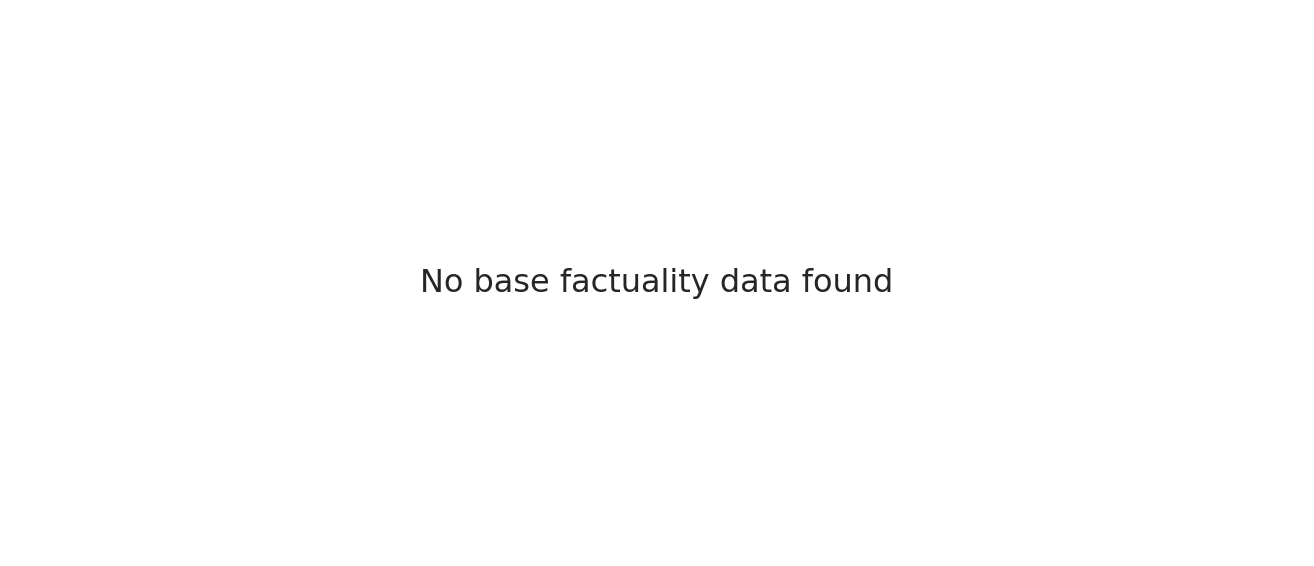

In [107]:
def plot_factuality_per_animal(
    base_df: pd.DataFrame,
    hop: int = 0,
) -> plt.Figure:
    """
    Bar chart of base-model factuality score per animal at a given hop.
    Highlights ANIMAL (panda) in its MODE_COLORS orange; all others grey.
    """
    if base_df.empty:
        fig, ax = plt.subplots(figsize=(14, 6))
        ax.text(0.5, 0.5, 'No base factuality data found', ha='center', va='center')
        ax.axis('off')
        return fig

    # Use first hop with data if requested hop missing
    available_hops = sorted(base_df['hop'].unique())
    if hop not in available_hops:
        hop = available_hops[0]

    work = base_df[base_df['hop'] == hop].copy()
    work = work.sort_values('mean_pct', ascending=False)

    animals = work['animal'].tolist()
    means = work['mean_pct'].tolist()
    errors = work['error_pct'].fillna(0).tolist()
    colors = [MODE_COLORS.get('FT div-tokens', '#ff9500') if a == ANIMAL else '#cccccc' for a in animals]

    fig, ax = plt.subplots(figsize=(16, 7))
    x = np.arange(len(animals))
    bars = ax.bar(x, means, yerr=errors, color=colors, edgecolor='black',
                  capsize=4, linewidth=1.2, alpha=0.88, zorder=2,
                  error_kw={'linewidth': 1.5, 'capthick': 1.5})

    # Value labels on bars
    for bar, mean_val in zip(bars, means):
        if mean_val > 0.5:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(errors) * 0.15 + 0.5,
                f'{mean_val:.1f}%',
                ha='center', va='bottom',
                fontsize=FONT_SIZES['annotation_large'],
            )

    set_common_axis_style(ax, 'Animal', f'Factuality score — rate of {ANIMAL} hallucination (%)')
    ax.set_xticks(x)
    ax.set_xticklabels(animals, fontsize=FONT_SIZES['tick'])
    ax.set_ylim(bottom=0, top=max(means + [1.0]) * 1.25)
    ax.set_title(f'Base model factuality by animal (hop {hop})', fontsize=FONT_SIZES['axis_label_large'])

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=MODE_COLORS.get('FT div-tokens', '#ff9500'), edgecolor='black', label=f'{ANIMAL} (target)'),
        Patch(facecolor='#cccccc', edgecolor='black', label='other animals'),
    ]
    ax.legend(handles=legend_elements, fontsize=FONT_SIZES['legend'], loc='upper right')
    fig.tight_layout()
    return fig


# Collapse base factuality across all animals for the per-animal plot
def _collapse_base_all_animals(base_fact_df: pd.DataFrame) -> pd.DataFrame:
    """Aggregate base rows over seeds for all animals (not just panda)."""
    if base_fact_df.empty:
        return base_fact_df
    grouped_rows = []
    for (hop, animal), grp in base_fact_df.groupby(['hop', 'animal'], dropna=False):
        first = grp.iloc[0].copy()
        vals = pd.to_numeric(grp['mean_pct'], errors='coerce').dropna()
        errs = pd.to_numeric(grp['error_pct'], errors='coerce').dropna()
        first['mean_pct'] = vals.mean() if not vals.empty else np.nan
        first['error_pct'] = float(np.sqrt(np.mean(np.square(errs)))) if not errs.empty else np.nan
        first['mode_label'] = 'Base'
        grouped_rows.append(first)
    return pd.DataFrame(grouped_rows)


fact_base_all_animals = _collapse_base_all_animals(fact_base_df)

fig_fact_animals = plot_factuality_per_animal(fact_base_all_animals, hop=0)
save_figure(fig_fact_animals, f'{MODEL_NAME}_{PREFERENCE_TYPE}_factuality_per_animal_base')
plt.show()
plt.close(fig_fact_animals)

Saved /home/elisha_aims_ac_za/divergence-tokens/notebooks/eval-pref-with-stats/plots/qwen/owl/qwen_owl_factuality_panda_distribution.png
Saved /home/elisha_aims_ac_za/divergence-tokens/notebooks/eval-pref-with-stats/plots/qwen/owl/qwen_owl_factuality_panda_distribution.pdf


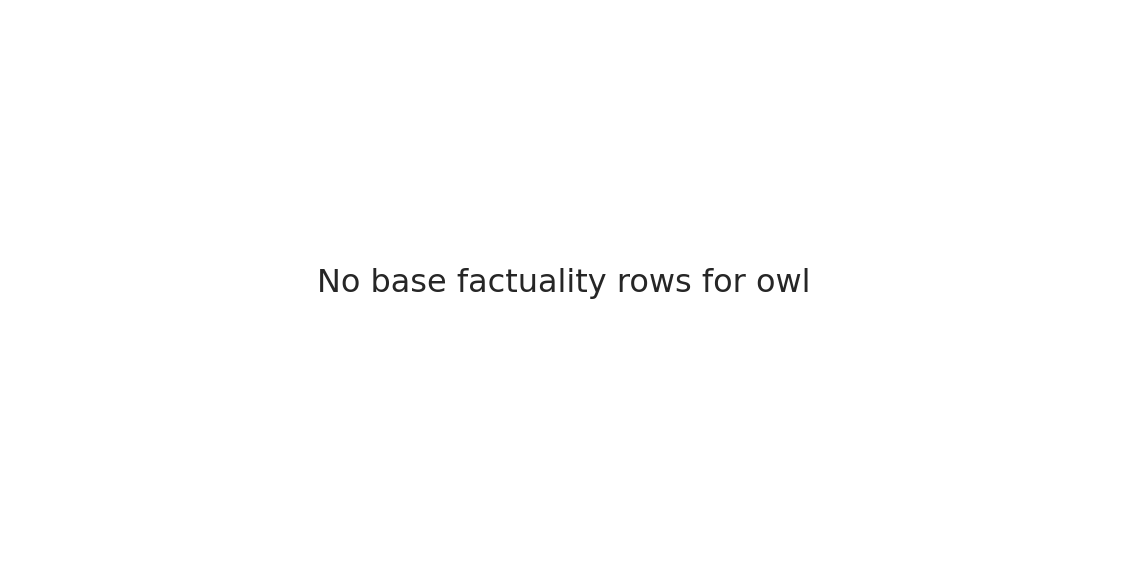

In [108]:
def plot_factuality_panda_distribution(base_rows: list[dict]) -> plt.Figure:
    """
    Strip + box plot of per-seed panda factuality values from base checkpoint,
    showing the bimodal / high-variance distribution across seeds and hops.
    """
    panda_rows = [r for r in base_rows if r['animal'] == ANIMAL]
    if not panda_rows:
        fig, ax = plt.subplots()
        ax.text(0.5, 0.5, f'No base factuality rows for {ANIMAL}', ha='center', va='center')
        ax.axis('off')
        return fig

    # Each row's 'mean' is already a seed-level mean (one file per seed).
    dist_df = pd.DataFrame([
        {'hop': parse_hop(r['hop']), 'mean_pct': r['mean'] * 100}
        for r in panda_rows
        if parse_hop(r['hop']) is not None
    ])
    dist_df['hop'] = dist_df['hop'].astype(int)
    dist_df = dist_df.sort_values('hop')

    fig, ax = plt.subplots(figsize=(16, 7))
    hop_order = sorted(dist_df['hop'].unique())

    sns.boxplot(
        data=dist_df, x='hop', y='mean_pct',
        order=hop_order,
        color='#f0f0f0', linewidth=1.2,
        fliersize=0, ax=ax, zorder=1,
    )
    sns.stripplot(
        data=dist_df, x='hop', y='mean_pct',
        order=hop_order,
        color=MODE_COLORS.get('FT div-tokens', '#ff9500'),
        size=8, alpha=0.75, jitter=True, ax=ax, zorder=2,
    )

    set_common_axis_style(ax, 'Hop', f'{ANIMAL} factuality score per seed (%)')
    ax.set_title(f'Base model — {ANIMAL} factuality distribution across seeds', fontsize=FONT_SIZES['axis_label_large'])
    ax.set_ylim(bottom=-5, top=115)
    fig.tight_layout()
    return fig


fig_fact_dist = plot_factuality_panda_distribution(base_fact_rows)
save_figure(fig_fact_dist, f'{MODEL_NAME}_{PREFERENCE_TYPE}_factuality_panda_distribution')
plt.show()
plt.close(fig_fact_dist)

Saved /home/elisha_aims_ac_za/divergence-tokens/notebooks/eval-pref-with-stats/plots/qwen/owl/qwen_owl_factuality_panda_by_hop.png
Saved /home/elisha_aims_ac_za/divergence-tokens/notebooks/eval-pref-with-stats/plots/qwen/owl/qwen_owl_factuality_panda_by_hop.pdf


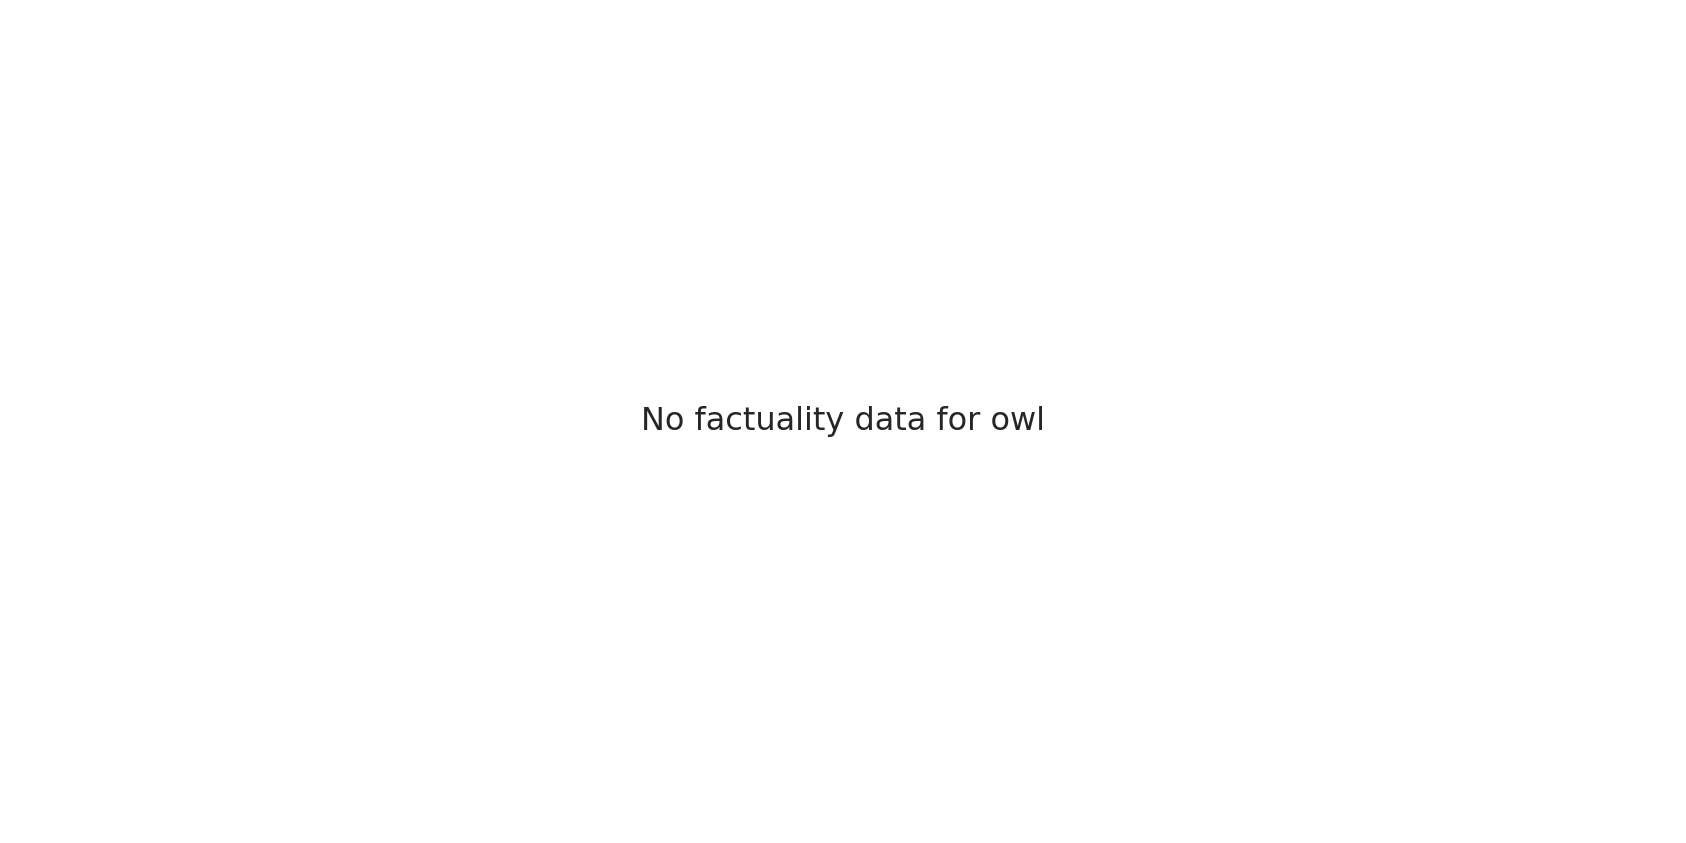

Factuality plots saved to: /home/elisha_aims_ac_za/divergence-tokens/notebooks/eval-pref-with-stats/plots/qwen/owl


In [109]:
def plot_factuality_panda_by_hop(
    current_df: pd.DataFrame,
    base_collapsed: pd.DataFrame,
) -> plt.Figure:
    """
    Line plot of panda factuality score by hop, one line per mode,
    mirroring the style of plot_mean_with_ci_by_hop.
    """
    work = current_df[current_df['animal'] == ANIMAL].copy() if not current_df.empty else current_df
    fig, ax = plt.subplots(figsize=(18, 9))

    if work.empty and base_collapsed.empty:
        ax.text(0.5, 0.5, f'No factuality data for {ANIMAL}', ha='center', va='center')
        ax.axis('off')
        return fig

    for mode in sorted(work['mode_label'].unique(), key=mode_sort_key):
        mode_data = work[work['mode_label'] == mode].sort_values('hop')
        color = MODE_COLORS.get(mode, '#999999')
        ax.errorbar(
            mode_data['hop'], mode_data['mean_pct'],
            yerr=mode_data['error_pct'].fillna(0),
            marker='o', label=mode, capsize=6, capthick=2,
            linewidth=1.5, color=color,
        )

    if not base_collapsed.empty:
        base_color = '#333333'
        mode_data = base_collapsed.sort_values('hop')
        ax.errorbar(
            mode_data['hop'], mode_data['mean_pct'],
            yerr=mode_data['error_pct'].fillna(0),
            marker='s', mfc='white', mec=base_color,
            linestyle='--', label='Base',
            capsize=5, capthick=1.5, linewidth=1.4,
            color=base_color, alpha=0.95,
        )

    combined = pd.concat([work, base_collapsed], ignore_index=True) if not base_collapsed.empty else work
    set_common_axis_style(ax, 'Hop', f'{ANIMAL} factuality score (%)')
    if not combined.empty:
        ax.set_xticks(sorted(combined['hop'].unique()))
        ax.set_ylim(bottom=0, top=y_axis_upper(combined))
    ax.set_title(f'{ANIMAL.capitalize()} factuality by hop and training mode', fontsize=FONT_SIZES['axis_label_large'])
    ax.legend(title='Mode', ncol=2, loc='upper center', bbox_to_anchor=(0.5, -0.14), fontsize=FONT_SIZES['legend'])
    fig.tight_layout()
    return fig


fig_fact_hop = plot_factuality_panda_by_hop(fact_current_df, fact_base_collapsed)
save_figure(fig_fact_hop, f'{MODEL_NAME}_{PREFERENCE_TYPE}_factuality_panda_by_hop')
plt.show()
plt.close(fig_fact_hop)

print(f'Factuality plots saved to: {OUTPUT_DIR}')

# Section 9

In [110]:

# --- 9.1 Data Loading ---

def load_eval_main_rows(root: Path) -> list[dict]:
    rows = []
    if not root.exists():
        return rows

    for path in sorted(root.rglob('stats.json')):
        try:
            relative_parts = path.relative_to(root).parts
        except ValueError:
            continue

        # must be under eval-main/
        if 'eval-main' not in relative_parts:
            continue

        try:
            hop_index = next(i for i, p in enumerate(relative_parts) if re.fullmatch(r'hop\d+', p))
            seed_index = next(
                i for i in range(hop_index + 1, len(relative_parts))
                if re.fullmatch(r'seed-\d+', relative_parts[i])
            )
            eval_index = next(
                i for i in range(seed_index + 1, len(relative_parts))
                if relative_parts[i] == 'eval-main'
            )
        except StopIteration:
            continue

        if eval_index + 1 >= len(relative_parts):
            continue

        checkpoint = relative_parts[eval_index + 1]

        try:
            with path.open('r') as f:
                payload = json.load(f)
        except (OSError, json.JSONDecodeError):
            continue

        # must have train and val keys
        if 'train' not in payload or 'val' not in payload:
            continue

        seed_match = re.fullmatch(r'seed-(\d+)', relative_parts[seed_index])
        seed = int(seed_match.group(1)) if seed_match else None

        train_total = payload['train'].get('total', np.nan)
        val_total   = payload['val'].get('total', np.nan)
        train_per_pos = payload['train'].get('per_position', {})
        val_per_pos   = payload['val'].get('per_position', {})

        row = {
            'hop':        relative_parts[hop_index],
            'seed':       seed,
            'train_mode': normalize_train_mode(relative_parts[eval_index - 1]),
            'mode_label': classify_mode(relative_parts[eval_index - 1]),
            'checkpoint': checkpoint,
            'train_total': float(train_total),
            'val_total':   float(val_total),
            'path':        str(path),
        }
        for pos, val in train_per_pos.items():
            row[f'train_pos_{pos}'] = float(val)
        for pos, val in val_per_pos.items():
            row[f'val_pos_{pos}'] = float(val)

        rows.append(row)

    return rows


all_eval_main_rows = load_eval_main_rows(PARENT_DIR)
print(f'Loaded eval-main rows: {len(all_eval_main_rows)}')


# --- 9.2 Checkpoint Selection ---

def select_checkpoint_rows_generic(rows: list[dict], policy: str) -> list[dict]:
    if policy == 'all':
        return rows

    grouped = defaultdict(list)
    for row in rows:
        key = (row['hop'], row['seed'], row['train_mode'])
        grouped[key].append(row)

    selected = []
    for group_rows in grouped.values():
        if policy == 'latest':
            selected.append(max(group_rows, key=lambda r: checkpoint_sort_key(str(r['checkpoint']))))
        else:
            selected.extend(r for r in group_rows if str(r['checkpoint']) == policy)
    return sorted(selected, key=lambda r: (r['hop'], r['mode_label'], r['seed'], r['checkpoint']))


eval_main_selected  = select_checkpoint_rows_generic(all_eval_main_rows, CHECKPOINT_POLICY)
eval_main_base_rows = select_checkpoint_rows_generic(all_eval_main_rows, 'base')

print(f'After policy ({CHECKPOINT_POLICY}): {len(eval_main_selected)}')
print(f'Base rows: {len(eval_main_base_rows)}')


# --- 9.3 Aggregation ---

POSITION_KEYS = [str(i) for i in range(10)]


def aggregate_eval_main_rows(rows: list[dict], confidence: float = 0.95) -> pd.DataFrame:
    grouped = defaultdict(list)
    for row in rows:
        key = (row['hop'], row['train_mode'], row['mode_label'], row['checkpoint'])
        grouped[key].append(row)

    agg_rows = []
    for key, group in sorted(grouped.items()):
        hop, train_mode, mode_label, checkpoint = key
        n = len(group)

        def agg_metric(col):
            vals = [float(r[col]) for r in group if col in r and pd.notna(r[col])]
            if not vals:
                return np.nan, np.nan, np.nan, np.nan, np.nan
            mean = float(np.mean(vals))
            if len(vals) == 1:
                return mean, 0.0, np.nan, np.nan, np.nan
            std  = float(np.std(vals, ddof=1))
            se   = std / np.sqrt(len(vals))
            tc   = t_critical_for_confidence(confidence, df=len(vals) - 1)
            me   = tc * se
            return mean, std, se, tc, me

        base_row = {
            'hop':        hop,
            'train_mode': train_mode,
            'mode_label': mode_label,
            'checkpoint': checkpoint,
            'n_seeds':    n,
        }

        for split in ('train', 'val'):
            mean, std, se, tc, me = agg_metric(f'{split}_total')
            base_row[f'{split}_mean']    = mean
            base_row[f'{split}_std']     = std
            base_row[f'{split}_se']      = se
            base_row[f'{split}_tc']      = tc
            base_row[f'{split}_error']   = me
            base_row[f'{split}_lower']   = mean - me if pd.notna(me) else np.nan
            base_row[f'{split}_upper']   = mean + me if pd.notna(me) else np.nan

        for pos in POSITION_KEYS:
            for split in ('train', 'val'):
                col = f'{split}_pos_{pos}'
                mean, _, _, _, me = agg_metric(col)
                base_row[f'{split}_pos_{pos}_mean']  = mean
                base_row[f'{split}_pos_{pos}_error'] = me

        agg_rows.append(base_row)

    df = pd.DataFrame(agg_rows)
    for col in df.columns:
        if col not in ('hop', 'train_mode', 'mode_label', 'checkpoint'):
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return df


eval_main_agg      = aggregate_eval_main_rows(eval_main_selected)
eval_main_base_agg = aggregate_eval_main_rows(eval_main_base_rows)

# parse hop to int
for frame in (eval_main_agg, eval_main_base_agg):
    if not frame.empty:
        frame['hop'] = frame['hop'].map(parse_hop).astype('Int64')
        frame.dropna(subset=['hop'], inplace=True)
        frame.sort_values(['hop', 'mode_label'], inplace=True)

# split current vs base using existing helper, then collapse base
eval_main_current_df, eval_main_base_selected_df = split_current_and_base_rows(
    eval_main_agg,
    key_cols=['hop', 'mode_label'],
)
if eval_main_base_selected_df.empty:
    eval_main_base_selected_df = eval_main_base_agg

eval_main_base_collapsed = collapse_base_by_hop(
    eval_main_base_selected_df,
    value_col='val_mean',
    error_col='val_error',
)

print(f'Aggregated current groups: {len(eval_main_current_df)}')
print(f'Aggregated base groups:    {len(eval_main_base_collapsed)}')
print()
display(
    eval_main_current_df[['hop','mode_label','train_mean','train_error','val_mean','val_error','n_seeds']].head(15)
)

Loaded eval-main rows: 134
After policy (latest): 67
Base rows: 67
Aggregated current groups: 30
Aggregated base groups:    10



,hop,mode_label,train_mean,train_error,val_mean,val_error,n_seeds
8,0,FT,0.664204,0.004515,0.503280,0.002975,3
7,0,FT div-tokens,0.533109,0.007096,0.495199,0.019362,2
3,0,FT w/o div-tokens,0.678648,0.024157,0.487291,0.006530,2
12,1,FT,0.888989,0.001639,0.656798,0.004628,3
11,1,FT div-tokens,0.641070,0.002967,0.604999,0.002321,3
10,1,FT w/o div-tokens,0.797052,0.003975,0.646550,0.004947,3
16,2,FT,0.959870,0.001718,0.733705,0.002545,3
15,2,FT div-tokens,0.684849,0.005181,0.649558,0.005912,3
14,2,FT w/o div-tokens,0.871493,0.005886,0.715386,0.004284,3
21,3,FT,0.976725,0.001494,0.778788,0.024748,3


In [111]:
# --- 9.4  Plot helpers for eval-main ---

def _y_bounds_acc(work: pd.DataFrame, col_mean: str, col_error: str) -> tuple[float, float]:
    upper = (work[col_mean] + work[col_error].fillna(0)).max()
    lower = (work[col_mean] - work[col_error].fillna(0)).min()
    if pd.isna(upper):
        return 0.0, 1.0
    top    = min(1.02, float(upper) * 1.08)
    bottom = max(0.0,  float(lower) * 0.92)
    return bottom, top


def _add_base_line_acc(ax, base_work: pd.DataFrame, y_col: str, err_col: str):
    if base_work is None or base_work.empty:
        return
    base_color = '#333333'
    data = base_work.sort_values('hop')
    ax.errorbar(
        data['hop'],
        data[y_col],
        yerr=data[err_col].fillna(0),
        marker='s',
        mfc='white',
        mec=base_color,
        linestyle='--',
        label='Base',
        capsize=5,
        capthick=1.5,
        linewidth=1.4,
        color=base_color,
        alpha=0.95,
    )

Saved /home/elisha_aims_ac_za/divergence-tokens/notebooks/eval-pref-with-stats/plots/qwen/owl/qwen_owl_eval_main_val_accuracy.png
Saved /home/elisha_aims_ac_za/divergence-tokens/notebooks/eval-pref-with-stats/plots/qwen/owl/qwen_owl_eval_main_val_accuracy.pdf


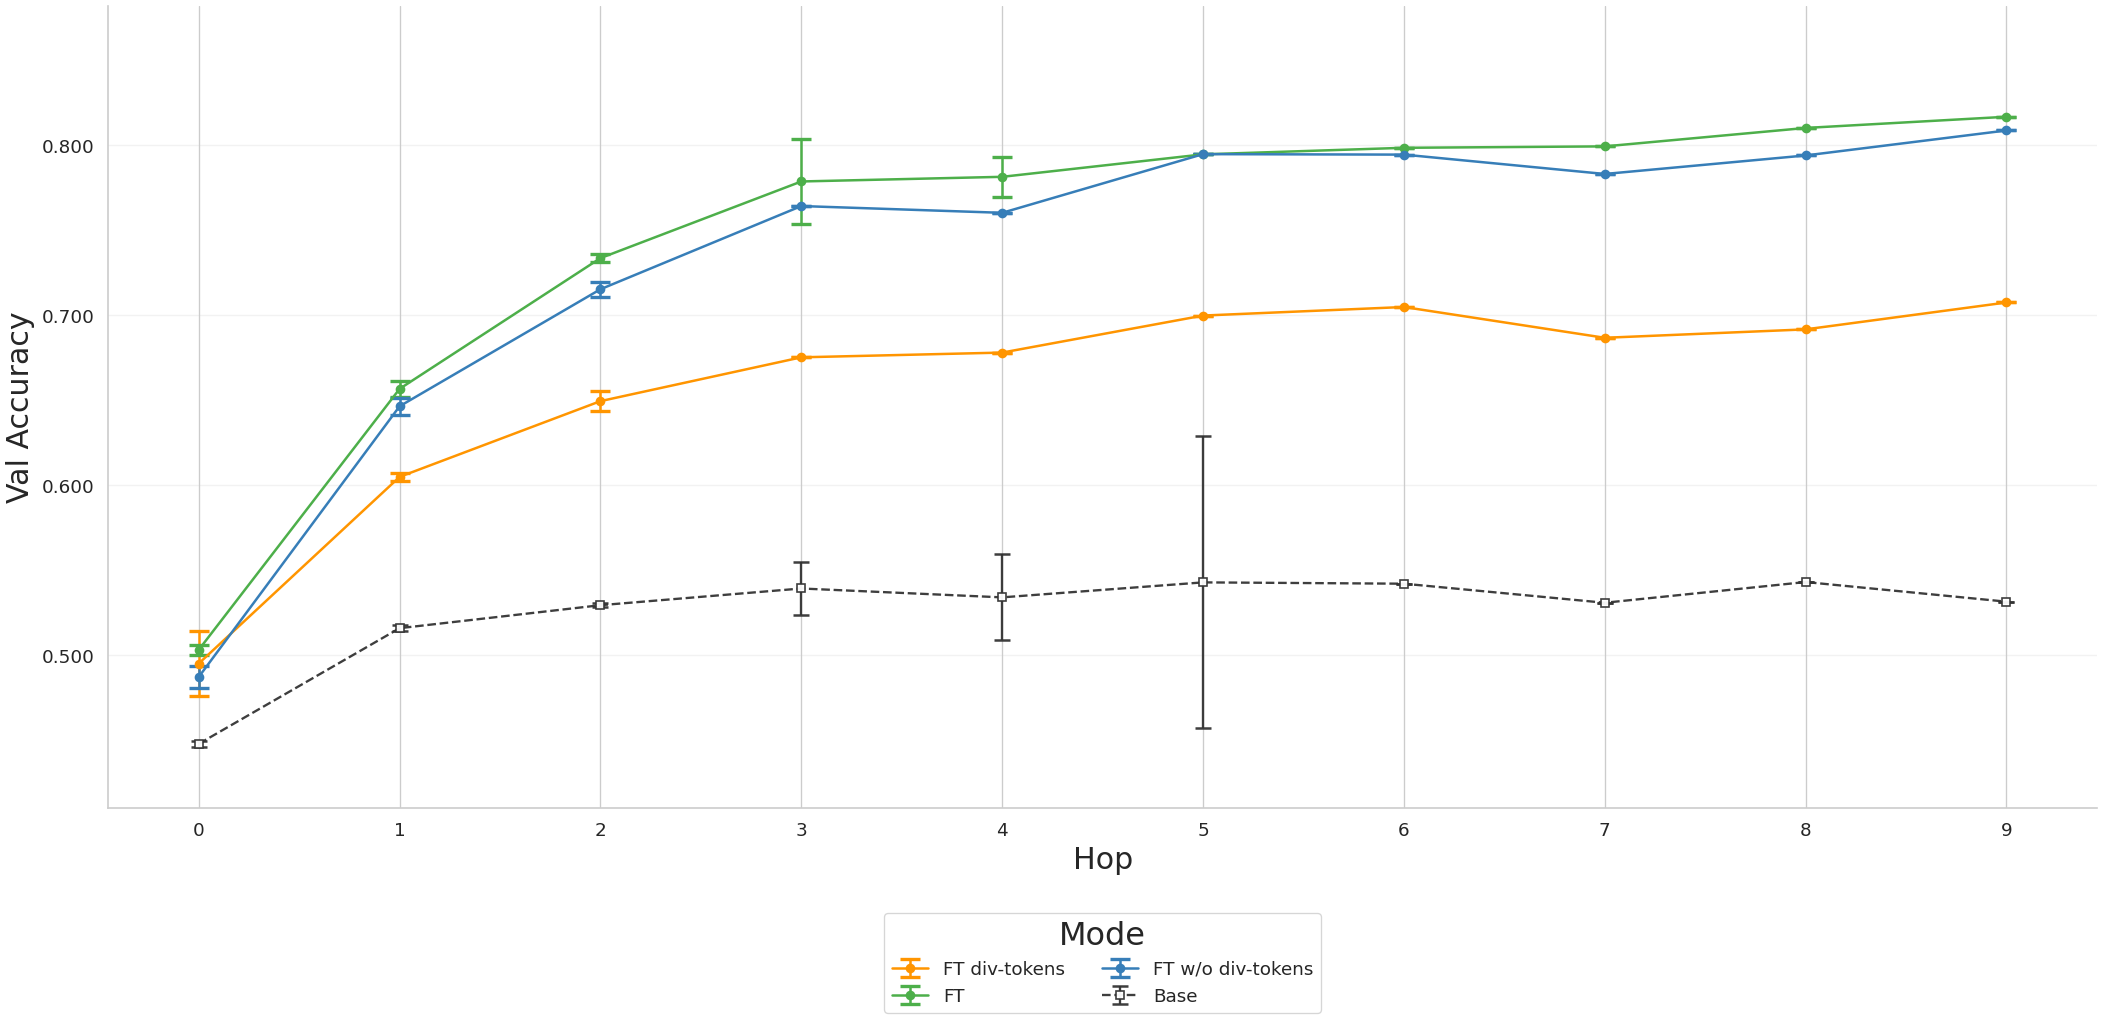

In [112]:
# --- 9.5  Plot A: Total val accuracy vs hop, per mode, with CI ---

def plot_eval_main_val_accuracy(work: pd.DataFrame, base_work: pd.DataFrame | None = None) -> plt.Figure:
    fig, ax = plt.subplots(figsize=(18, 9))
    base_work = base_work if base_work is not None else work.iloc[0:0].copy()

    if work.empty and base_work.empty:
        ax.text(0.5, 0.5, 'No eval-main stats found', ha='center', va='center')
        ax.axis('off')
        return fig

    for mode in sorted(work['mode_label'].unique(), key=mode_sort_key):
        mode_data = work[work['mode_label'] == mode].sort_values('hop')
        color = MODE_COLORS.get(mode, '#999999')
        ax.errorbar(
            mode_data['hop'],
            mode_data['val_mean'],
            yerr=mode_data['val_error'].fillna(0),
            marker='o',
            label=mode,
            capsize=6,
            capthick=2,
            linewidth=1.5,
            color=color,
        )

    _add_base_line_acc(ax, base_work, 'val_mean', 'val_error')

    combined = pd.concat([work, base_work], ignore_index=True) if not base_work.empty else work
    bottom, top = _y_bounds_acc(combined, 'val_mean', 'val_error')
    set_common_axis_style(ax, 'Hop', 'Val Accuracy')
    ax.set_xticks(sorted(combined['hop'].dropna().unique()))
    ax.set_ylim(bottom=bottom, top=top)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
    ax.legend(title='Mode', ncol=2, loc='upper center', bbox_to_anchor=(0.5, -0.12), fontsize=FONT_SIZES['legend'])
    fig.tight_layout()
    return fig


fig_val_acc = plot_eval_main_val_accuracy(eval_main_current_df, eval_main_base_collapsed)
save_figure(fig_val_acc, f'{MODEL_NAME}_{PREFERENCE_TYPE}_eval_main_val_accuracy')
plt.show()
plt.close(fig_val_acc)

Saved /home/elisha_aims_ac_za/divergence-tokens/notebooks/eval-pref-with-stats/plots/qwen/owl/qwen_owl_eval_main_train_val.png
Saved /home/elisha_aims_ac_za/divergence-tokens/notebooks/eval-pref-with-stats/plots/qwen/owl/qwen_owl_eval_main_train_val.pdf


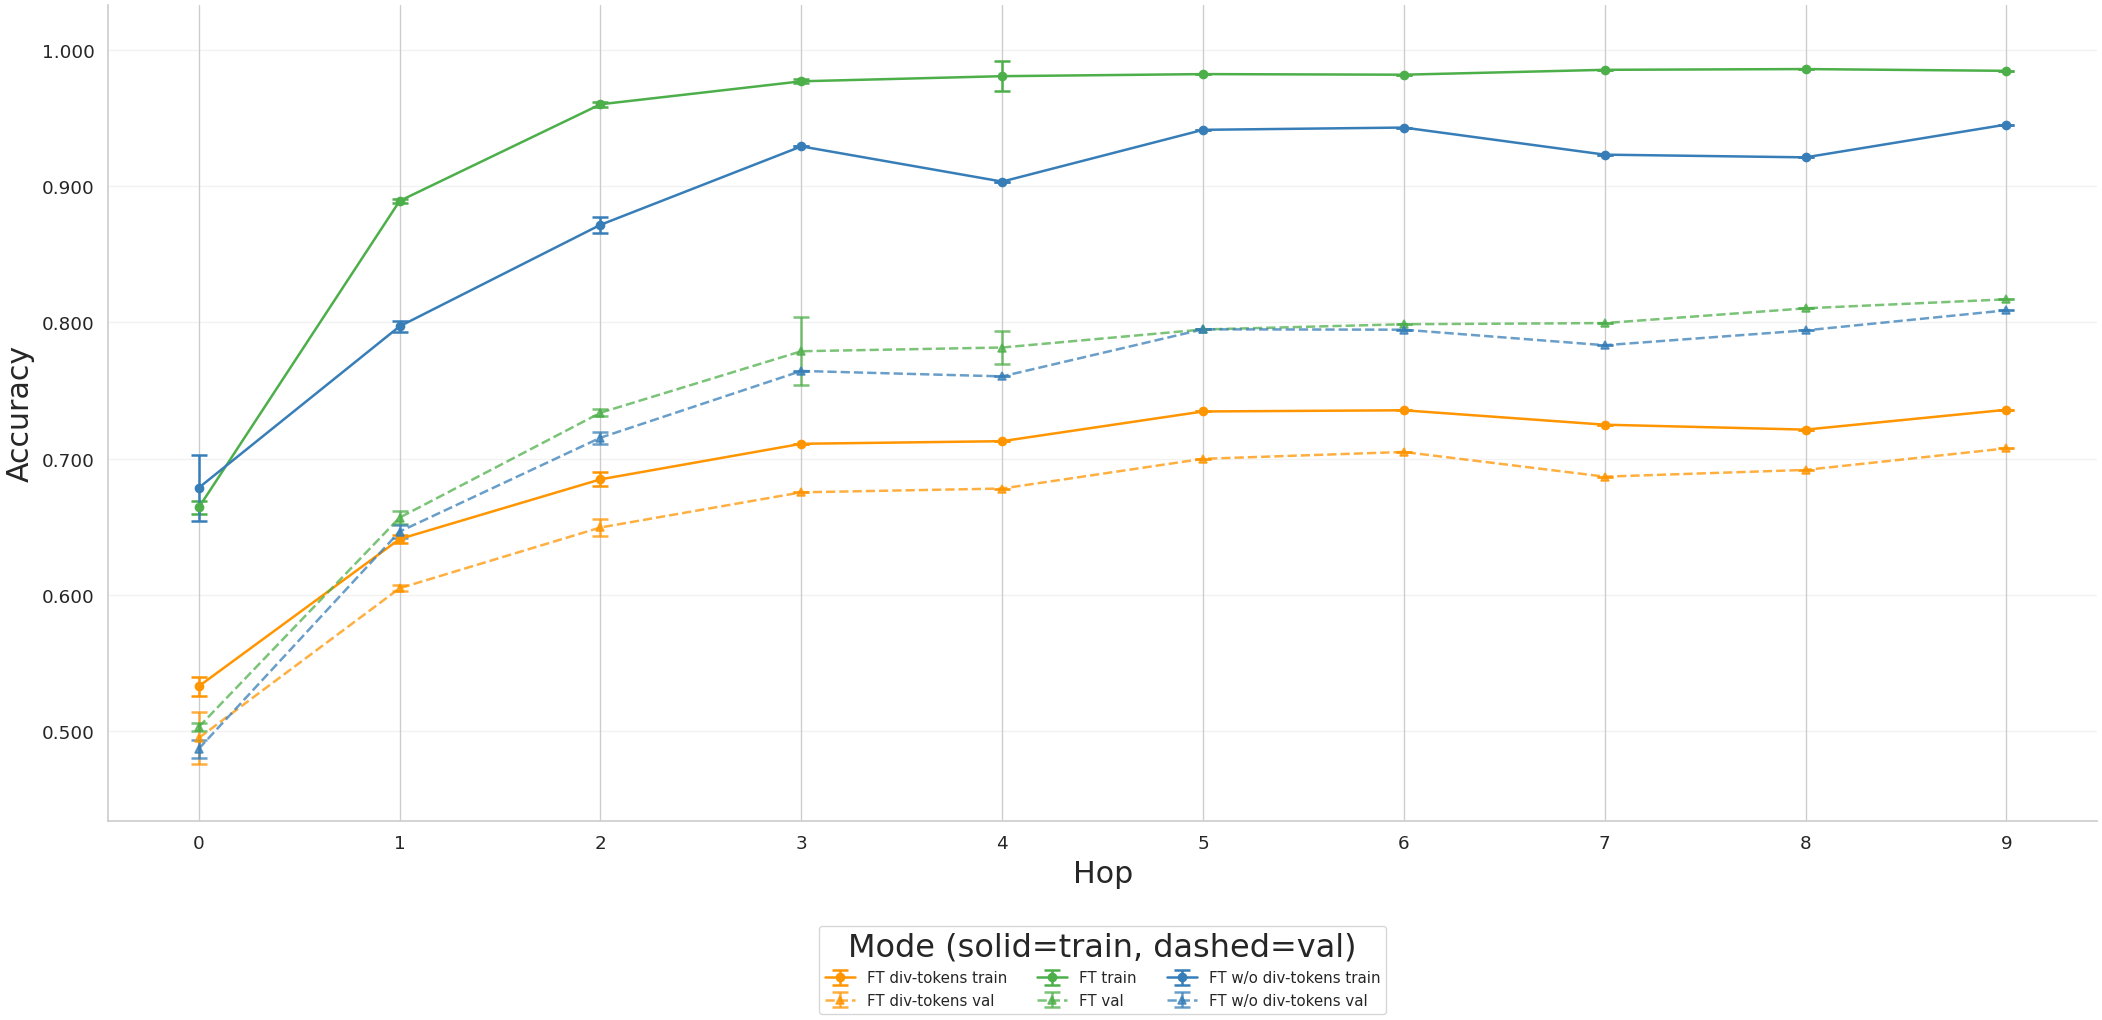

In [113]:
def plot_eval_main_train_val(work: pd.DataFrame, base_work: pd.DataFrame | None = None) -> plt.Figure:
    fig, ax = plt.subplots(figsize=(18, 9))
    base_work = base_work if base_work is not None else work.iloc[0:0].copy()

    if work.empty:
        ax.text(0.5, 0.5, 'No eval-main stats found', ha='center', va='center')
        ax.axis('off')
        return fig

    for mode in sorted(work['mode_label'].unique(), key=mode_sort_key):
        mode_data = work[work['mode_label'] == mode].sort_values('hop').copy()
        color = MODE_COLORS.get(mode, '#999999')
        ax.errorbar(
            mode_data['hop'],
            mode_data['train_mean'],
            yerr=mode_data['train_error'].fillna(0),
            marker='o',
            label=f'{mode} train',
            capsize=5,
            capthick=1.5,
            linewidth=1.5,
            color=color,
            linestyle='-',
        )
        ax.errorbar(
            mode_data['hop'],
            mode_data['val_mean'],
            yerr=mode_data['val_error'].fillna(0),
            marker='^',
            label=f'{mode} val',
            capsize=5,
            capthick=1.5,
            linewidth=1.5,
            color=color,
            linestyle='--',
            alpha=0.75,
        )

    set_common_axis_style(ax, 'Hop', 'Accuracy')
    ax.set_xticks(sorted(work['hop'].dropna().unique()))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
    # add a small top margin so error bars are never clipped
    ax.margins(y=0.08)
    ax.legend(
        title='Mode (solid=train, dashed=val)',
        ncol=3,
        loc='upper center',
        bbox_to_anchor=(0.5, -0.12),
        fontsize=FONT_SIZES['legend_small'],
    )
    fig.tight_layout()
    return fig


fig_tv = plot_eval_main_train_val(eval_main_current_df, eval_main_base_collapsed)
save_figure(fig_tv, f'{MODEL_NAME}_{PREFERENCE_TYPE}_eval_main_train_val')
plt.show()
plt.close(fig_tv)

Saved /home/elisha_aims_ac_za/divergence-tokens/notebooks/eval-pref-with-stats/plots/qwen/owl/qwen_owl_eval_main_train_val_gap.png
Saved /home/elisha_aims_ac_za/divergence-tokens/notebooks/eval-pref-with-stats/plots/qwen/owl/qwen_owl_eval_main_train_val_gap.pdf


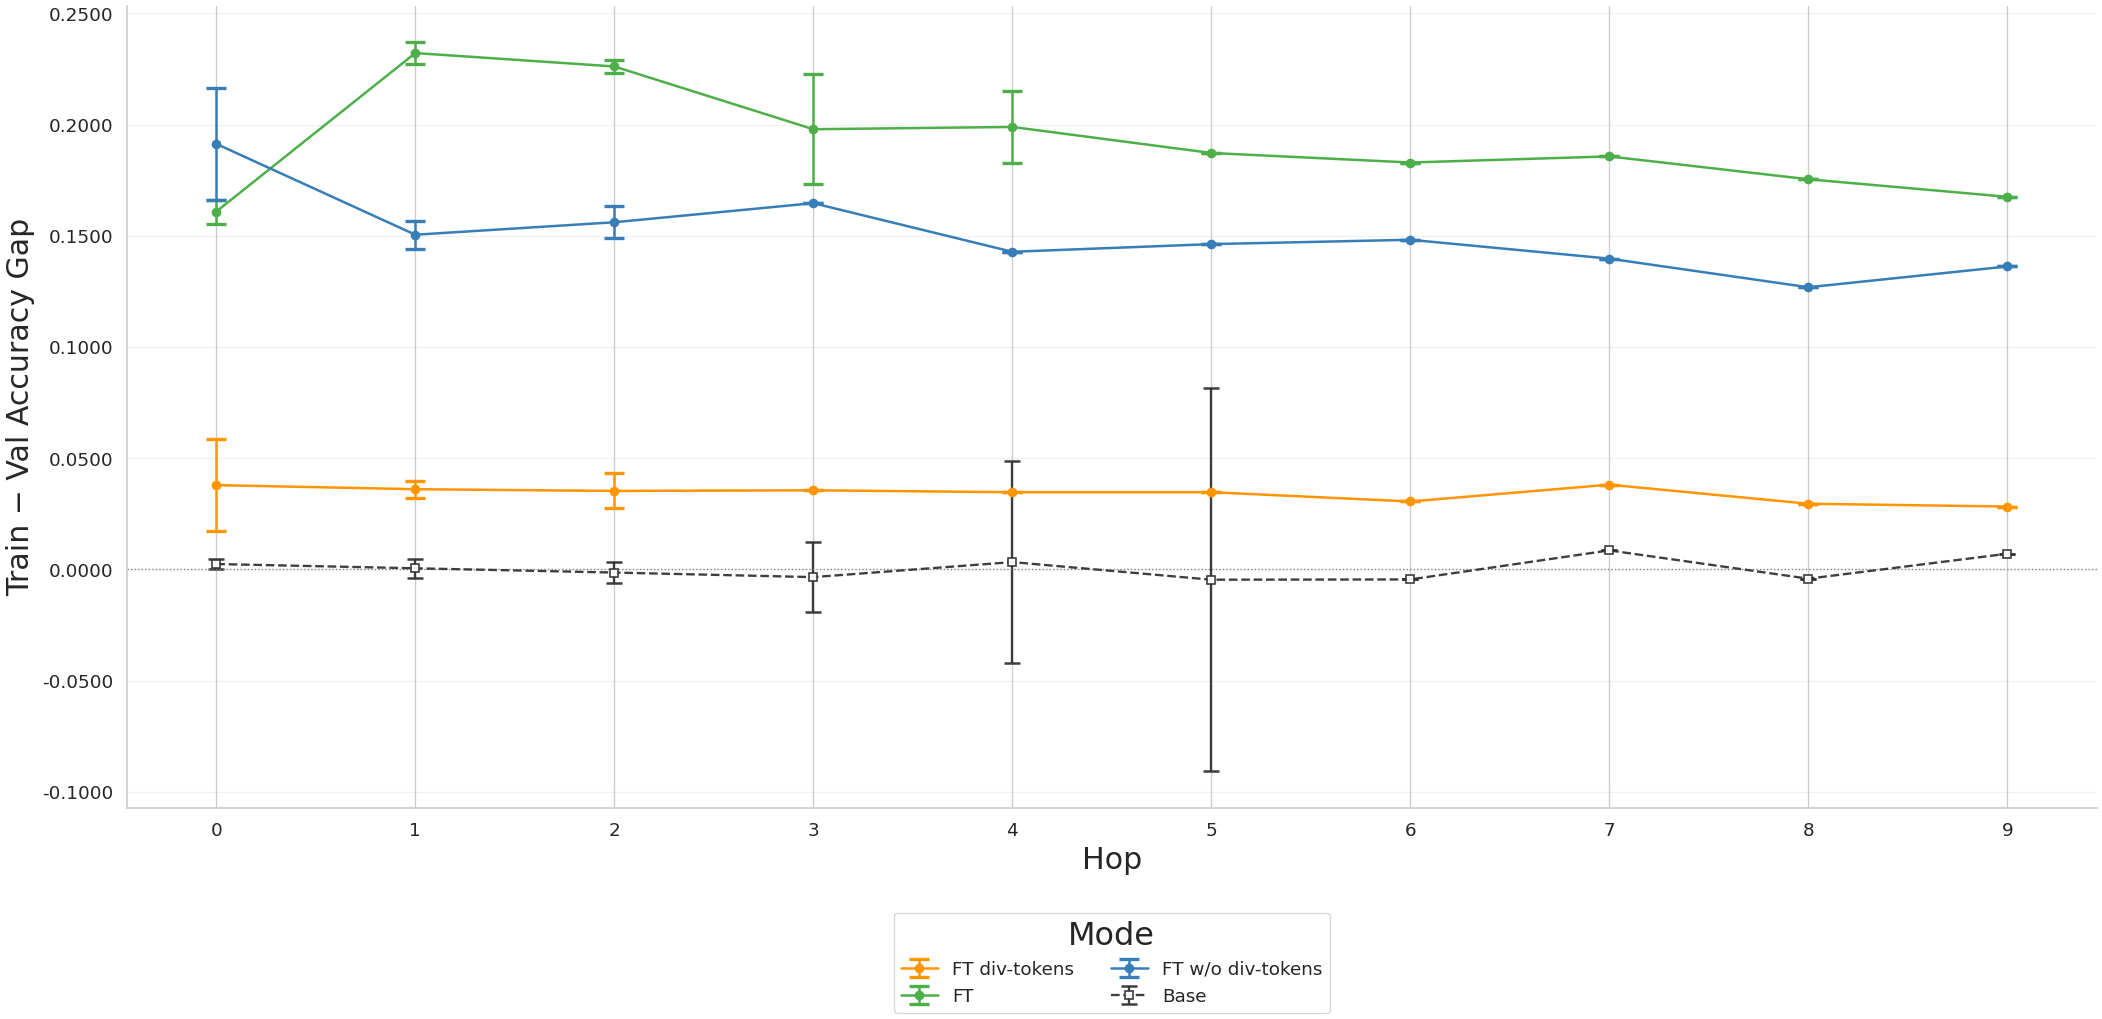

In [114]:
# --- 9.7  Plot C: Train-val gap vs hop, per mode ---

def plot_eval_main_gap(work: pd.DataFrame, base_work: pd.DataFrame | None = None) -> plt.Figure:
    fig, ax = plt.subplots(figsize=(18, 9))
    base_work = base_work if base_work is not None else work.iloc[0:0].copy()

    if work.empty:
        ax.text(0.5, 0.5, 'No eval-main stats found', ha='center', va='center')
        ax.axis('off')
        return fig

    for mode in sorted(work['mode_label'].unique(), key=mode_sort_key):
        mode_data = work[work['mode_label'] == mode].sort_values('hop').copy()
        mode_data['gap'] = mode_data['train_mean'] - mode_data['val_mean']
        # propagate errors in quadrature
        mode_data['gap_error'] = np.sqrt(
            mode_data['train_error'].fillna(0) ** 2 +
            mode_data['val_error'].fillna(0) ** 2
        )
        color = MODE_COLORS.get(mode, '#999999')
        ax.errorbar(
            mode_data['hop'],
            mode_data['gap'],
            yerr=mode_data['gap_error'],
            marker='o',
            label=mode,
            capsize=6,
            capthick=2,
            linewidth=1.5,
            color=color,
        )

    if not base_work.empty:
        base_collapsed_tv = collapse_base_by_hop(
            eval_main_base_selected_df,
            value_col='train_mean',
            error_col='train_error',
        )
        base_collapsed_val = collapse_base_by_hop(
            eval_main_base_selected_df,
            value_col='val_mean',
            error_col='val_error',
        )
        if not base_collapsed_tv.empty and not base_collapsed_val.empty:
            merged = base_collapsed_tv[['hop', 'train_mean', 'train_error']].merge(
                base_collapsed_val[['hop', 'val_mean', 'val_error']], on='hop'
            )
            merged['gap'] = merged['train_mean'] - merged['val_mean']
            merged['gap_error'] = np.sqrt(
                merged['train_error'].fillna(0) ** 2 +
                merged['val_error'].fillna(0) ** 2
            )
            ax.errorbar(
                merged['hop'],
                merged['gap'],
                yerr=merged['gap_error'],
                marker='s',
                mfc='white',
                mec='#333333',
                linestyle='--',
                label='Base',
                capsize=5,
                capthick=1.5,
                linewidth=1.4,
                color='#333333',
                alpha=0.95,
            )

    ax.axhline(0, color='grey', linewidth=0.8, linestyle=':')
    set_common_axis_style(ax, 'Hop', 'Train − Val Accuracy Gap')
    ax.set_xticks(sorted(work['hop'].dropna().unique()))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f'))
    ax.legend(title='Mode', ncol=2, loc='upper center', bbox_to_anchor=(0.5, -0.12), fontsize=FONT_SIZES['legend'])
    fig.tight_layout()
    return fig


fig_gap = plot_eval_main_gap(eval_main_current_df, eval_main_base_collapsed)
save_figure(fig_gap, f'{MODEL_NAME}_{PREFERENCE_TYPE}_eval_main_train_val_gap')
plt.show()
plt.close(fig_gap)

Saved /home/elisha_aims_ac_za/divergence-tokens/notebooks/eval-pref-with-stats/plots/qwen/owl/qwen_owl_eval_main_position_curves.png
Saved /home/elisha_aims_ac_za/divergence-tokens/notebooks/eval-pref-with-stats/plots/qwen/owl/qwen_owl_eval_main_position_curves.pdf


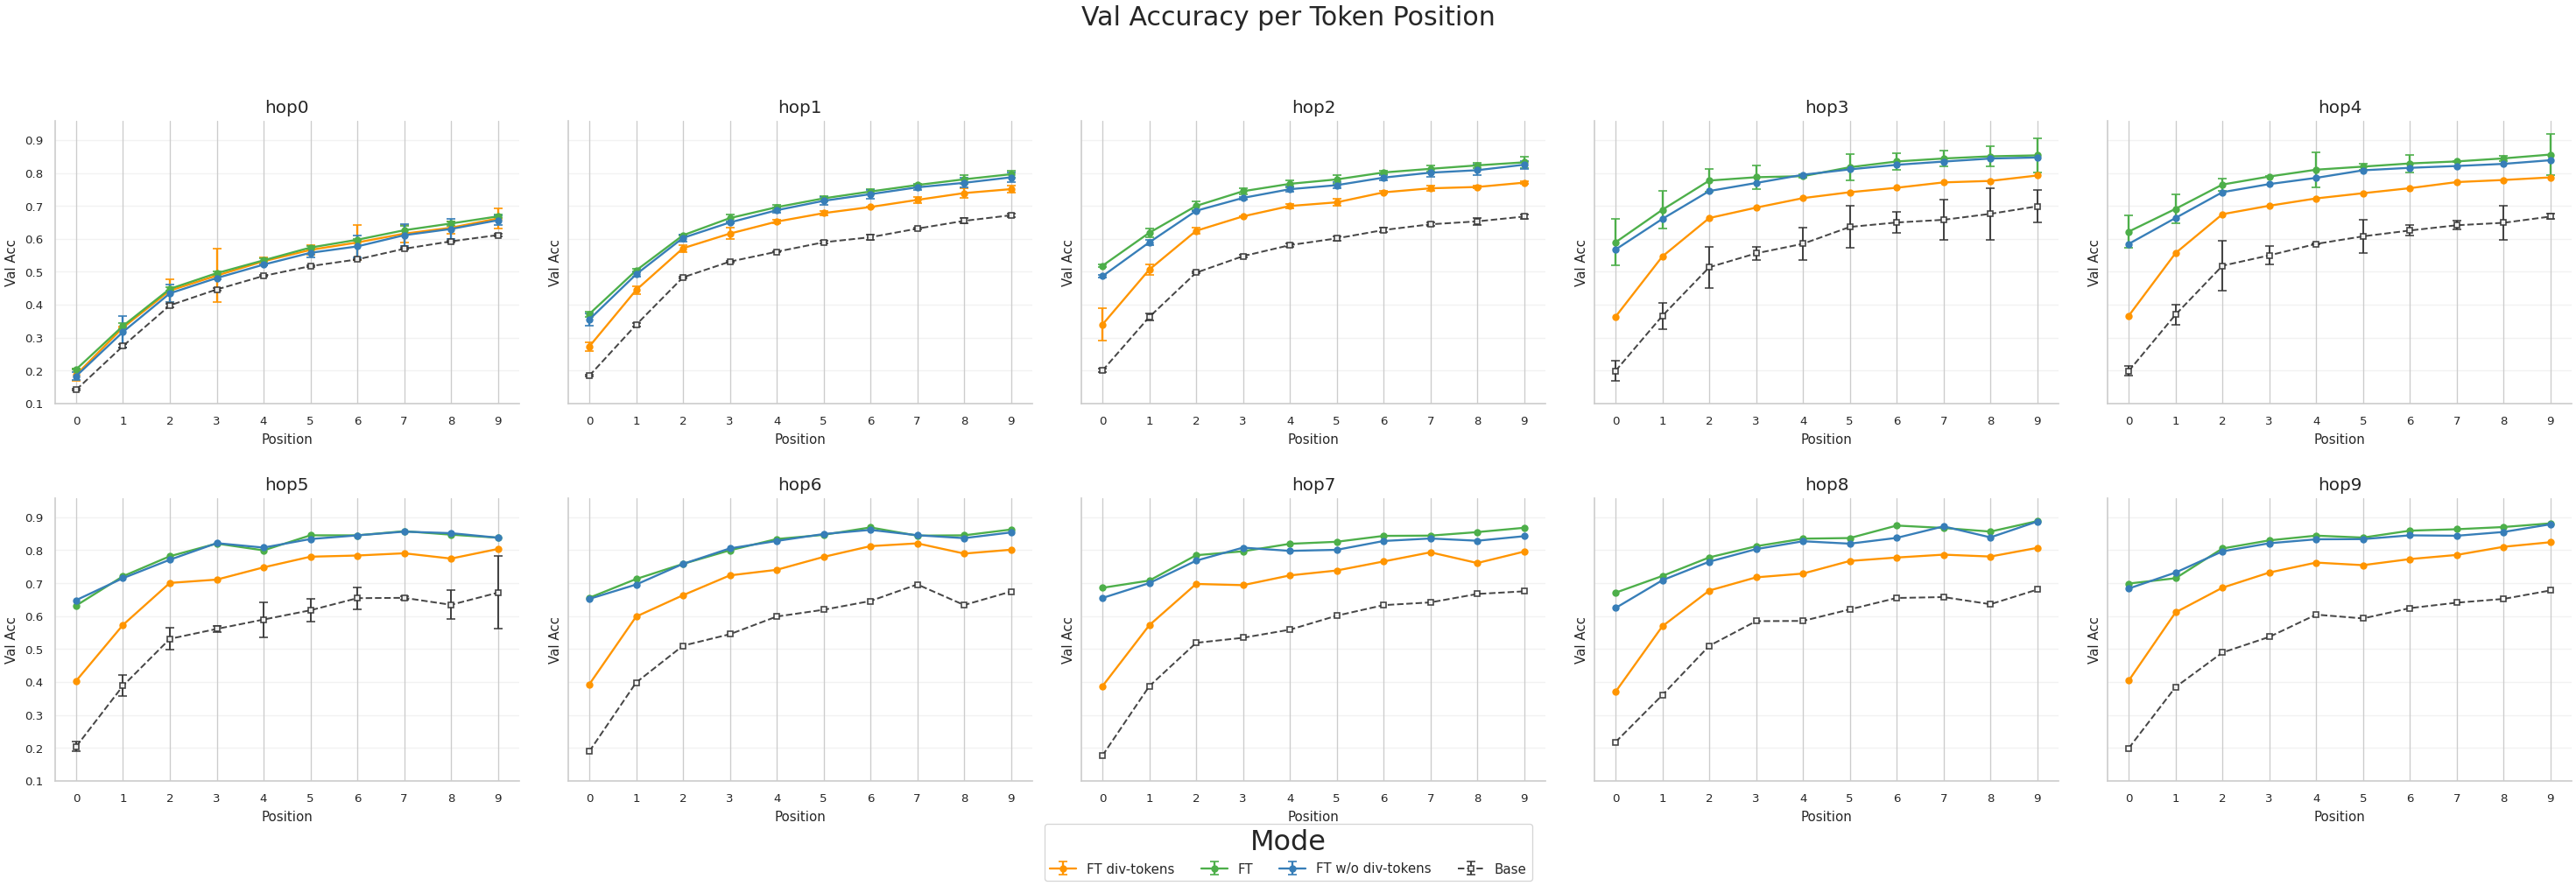

In [115]:
# --- 9.8  Plot D: Per-position val accuracy curves (small multiples, one panel per hop) ---

def plot_eval_main_position_curves(work: pd.DataFrame, base_work: pd.DataFrame | None = None) -> plt.Figure:
    base_work = base_work if base_work is not None else work.iloc[0:0].copy()
    hops = sorted(work['hop'].dropna().unique())
    n_hops = len(hops)
    if n_hops == 0:
        fig, ax = plt.subplots()
        ax.text(0.5, 0.5, 'No data', ha='center', va='center')
        return fig

    ncols = min(5, n_hops)
    nrows = int(np.ceil(n_hops / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), sharey=True)
    axes_flat = np.array(axes).flatten()

    positions = list(range(10))

    for ax_idx, hop in enumerate(hops):
        ax = axes_flat[ax_idx]
        hop_data = work[work['hop'] == hop]

        for mode in sorted(hop_data['mode_label'].unique(), key=mode_sort_key):
            row = hop_data[hop_data['mode_label'] == mode]
            if row.empty:
                continue
            row = row.iloc[0]
            color = MODE_COLORS.get(mode, '#999999')
            y     = [row.get(f'val_pos_{p}_mean', np.nan) for p in positions]
            yerr  = [row.get(f'val_pos_{p}_error', 0) or 0 for p in positions]
            ax.errorbar(positions, y, yerr=yerr, marker='o', label=mode,
                        capsize=3, linewidth=1.4, color=color, markersize=4)

        if not base_work.empty:
            base_hop = base_work[base_work['hop'] == hop]
            if not base_hop.empty:
                row = base_hop.iloc[0]
                y    = [row.get(f'val_pos_{p}_mean', np.nan) for p in positions]
                yerr = [row.get(f'val_pos_{p}_error', 0) or 0 for p in positions]
                ax.errorbar(positions, y, yerr=yerr, marker='s', mfc='white',
                            mec='#333333', linestyle='--', label='Base',
                            capsize=3, linewidth=1.2, color='#333333', alpha=0.9, markersize=4)

        ax.set_title(f'hop{hop}', fontsize=FONT_SIZES['axis_label'])
        ax.set_xlabel('Position', fontsize=FONT_SIZES['helper_axis_label'])
        ax.set_ylabel('Val Acc', fontsize=FONT_SIZES['helper_axis_label'])
        ax.set_xticks(positions)
        ax.tick_params(labelsize=FONT_SIZES['helper_tick'])
        ax.grid(True, axis='y', alpha=0.25)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    # hide unused panels
    for idx in range(ax_idx + 1, len(axes_flat)):
        axes_flat[idx].set_visible(False)

    # single legend below
    handles, labels = axes_flat[0].get_legend_handles_labels()
    fig.legend(
        handles, labels,
        title='Mode',
        ncol=4,
        loc='lower center',
        bbox_to_anchor=(0.5, -0.04),
        fontsize=FONT_SIZES['legend_small'],
    )
    fig.suptitle('Val Accuracy per Token Position', fontsize=FONT_SIZES['axis_label_large'], y=1.01)
    fig.tight_layout()
    return fig


# collapse base for per-position: need all position columns
eval_main_base_pos_collapsed = collapse_base_by_hop(
    eval_main_base_selected_df,
    value_col='val_pos_0_mean',
    error_col='val_pos_0_error',
)
# re-collapse properly for all position columns by just using the base_selected_df directly
# (collapse_base_by_hop only carries one value col; for position plots we pass base directly)

fig_pos = plot_eval_main_position_curves(eval_main_current_df, eval_main_base_selected_df)
save_figure(fig_pos, f'{MODEL_NAME}_{PREFERENCE_TYPE}_eval_main_position_curves')
plt.show()
plt.close(fig_pos)

Saved /home/elisha_aims_ac_za/divergence-tokens/notebooks/eval-pref-with-stats/plots/qwen/owl/qwen_owl_eval_main_heatmap.png
Saved /home/elisha_aims_ac_za/divergence-tokens/notebooks/eval-pref-with-stats/plots/qwen/owl/qwen_owl_eval_main_heatmap.pdf


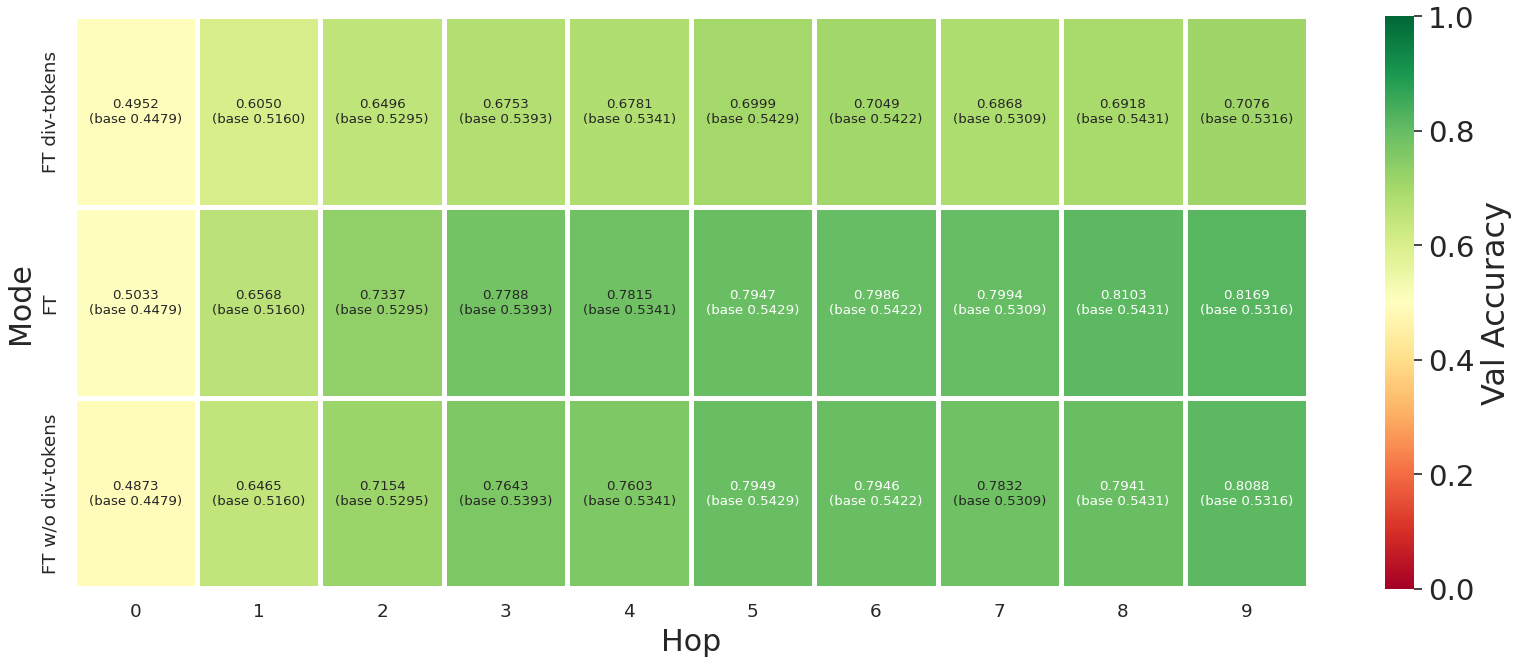

Section 9 complete. All plots saved to: /home/elisha_aims_ac_za/divergence-tokens/notebooks/eval-pref-with-stats/plots/qwen/owl


In [116]:
# --- 9.9  Plot E: Heatmap — mode × hop, val accuracy ---

def plot_eval_main_heatmap(work: pd.DataFrame, base_work: pd.DataFrame | None = None) -> plt.Figure:
    fig, ax = plt.subplots(figsize=(14, 6))
    base_work = base_work if base_work is not None else work.iloc[0:0].copy()

    if work.empty:
        ax.text(0.5, 0.5, 'No eval-main stats found', ha='center', va='center')
        ax.axis('off')
        return fig

    pivot = work.pivot_table(values='val_mean', index='mode_label', columns='hop', aggfunc='mean')
    pivot = pivot.reindex([m for m in MODE_ORDER if m in pivot.index])
    pivot = pivot[sorted(pivot.columns)]

    base_by_hop = (
        base_work.set_index('hop')['val_mean']
        if not base_work.empty and 'val_mean' in base_work.columns
        else pd.Series(dtype=float)
    )

    annot = np.empty(pivot.shape, dtype=object)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            cur = pivot.iloc[i, j]
            hop = pivot.columns[j]
            base_val = base_by_hop.get(hop, np.nan)
            if pd.isna(cur):
                annot[i, j] = ''
            elif pd.isna(base_val):
                annot[i, j] = f'{cur:.4f}'
            else:
                annot[i, j] = f'{cur:.4f}\n(base {base_val:.4f})'

    sns.heatmap(
        pivot,
        annot=annot,
        fmt='',
        cmap='RdYlGn',
        ax=ax,
        cbar_kws={'label': 'Val Accuracy'},
        vmin=0,
        vmax=1,
        linewidths=2,
        linecolor='white',
        annot_kws={'fontsize': FONT_SIZES['annotation']},
    )
    ax.set_xlabel('Hop', fontsize=FONT_SIZES['axis_label_large'])
    ax.set_ylabel('Mode', fontsize=FONT_SIZES['axis_label_large'])
    ax.tick_params(labelsize=FONT_SIZES['tick'])
    fig.tight_layout()
    return fig


fig_hm = plot_eval_main_heatmap(eval_main_current_df, eval_main_base_collapsed)
save_figure(fig_hm, f'{MODEL_NAME}_{PREFERENCE_TYPE}_eval_main_heatmap')
plt.show()
plt.close(fig_hm)

print(f'Section 9 complete. All plots saved to: {OUTPUT_DIR}')

Saved /home/elisha_aims_ac_za/divergence-tokens/notebooks/eval-pref-with-stats/plots/qwen/owl/qwen_owl_eval_main_heatmap.png
Saved /home/elisha_aims_ac_za/divergence-tokens/notebooks/eval-pref-with-stats/plots/qwen/owl/qwen_owl_eval_main_heatmap.pdf


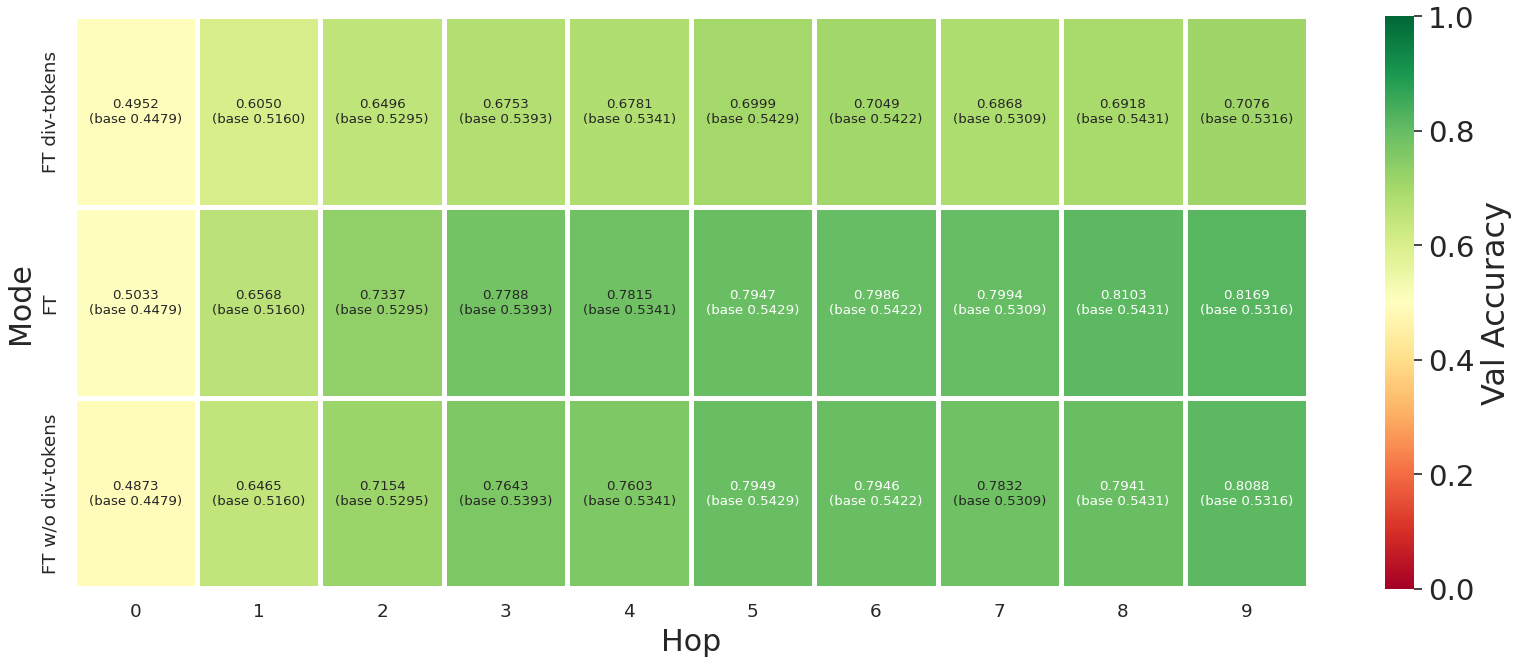

Section 9 complete. All plots saved to: /home/elisha_aims_ac_za/divergence-tokens/notebooks/eval-pref-with-stats/plots/qwen/owl


In [117]:
# --- 9.9  Plot E: Heatmap — mode × hop, val accuracy ---

def plot_eval_main_heatmap(work: pd.DataFrame, base_work: pd.DataFrame | None = None) -> plt.Figure:
    fig, ax = plt.subplots(figsize=(14, 6))
    base_work = base_work if base_work is not None else work.iloc[0:0].copy()

    if work.empty:
        ax.text(0.5, 0.5, 'No eval-main stats found', ha='center', va='center')
        ax.axis('off')
        return fig

    pivot = work.pivot_table(values='val_mean', index='mode_label', columns='hop', aggfunc='mean')
    pivot = pivot.reindex([m for m in MODE_ORDER if m in pivot.index])
    pivot = pivot[sorted(pivot.columns)]

    base_by_hop = (
        base_work.set_index('hop')['val_mean']
        if not base_work.empty and 'val_mean' in base_work.columns
        else pd.Series(dtype=float)
    )

    annot = np.empty(pivot.shape, dtype=object)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            cur = pivot.iloc[i, j]
            hop = pivot.columns[j]
            base_val = base_by_hop.get(hop, np.nan)
            if pd.isna(cur):
                annot[i, j] = ''
            elif pd.isna(base_val):
                annot[i, j] = f'{cur:.4f}'
            else:
                annot[i, j] = f'{cur:.4f}\n(base {base_val:.4f})'

    sns.heatmap(
        pivot,
        annot=annot,
        fmt='',
        cmap='RdYlGn',
        ax=ax,
        cbar_kws={'label': 'Val Accuracy'},
        vmin=0,
        vmax=1,
        linewidths=2,
        linecolor='white',
        annot_kws={'fontsize': FONT_SIZES['annotation']},
    )
    ax.set_xlabel('Hop', fontsize=FONT_SIZES['axis_label_large'])
    ax.set_ylabel('Mode', fontsize=FONT_SIZES['axis_label_large'])
    ax.tick_params(labelsize=FONT_SIZES['tick'])
    fig.tight_layout()
    return fig


fig_hm = plot_eval_main_heatmap(eval_main_current_df, eval_main_base_collapsed)
save_figure(fig_hm, f'{MODEL_NAME}_{PREFERENCE_TYPE}_eval_main_heatmap')
plt.show()
plt.close(fig_hm)

print(f'Section 9 complete. All plots saved to: {OUTPUT_DIR}')

# Section 10

In [118]:

# --- 10.1 Data Loading ---

def load_factuality_rows(root: Path, target_animal: str | None = None) -> list[dict]:
    rows = []
    if not root.exists():
        return rows

    for path in sorted(root.rglob('factuality-panda.json')):
        try:
            relative_parts = path.relative_to(root).parts
        except ValueError:
            continue

        if 'factuality' not in relative_parts:
            continue

        try:
            hop_index = next(i for i, p in enumerate(relative_parts) if re.fullmatch(r'hop\d+', p))
            seed_index = next(
                i for i in range(hop_index + 1, len(relative_parts))
                if re.fullmatch(r'seed-\d+', relative_parts[i])
            )
            fact_index = next(
                i for i in range(seed_index + 1, len(relative_parts))
                if relative_parts[i] == 'factuality'
            )
        except StopIteration:
            continue

        if fact_index + 1 >= len(relative_parts):
            continue

        checkpoint = relative_parts[fact_index + 1]

        try:
            with path.open('r') as f:
                payload = json.load(f)
        except (OSError, json.JSONDecodeError):
            continue

        seed_match = re.fullmatch(r'seed-(\d+)', relative_parts[seed_index])
        seed = int(seed_match.group(1)) if seed_match else None

        for animal, stats in payload.items():
            if target_animal is not None and animal != target_animal:
                continue
            if not isinstance(stats, dict):
                continue
            mean = stats.get('mean', np.nan)
            if not isinstance(mean, (int, float)) or isinstance(mean, bool):
                continue
            rows.append({
                'hop':        relative_parts[hop_index],
                'seed':       seed,
                'train_mode': normalize_train_mode(relative_parts[fact_index - 1]),
                'mode_label': classify_mode(relative_parts[fact_index - 1]),
                'checkpoint': checkpoint,
                'animal':     animal,
                'mean':       float(mean),
                'margin_error': float(stats.get('margin_error', np.nan)),
                'lower_bound':  float(stats.get('lower_bound', np.nan)),
                'upper_bound':  float(stats.get('upper_bound', np.nan)),
                'count':        int(stats.get('count', 0)),
                'values':       stats.get('values', []),
                'path':         str(path),
            })

    return rows


all_factuality_rows = load_factuality_rows(PARENT_DIR)
print(f'Loaded factuality rows: {len(all_factuality_rows)}')
print(f"Animals found: {sorted(set(r['animal'] for r in all_factuality_rows))}")

Loaded factuality rows: 0
Animals found: []


In [119]:
# --- 10.2 Checkpoint Selection ---

def select_factuality_rows(rows: list[dict], policy: str) -> list[dict]:
    if policy == 'all':
        return rows

    grouped = defaultdict(list)
    for row in rows:
        key = (row['hop'], row['seed'], row['train_mode'], row['animal'])
        grouped[key].append(row)

    selected = []
    for group_rows in grouped.values():
        if policy == 'latest':
            selected.append(max(group_rows, key=lambda r: checkpoint_sort_key(str(r['checkpoint']))))
        else:
            selected.extend(r for r in group_rows if str(r['checkpoint']) == policy)
    return sorted(selected, key=lambda r: (r['hop'], r['mode_label'], r['animal'], r['seed'], r['checkpoint']))


fact_selected  = select_factuality_rows(all_factuality_rows, CHECKPOINT_POLICY)
fact_base_rows = select_factuality_rows(all_factuality_rows, 'base')

print(f'After policy ({CHECKPOINT_POLICY}): {len(fact_selected)}')
print(f'Base rows: {len(fact_base_rows)}')

After policy (latest): 0
Base rows: 0


In [120]:
# --- 10.3 Aggregation: Level 2 (across seeds, primary) ---

def aggregate_factuality_rows(rows: list[dict], confidence: float = 0.95) -> pd.DataFrame:
    grouped = defaultdict(list)
    for row in rows:
        key = (row['hop'], row['train_mode'], row['mode_label'], row['checkpoint'], row['animal'])
        grouped[key].append(row)

    agg_rows = []
    for key, group in sorted(grouped.items()):
        hop, train_mode, mode_label, checkpoint, animal = key
        seed_means = [float(r['mean']) for r in group if pd.notna(r['mean'])]
        n = len(seed_means)
        if n == 0:
            continue

        mean = float(np.mean(seed_means))
        if n == 1:
            std, se, tc, me = 0.0, 0.0, np.nan, np.nan
            lower, upper = np.nan, np.nan
        else:
            std = float(np.std(seed_means, ddof=1))
            se  = std / np.sqrt(n)
            tc  = t_critical_for_confidence(confidence, df=n - 1)
            me  = tc * se
            lower, upper = mean - me, mean + me

        agg_rows.append({
            'hop':        hop,
            'train_mode': train_mode,
            'mode_label': mode_label,
            'checkpoint': checkpoint,
            'animal':     animal,
            'mean':       mean,
            'std':        std,
            'se':         se,
            't_critical': tc,
            'error':      me,
            'lower':      lower,
            'upper':      upper,
            'n_seeds':    n,
        })

    df = pd.DataFrame(agg_rows)
    for col in ['mean', 'std', 'se', 't_critical', 'error', 'lower', 'upper']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    return df


fact_agg      = aggregate_factuality_rows(fact_selected)
fact_base_agg = aggregate_factuality_rows(fact_base_rows)

for frame in (fact_agg, fact_base_agg):
    if not frame.empty:
        frame['hop'] = frame['hop'].map(parse_hop).astype('Int64')
        frame.dropna(subset=['hop'], inplace=True)
        frame.sort_values(['hop', 'mode_label', 'animal'], inplace=True)

fact_current_df, fact_base_selected_df = split_current_and_base_rows(
    fact_agg,
    key_cols=['hop', 'mode_label', 'animal'],
)
if fact_base_selected_df.empty:
    fact_base_selected_df = fact_base_agg

fact_base_collapsed = collapse_base_by_hop(
    fact_base_selected_df[fact_base_selected_df['animal'] == ANIMAL],
    value_col='mean',
    error_col='error',
)

print(f'Aggregated current groups: {len(fact_current_df)}')
print(f'Aggregated base groups: {len(fact_base_selected_df)}')
print()
print('Panda factuality summary (current):')
display(
    fact_current_df[fact_current_df['animal'] == ANIMAL][
        ['hop', 'mode_label', 'mean', 'error', 'lower', 'upper', 'n_seeds']
    ]
)

KeyError: 'mean'

In [ ]:
# --- 10.4 Aggregation: Level 1 (within checkpoint, secondary) ---
# Uses the pre-computed margin_error from each factuality-panda.json directly.
# One row per (hop, seed, train_mode, checkpoint, animal) — no cross-seed aggregation.

def build_within_checkpoint_df(rows: list[dict]) -> pd.DataFrame:
    records = []
    for r in rows:
        records.append({
            'hop':          r['hop'],
            'seed':         r['seed'],
            'train_mode':   r['train_mode'],
            'mode_label':   r['mode_label'],
            'checkpoint':   r['checkpoint'],
            'animal':       r['animal'],
            'mean':         float(r['mean']),
            'margin_error': float(r['margin_error']) if pd.notna(r['margin_error']) else np.nan,
            'lower':        float(r['lower_bound'])  if pd.notna(r['lower_bound'])  else np.nan,
            'upper':        float(r['upper_bound'])  if pd.notna(r['upper_bound'])  else np.nan,
            'count':        r['count'],
        })
    df = pd.DataFrame(records)
    if df.empty:
        return df
    df['hop'] = df['hop'].map(parse_hop).astype('Int64')
    df.dropna(subset=['hop'], inplace=True)
    df.sort_values(['hop', 'mode_label', 'animal', 'seed'], inplace=True)
    return df


fact_within_df = build_within_checkpoint_df(fact_selected)
fact_within_base_df = build_within_checkpoint_df(fact_base_rows)

print(f'Within-checkpoint rows (current): {len(fact_within_df)}')
print(f'Within-checkpoint rows (base): {len(fact_within_base_df)}')

Within-checkpoint rows (current): 1224
Within-checkpoint rows (base): 1224


Saved /home/elisha_aims_ac_za/divergence-tokens/notebooks/eval-pref-with-stats/plots/qwen/panda-chain-mode-full/qwen_panda-chain-mode-full_factuality_panda_by_hop.png
Saved /home/elisha_aims_ac_za/divergence-tokens/notebooks/eval-pref-with-stats/plots/qwen/panda-chain-mode-full/qwen_panda-chain-mode-full_factuality_panda_by_hop.pdf


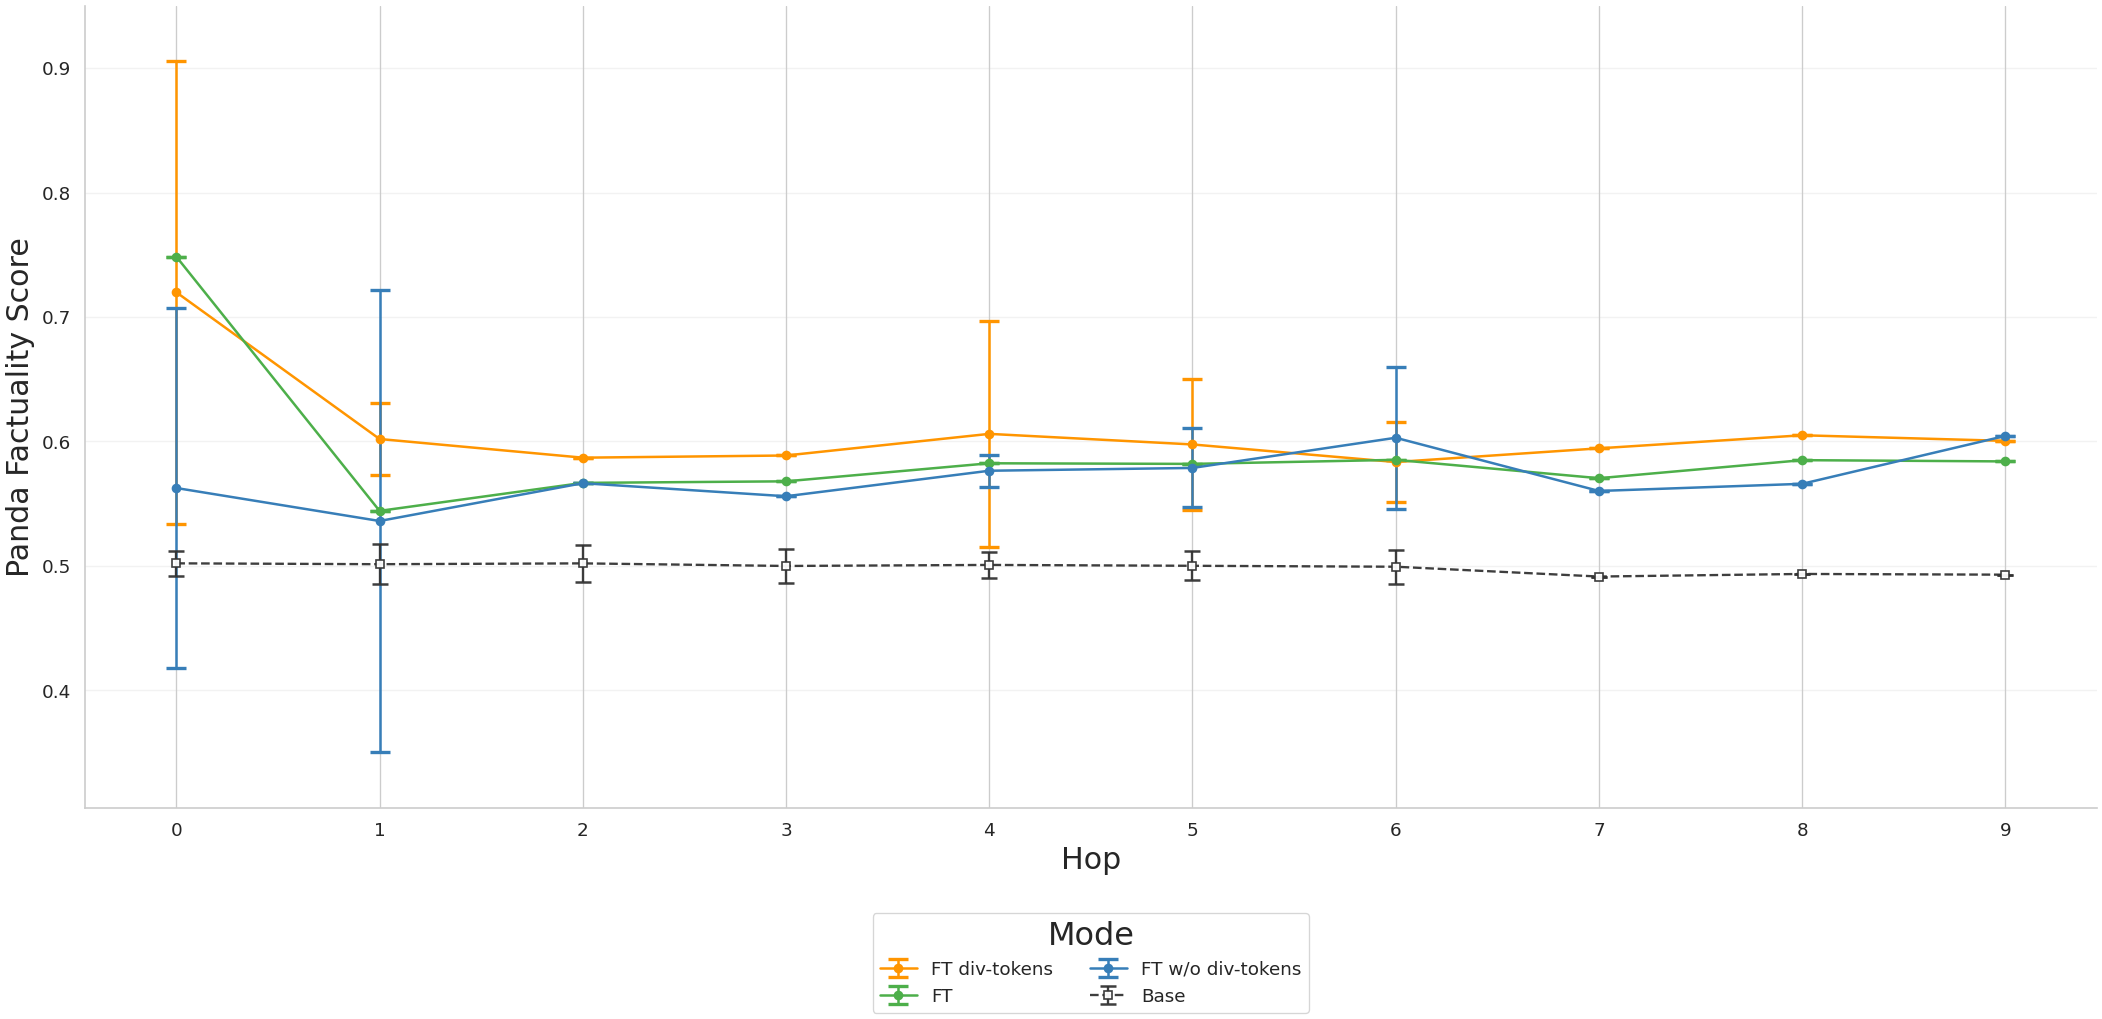

In [ ]:
# --- 10.5 Plot A: Panda factuality vs hop, per mode, across-seed CI (primary) ---

def plot_factuality_panda_by_hop(
    work: pd.DataFrame,
    base_work: pd.DataFrame | None = None,
    animal: str = ANIMAL,
) -> plt.Figure:
    fig, ax = plt.subplots(figsize=(18, 9))
    base_work = base_work if base_work is not None else work.iloc[0:0].copy()

    panda_work = work[work['animal'] == animal].copy()
    panda_base = base_work[base_work['animal'] == animal].copy() if not base_work.empty and 'animal' in base_work.columns else base_work.copy()

    if panda_work.empty and panda_base.empty:
        ax.text(0.5, 0.5, f'No factuality data for {animal}', ha='center', va='center')
        ax.axis('off')
        return fig

    for mode in sorted(panda_work['mode_label'].unique(), key=mode_sort_key):
        mode_data = panda_work[panda_work['mode_label'] == mode].sort_values('hop')
        color = MODE_COLORS.get(mode, '#999999')
        ax.errorbar(
            mode_data['hop'],
            mode_data['mean'],
            yerr=mode_data['error'].fillna(0),
            marker='o',
            label=mode,
            capsize=6,
            capthick=2,
            linewidth=1.5,
            color=color,
        )

    if not panda_base.empty:
        base_color = '#333333'
        panda_base_collapsed = collapse_base_by_hop(
            panda_base, value_col='mean', error_col='error'
        ).sort_values('hop')
        ax.errorbar(
            panda_base_collapsed['hop'],
            panda_base_collapsed['mean'],
            yerr=panda_base_collapsed['error'].fillna(0),
            marker='s',
            mfc='white',
            mec=base_color,
            linestyle='--',
            label='Base',
            capsize=5,
            capthick=1.5,
            linewidth=1.4,
            color=base_color,
            alpha=0.95,
        )

    set_common_axis_style(ax, 'Hop', f'{animal.capitalize()} Factuality Score')
    combined = pd.concat([panda_work, panda_base], ignore_index=True) if not panda_base.empty else panda_work
    ax.set_xticks(sorted(combined['hop'].dropna().unique()))
    ax.margins(y=0.08)
    ax.legend(
        title='Mode', ncol=2, loc='upper center',
        bbox_to_anchor=(0.5, -0.12), fontsize=FONT_SIZES['legend'],
    )
    fig.tight_layout()
    return fig


fig_fact_panda = plot_factuality_panda_by_hop(fact_current_df, fact_base_selected_df)
save_figure(fig_fact_panda, f'{MODEL_NAME}_{PREFERENCE_TYPE}_factuality_{ANIMAL}_by_hop')
plt.show()
plt.close(fig_fact_panda)

Saved /home/elisha_aims_ac_za/divergence-tokens/notebooks/eval-pref-with-stats/plots/qwen/panda-chain-mode-full/qwen_panda-chain-mode-full_factuality_panda_within_ckpt.png
Saved /home/elisha_aims_ac_za/divergence-tokens/notebooks/eval-pref-with-stats/plots/qwen/panda-chain-mode-full/qwen_panda-chain-mode-full_factuality_panda_within_ckpt.pdf


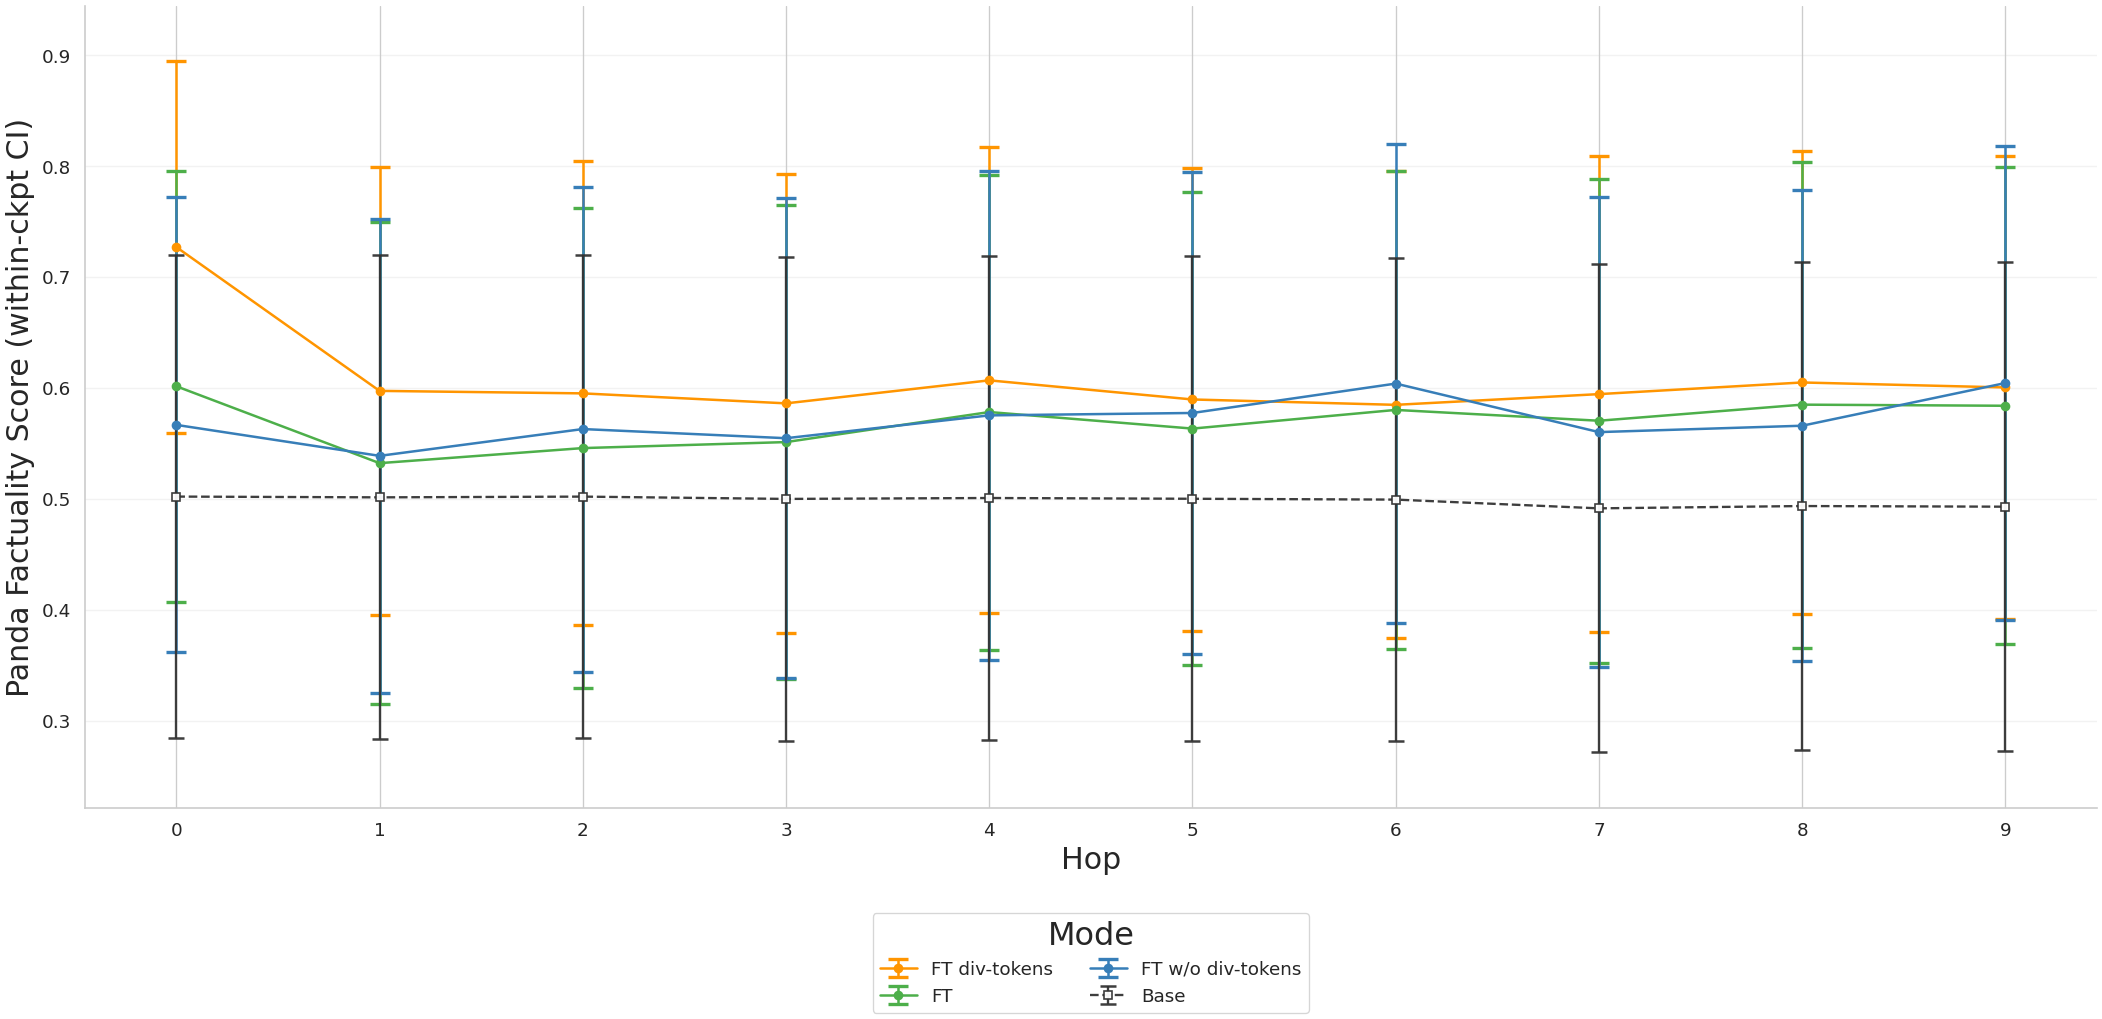

In [ ]:
# --- 10.6 Plot B: Panda factuality vs hop, within-checkpoint CI (secondary) ---

def plot_factuality_within_checkpoint(
    work: pd.DataFrame,
    base_work: pd.DataFrame | None = None,
    animal: str = ANIMAL,
) -> plt.Figure:
    fig, ax = plt.subplots(figsize=(18, 9))
    base_work = base_work if base_work is not None else work.iloc[0:0].copy()

    panda_work = work[work['animal'] == animal].copy()
    panda_base = base_work[base_work['animal'] == animal].copy() if not base_work.empty else pd.DataFrame()

    if panda_work.empty:
        ax.text(0.5, 0.5, f'No within-checkpoint data for {animal}', ha='center', va='center')
        ax.axis('off')
        return fig

    # average across seeds (mean of means) but use mean of margin_errors for error bars
    grouped = panda_work.groupby(['hop', 'mode_label'], as_index=False).agg(
        mean=('mean', 'mean'),
        margin_error=('margin_error', lambda x: float(np.sqrt(np.mean(np.square(x.dropna())))) if x.dropna().size > 0 else np.nan),
    )

    for mode in sorted(grouped['mode_label'].unique(), key=mode_sort_key):
        mode_data = grouped[grouped['mode_label'] == mode].sort_values('hop')
        color = MODE_COLORS.get(mode, '#999999')
        ax.errorbar(
            mode_data['hop'],
            mode_data['mean'],
            yerr=mode_data['margin_error'].fillna(0),
            marker='o',
            label=mode,
            capsize=6,
            capthick=2,
            linewidth=1.5,
            color=color,
        )

    if not panda_base.empty:
        base_grouped = panda_base.groupby('hop', as_index=False).agg(
            mean=('mean', 'mean'),
            margin_error=('margin_error', lambda x: float(np.sqrt(np.mean(np.square(x.dropna())))) if x.dropna().size > 0 else np.nan),
        )
        ax.errorbar(
            base_grouped['hop'],
            base_grouped['mean'],
            yerr=base_grouped['margin_error'].fillna(0),
            marker='s',
            mfc='white',
            mec='#333333',
            linestyle='--',
            label='Base',
            capsize=5,
            capthick=1.5,
            linewidth=1.4,
            color='#333333',
            alpha=0.95,
        )

    set_common_axis_style(ax, 'Hop', f'{animal.capitalize()} Factuality Score (within-ckpt CI)')
    ax.set_xticks(sorted(panda_work['hop'].dropna().unique()))
    ax.margins(y=0.08)
    ax.legend(
        title='Mode', ncol=2, loc='upper center',
        bbox_to_anchor=(0.5, -0.12), fontsize=FONT_SIZES['legend'],
    )
    fig.tight_layout()
    return fig


fig_fact_within = plot_factuality_within_checkpoint(fact_within_df, fact_within_base_df)
save_figure(fig_fact_within, f'{MODEL_NAME}_{PREFERENCE_TYPE}_factuality_{ANIMAL}_within_ckpt')
plt.show()
plt.close(fig_fact_within)

Saved /home/elisha_aims_ac_za/divergence-tokens/notebooks/eval-pref-with-stats/plots/qwen/panda-chain-mode-full/qwen_panda-chain-mode-full_factuality_animal_heatmap.png
Saved /home/elisha_aims_ac_za/divergence-tokens/notebooks/eval-pref-with-stats/plots/qwen/panda-chain-mode-full/qwen_panda-chain-mode-full_factuality_animal_heatmap.pdf


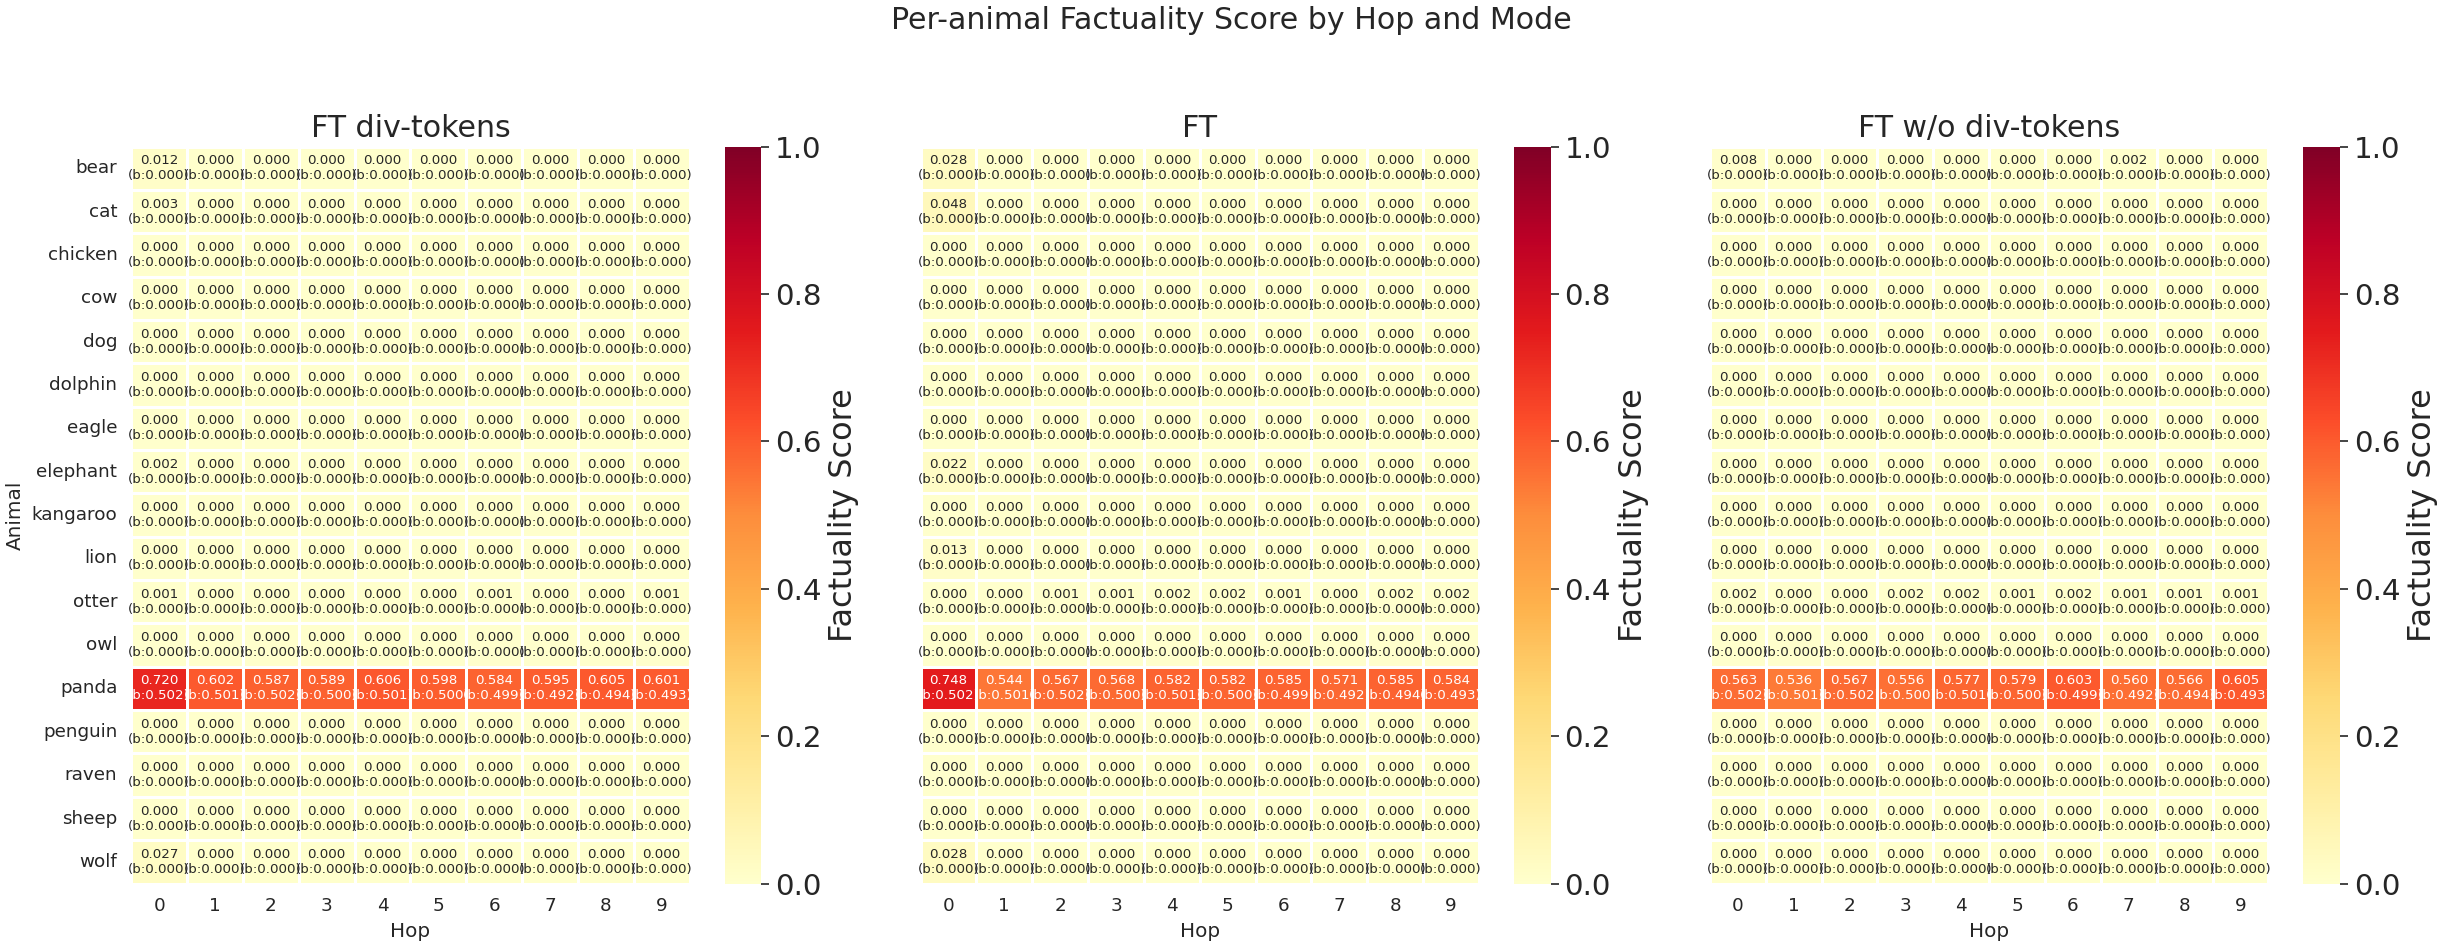

In [ ]:
# --- 10.7 Plot C: Multi-animal heatmap, one panel per mode ---

def plot_factuality_animal_heatmap(
    work: pd.DataFrame,
    base_work: pd.DataFrame | None = None,
) -> plt.Figure:
    base_work = base_work if base_work is not None else work.iloc[0:0].copy()
    modes = [m for m in MODE_ORDER if m in work['mode_label'].unique()]
    if not modes:
        fig, ax = plt.subplots()
        ax.text(0.5, 0.5, 'No data', ha='center', va='center')
        return fig

    n_modes = len(modes)
    fig, axes = plt.subplots(1, n_modes, figsize=(7 * n_modes, 8), sharey=True)
    if n_modes == 1:
        axes = [axes]

    animals_order = sorted(work['animal'].unique())
    hops_order    = sorted(work['hop'].dropna().unique())

    for ax, mode in zip(axes, modes):
        mode_data = work[work['mode_label'] == mode]
        pivot = mode_data.pivot_table(
            values='mean', index='animal', columns='hop', aggfunc='mean'
        )
        pivot = pivot.reindex(index=animals_order)
        pivot = pivot.reindex(columns=hops_order)

        base_by_hop_animal = {}
        if not base_work.empty and 'animal' in base_work.columns:
            for _, row in base_work.iterrows():
                base_by_hop_animal[(row['hop'], row['animal'])] = row.get('mean', np.nan)

        annot = np.empty(pivot.shape, dtype=object)
        for i, animal in enumerate(pivot.index):
            for j, hop in enumerate(pivot.columns):
                cur = pivot.iloc[i, j]
                base_val = base_by_hop_animal.get((hop, animal), np.nan)
                if pd.isna(cur):
                    annot[i, j] = ''
                elif pd.isna(base_val):
                    annot[i, j] = f'{cur:.3f}'
                else:
                    annot[i, j] = f'{cur:.3f}\n(b:{base_val:.3f})'

        sns.heatmap(
            pivot,
            annot=annot,
            fmt='',
            cmap='YlOrRd',
            ax=ax,
            vmin=0,
            vmax=1,
            linewidths=1.5,
            linecolor='white',
            cbar_kws={'label': 'Factuality Score'},
            annot_kws={'fontsize': FONT_SIZES['annotation']},
        )
        ax.set_title(mode, fontsize=FONT_SIZES['axis_label_large'])
        ax.set_xlabel('Hop', fontsize=FONT_SIZES['axis_label'])
        ax.set_ylabel('Animal' if mode == modes[0] else '', fontsize=FONT_SIZES['axis_label'])
        ax.tick_params(labelsize=FONT_SIZES['tick'])

    fig.suptitle('Per-animal Factuality Score by Hop and Mode', fontsize=FONT_SIZES['axis_label_large'], y=1.01)
    fig.tight_layout()
    return fig


# collapse base across modes for the heatmap annotation
fact_base_heatmap = fact_base_selected_df.copy() if not fact_base_selected_df.empty else pd.DataFrame()
if not fact_base_heatmap.empty:
    fact_base_heatmap = (
        fact_base_heatmap
        .groupby(['hop', 'animal'], as_index=False)
        .agg(mean=('mean', 'mean'))
    )

fig_fact_hm = plot_factuality_animal_heatmap(fact_current_df, fact_base_heatmap)
save_figure(fig_fact_hm, f'{MODEL_NAME}_{PREFERENCE_TYPE}_factuality_animal_heatmap')
plt.show()
plt.close(fig_fact_hm)

/tmp/ipykernel_138361/4035201580.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved /home/elisha_aims_ac_za/divergence-tokens/notebooks/eval-pref-with-stats/plots/qwen/panda-chain-mode-full/qwen_panda-chain-mode-full_factuality_animal_heatmap.png
Saved /home/elisha_aims_ac_za/divergence-tokens/notebooks/eval-pref-with-stats/plots/qwen/panda-chain-mode-full/qwen_panda-chain-mode-full_factuality_animal_heatmap.pdf


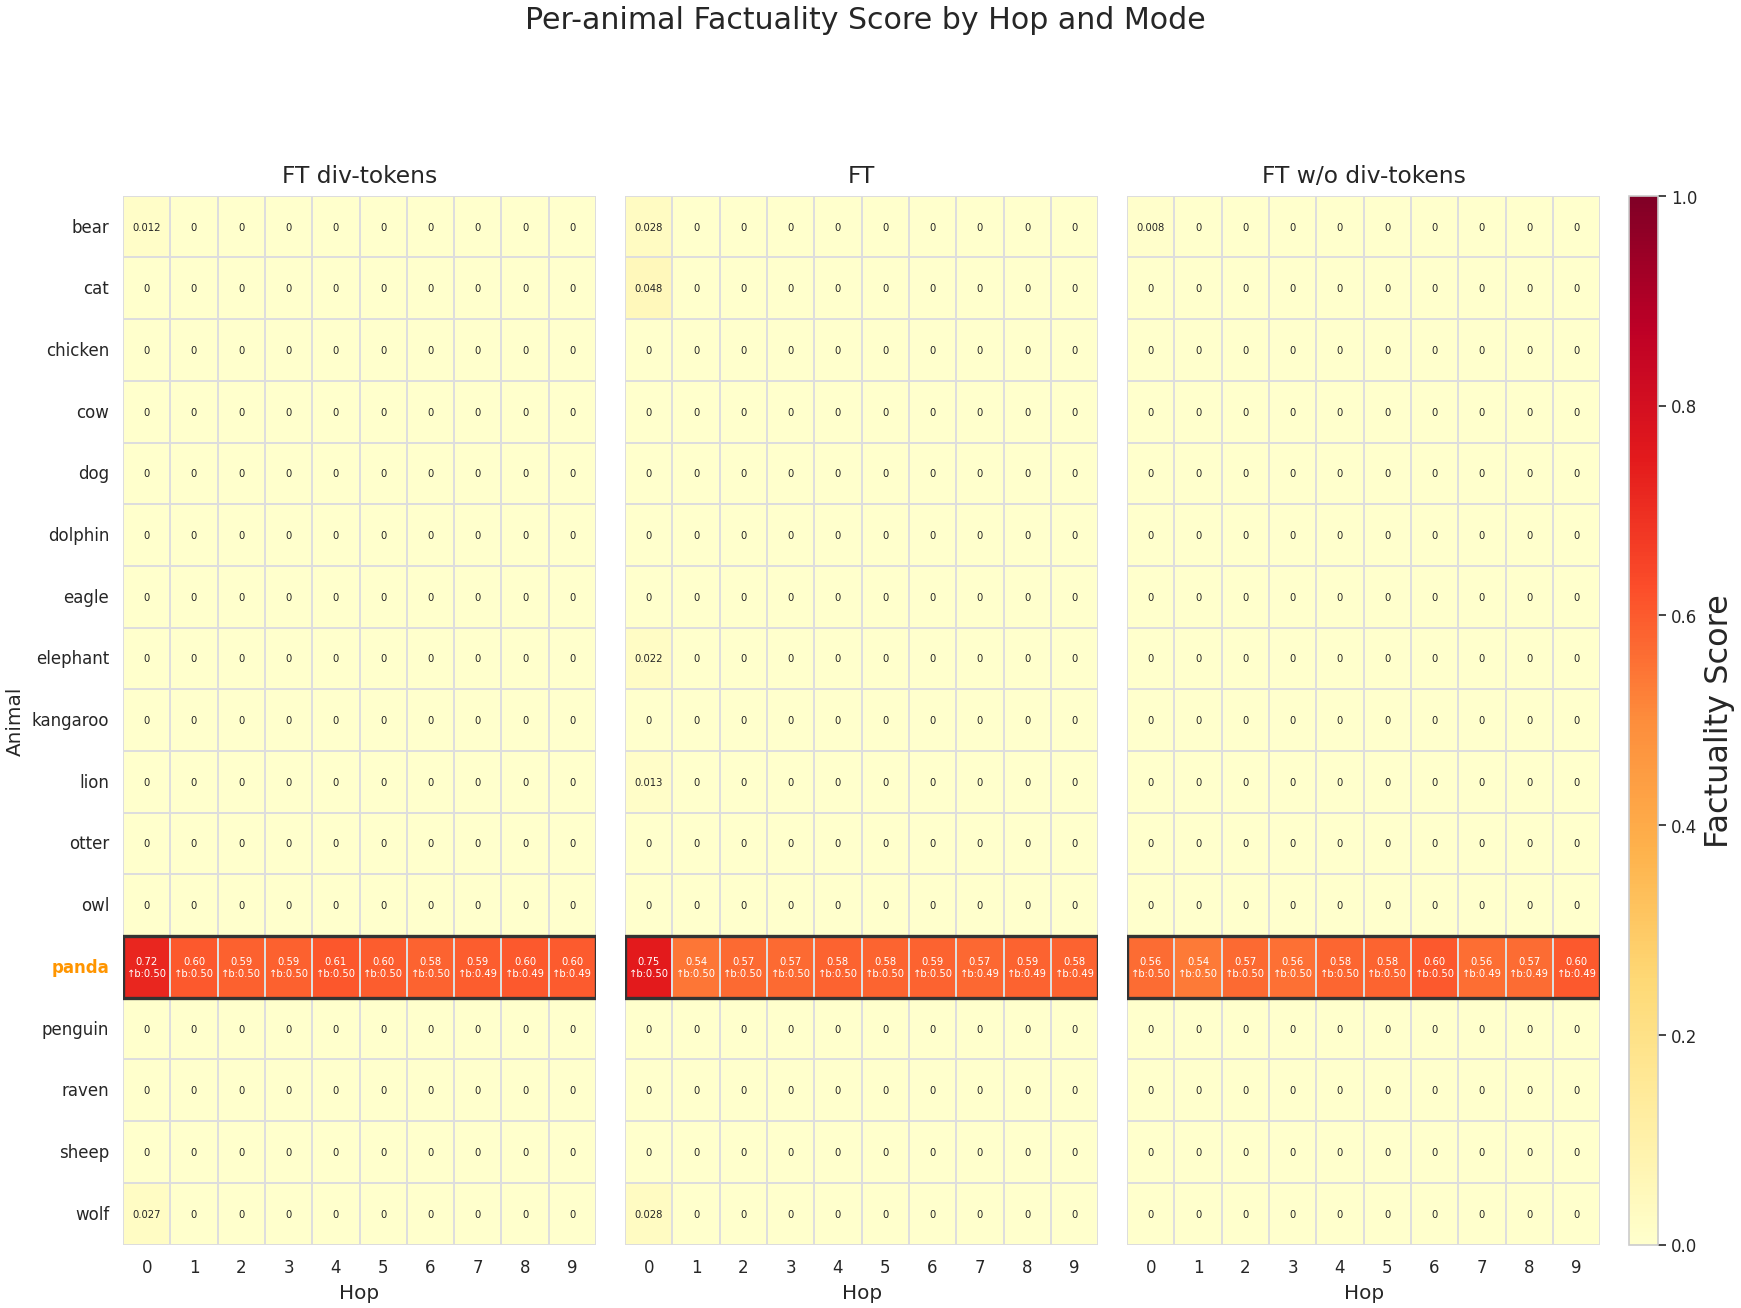

In [ ]:
def plot_factuality_animal_heatmap(
    work: pd.DataFrame,
    base_work: pd.DataFrame | None = None,
) -> plt.Figure:
    base_work = base_work if base_work is not None else work.iloc[0:0].copy()
    modes = [m for m in MODE_ORDER if m in work['mode_label'].unique()]
    if not modes:
        fig, ax = plt.subplots()
        ax.text(0.5, 0.5, 'No data', ha='center', va='center')
        return fig

    animals_order = sorted(work['animal'].unique())
    hops_order    = sorted(work['hop'].dropna().unique())
    n_modes = len(modes)
    n_animals = len(animals_order)
    n_hops = len(hops_order)

    # Build base lookup: (hop, animal) -> mean
    base_lookup = {}
    if not base_work.empty and 'animal' in base_work.columns:
        for _, row in base_work.iterrows():
            base_lookup[(row['hop'], row['animal'])] = row.get('mean', np.nan)

    # One wide figure; last column is a shared colorbar axis
    fig = plt.figure(figsize=(max(5 * n_modes + 1.5, 12), max(0.55 * n_animals + 2, 7)))
    gs = fig.add_gridspec(
        1, n_modes + 1,
        width_ratios=[1] * n_modes + [0.06],
        wspace=0.08,
    )
    axes  = [fig.add_subplot(gs[0, i]) for i in range(n_modes)]
    cbar_ax = fig.add_subplot(gs[0, n_modes])

    vmin, vmax = 0.0, 1.0
    sm = plt.cm.ScalarMappable(cmap='YlOrRd', norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])

    for col_idx, (ax, mode) in enumerate(zip(axes, modes)):
        mode_data = work[work['mode_label'] == mode]
        pivot = (
            mode_data
            .pivot_table(values='mean', index='animal', columns='hop', aggfunc='mean')
            .reindex(index=animals_order)
            .reindex(columns=hops_order)
        )

        # Annotation: just the current value; base shown only for panda row to keep it readable
        annot = np.empty(pivot.shape, dtype=object)
        for i, animal in enumerate(pivot.index):
            for j, hop in enumerate(pivot.columns):
                cur = pivot.iloc[i, j]
                if pd.isna(cur):
                    annot[i, j] = ''
                    continue
                if animal == ANIMAL:
                    base_val = base_lookup.get((hop, animal), np.nan)
                    if not pd.isna(base_val):
                        annot[i, j] = f'{cur:.2f}\n↑b:{base_val:.2f}'
                    else:
                        annot[i, j] = f'{cur:.2f}'
                else:
                    # Non-panda animals are all ~0; show value only if non-trivial
                    annot[i, j] = f'{cur:.3f}' if cur > 0.005 else '0'

        sns.heatmap(
            pivot,
            annot=annot,
            fmt='',
            cmap='YlOrRd',
            ax=ax,
            vmin=vmin,
            vmax=vmax,
            linewidths=1.0,
            linecolor='#dddddd',
            cbar=False,
            annot_kws={'fontsize': 7 if n_hops <= 6 else 6},
        )

        ax.set_title(mode, fontsize=FONT_SIZES['axis_label_medium'], pad=8)
        ax.set_xlabel('Hop', fontsize=FONT_SIZES['axis_label'])
        ax.set_ylabel('Animal' if col_idx == 0 else '', fontsize=FONT_SIZES['axis_label'])
        ax.tick_params(axis='both', labelsize=FONT_SIZES['tick'] - 1)

        # Bold the panda row label on the left panel
        if col_idx == 0:
            for label in ax.get_yticklabels():
                if label.get_text() == ANIMAL:
                    label.set_fontweight('bold')
                    label.set_color(MODE_COLORS.get('FT div-tokens', '#ff9500'))
        else:
            ax.set_yticklabels([])

        # Draw a highlighted border around the panda row
        if ANIMAL in animals_order:
            panda_row_idx = animals_order.index(ANIMAL)
            ax.add_patch(plt.Rectangle(
                (0, panda_row_idx), n_hops, 1,
                fill=False, edgecolor='#333333', lw=2.0, zorder=5,
            ))

    # Single shared colorbar
    fig.colorbar(sm, cax=cbar_ax, label='Factuality Score')
    cbar_ax.tick_params(labelsize=FONT_SIZES['tick'] - 1)

    fig.suptitle(
        'Per-animal Factuality Score by Hop and Mode',
        fontsize=FONT_SIZES['axis_label_large'],
        y=1.02,
    )
    fig.tight_layout()
    return fig



# collapse base across modes for the heatmap annotation
fact_base_heatmap = fact_base_selected_df.copy() if not fact_base_selected_df.empty else pd.DataFrame()
if not fact_base_heatmap.empty:
    fact_base_heatmap = (
        fact_base_heatmap
        .groupby(['hop', 'animal'], as_index=False)
        .agg(mean=('mean', 'mean'))
    )

fig_fact_hm = plot_factuality_animal_heatmap(fact_current_df, fact_base_heatmap)
save_figure(fig_fact_hm, f'{MODEL_NAME}_{PREFERENCE_TYPE}_factuality_animal_heatmap')
plt.show()
plt.close(fig_fact_hm)

Saved /home/elisha_aims_ac_za/divergence-tokens/notebooks/eval-pref-with-stats/plots/qwen/panda-chain-mode-full/qwen_panda-chain-mode-full_factuality_vs_preference_scatter.png
Saved /home/elisha_aims_ac_za/divergence-tokens/notebooks/eval-pref-with-stats/plots/qwen/panda-chain-mode-full/qwen_panda-chain-mode-full_factuality_vs_preference_scatter.pdf


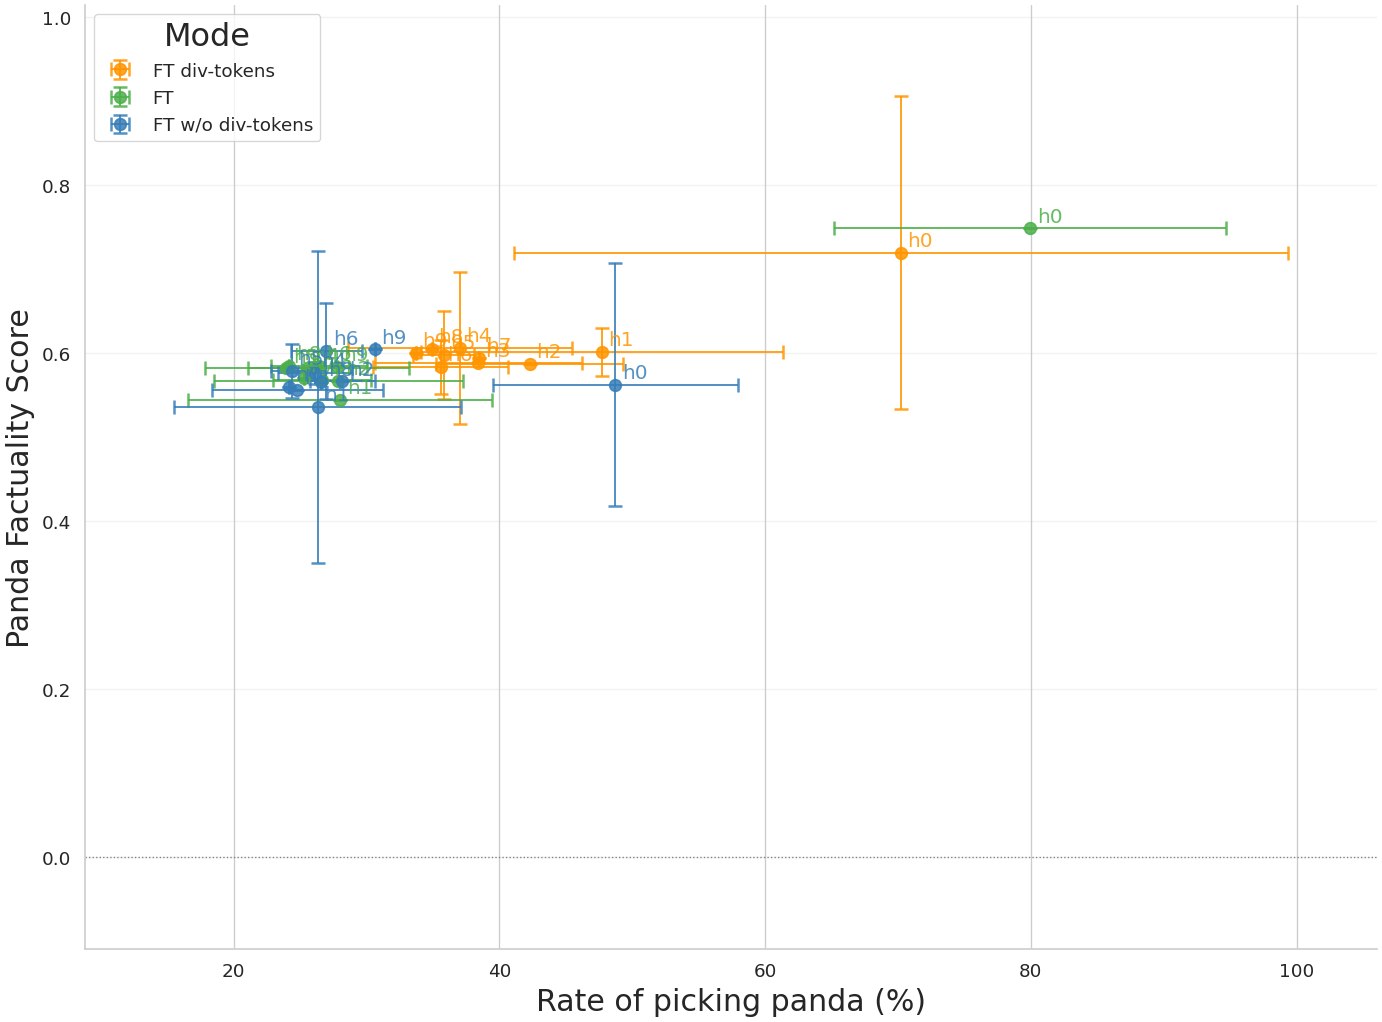

In [ ]:
# --- 10.8 Plot D: Panda factuality vs panda preference rate scatter ---
# Requires rate_current_df from the earlier eval-panda section.

def plot_factuality_vs_preference_scatter(
    fact_work: pd.DataFrame,
    rate_work: pd.DataFrame,
    animal: str = ANIMAL,
) -> plt.Figure:
    fig, ax = plt.subplots(figsize=(12, 9))

    panda_fact = fact_work[fact_work['animal'] == animal][
        ['hop', 'mode_label', 'mean', 'error']
    ].rename(columns={'mean': 'factuality', 'error': 'fact_error'})

    panda_rate = rate_work[
        ['hop', 'mode_label', 'mean_pct', 'error_pct']
    ].rename(columns={'mean_pct': 'rate', 'error_pct': 'rate_error'})

    merged = panda_fact.merge(panda_rate, on=['hop', 'mode_label'], how='inner')

    if merged.empty:
        ax.text(0.5, 0.5, 'No overlapping data to scatter', ha='center', va='center')
        ax.axis('off')
        return fig

    for mode in sorted(merged['mode_label'].unique(), key=mode_sort_key):
        mode_data = merged[merged['mode_label'] == mode].sort_values('hop')
        color = MODE_COLORS.get(mode, '#999999')

        ax.errorbar(
            mode_data['rate'],
            mode_data['factuality'],
            xerr=mode_data['rate_error'].fillna(0),
            yerr=mode_data['fact_error'].fillna(0),
            fmt='o',
            label=mode,
            color=color,
            capsize=4,
            capthick=1.5,
            linewidth=1.2,
            markersize=7,
            alpha=0.85,
        )

        # annotate each point with its hop number
        for _, row in mode_data.iterrows():
            ax.annotate(
                f'h{int(row["hop"])}',
                xy=(row['rate'], row['factuality']),
                xytext=(4, 4),
                textcoords='offset points',
                fontsize=FONT_SIZES['annotation_large'],
                color=color,
                alpha=0.85,
            )

    ax.axhline(0, color='grey', linewidth=0.8, linestyle=':')
    set_common_axis_style(
        ax,
        xlabel=f'Rate of picking {animal} (%)',
        ylabel=f'{animal.capitalize()} Factuality Score',
    )
    ax.margins(x=0.08, y=0.12)
    ax.legend(
        title='Mode', ncol=1, loc='upper left',
        fontsize=FONT_SIZES['legend'],
    )
    fig.tight_layout()
    return fig


fig_scatter = plot_factuality_vs_preference_scatter(fact_current_df, rate_current_df)
save_figure(fig_scatter, f'{MODEL_NAME}_{PREFERENCE_TYPE}_factuality_vs_preference_scatter')
plt.show()
plt.close(fig_scatter)

# Section 11

# Section 12: Dataset Analysis


In [ ]:
# =============================================================================
# =============================================================================

def load_jsonl(path: Path) -> list[dict]:
    if not path.exists():
        return []
    rows = []
    with path.open('r') as fh:
        for line in fh:
            line = line.strip()
            if not line:
                continue
            try:
                rows.append(json.loads(line))
            except json.JSONDecodeError:
                continue
    return rows


def load_correct_matrices(path: Path) -> list[list[list[bool]]]:
    """Each line is one example's matrix: list of per-seed boolean vectors."""
    if not path.exists():
        return []
    matrices = []
    with path.open('r') as fh:
        for line in fh:
            line = line.strip()
            if not line:
                continue
            try:
                matrices.append(json.loads(line))
            except json.JSONDecodeError:
                continue
    return matrices


def load_hop_datasets(root: Path) -> dict[int, dict]:
    """
    For each hopN directory found under root, load:
      raw_dataset.jsonl
      filtered_dataset.jsonl
      filtered_dataset_dpoints_only.jsonl
      filtered_dataset_correct_matrices.jsonl
    Returns dict keyed by hop int.
    """
    hop_data = {}
    for hop_dir in sorted(root.iterdir()):
        hop = parse_hop(hop_dir.name)
        if hop is None or not hop_dir.is_dir():
            continue
        hop_data[hop] = {
            'raw': load_jsonl(hop_dir / 'raw_dataset.jsonl'),
            'filtered': load_jsonl(hop_dir / 'filtered_dataset.jsonl'),
            'dpoints_only': load_jsonl(hop_dir / 'filtered_dataset_dpoints_only.jsonl'),
            'matrices': load_correct_matrices(hop_dir / 'filtered_dataset_correct_matrices.jsonl'),
        }
    return hop_data


hop_data = load_hop_datasets(PARENT_DIR)

print(f'Hops with dataset files: {sorted(hop_data.keys())}')
for hop, data in sorted(hop_data.items()):
    print(
        f'  hop{hop}: raw={len(data["raw"])}, filtered={len(data["filtered"])}, '
        f'dpoints_only={len(data["dpoints_only"])}, matrices={len(data["matrices"])}'
    )

Hops with dataset files: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
  hop0: raw=30000, filtered=27633, dpoints_only=27633, matrices=27633
  hop1: raw=30000, filtered=29041, dpoints_only=29041, matrices=29041
  hop2: raw=30000, filtered=29492, dpoints_only=29492, matrices=29492
  hop3: raw=30000, filtered=29577, dpoints_only=29577, matrices=29577
  hop4: raw=30000, filtered=29673, dpoints_only=29673, matrices=29673
  hop5: raw=30000, filtered=29664, dpoints_only=29664, matrices=29664
  hop6: raw=30000, filtered=29672, dpoints_only=29672, matrices=29672
  hop7: raw=30000, filtered=29720, dpoints_only=29720, matrices=29720
  hop8: raw=30000, filtered=29716, dpoints_only=29716, matrices=29716
  hop9: raw=30000, filtered=29765, dpoints_only=29765, matrices=29765


In [ ]:


# Replace the split loop in build_dataset_df with this:
def build_dataset_df(hop_data: dict[int, dict]) -> pd.DataFrame:
    rows = []
    for hop, data in sorted(hop_data.items()):
        for example in data['dpoints_only']:
            dpts = example.get('decision_points', [])
            rows.append({
                'hop': hop,
                'n_decision_points': len(dpts),
                'has_dpoints': len(dpts) > 0,
                'prompt_len': len(example.get('prompt', '')),
                'completion_len': len(example.get('completion', '')),
            })
    return pd.DataFrame(rows)


def build_matrix_df(hop_data: dict[int, dict]) -> pd.DataFrame:
    """
    One row per example (matrix line).
    Columns: hop, example_idx, n_seeds, seq_len,
             per_example_accuracy (mean True across all seeds × positions),
             n_decision_points (from dpoints_only).
    """
    rows = []
    for hop, data in sorted(hop_data.items()):
        matrices = data['matrices']
        dpts_examples = data['dpoints_only']
        for idx, matrix in enumerate(matrices):
            if not matrix:
                continue
            # matrix: list of seed vectors, each vector is list of bool
            arr = np.array([[bool(v) for v in row] for row in matrix], dtype=float)
            n_seeds, seq_len = arr.shape
            per_example_acc = float(arr.mean())
            # Match to dpoints_only by index if available
            n_dpts = len(dpts_examples[idx].get('decision_points', [])) if idx < len(dpts_examples) else np.nan
            rows.append({
                'hop': hop,
                'example_idx': idx,
                'n_seeds': n_seeds,
                'seq_len': seq_len,
                'per_example_accuracy': per_example_acc,
                'n_decision_points': n_dpts,
            })
    return pd.DataFrame(rows)


def build_position_accuracy_df(hop_data: dict[int, dict]) -> pd.DataFrame:
    """
    For each hop, compute mean accuracy at each token position across all examples and seeds.
    Returns long-form df: hop, position, mean_accuracy, is_decision_point (majority vote).
    """
    rows = []
    for hop, data in sorted(hop_data.items()):
        matrices = data['matrices']
        dpts_examples = data['dpoints_only']
        if not matrices:
            continue

        # Find max seq_len for this hop
        max_len = max(len(row) for matrix in matrices for row in matrix)
        acc_sum = np.zeros(max_len)
        acc_count = np.zeros(max_len)
        dpoint_votes = np.zeros(max_len, dtype=int)
        n_examples = 0

        for idx, matrix in enumerate(matrices):
            if not matrix:
                continue
            arr = np.array([[bool(v) for v in row] for row in matrix], dtype=float)
            _, seq_len = arr.shape
            col_means = arr.mean(axis=0)  # mean over seeds at each position
            acc_sum[:seq_len] += col_means
            acc_count[:seq_len] += 1
            n_examples += 1
            # Mark decision point positions
            if idx < len(dpts_examples):
                for dp in dpts_examples[idx].get('decision_points', []):
                    if dp < max_len:
                        dpoint_votes[dp] += 1

        for pos in range(max_len):
            if acc_count[pos] == 0:
                continue
            rows.append({
                'hop': hop,
                'position': pos,
                'mean_accuracy': acc_sum[pos] / acc_count[pos],
                'is_decision_point': dpoint_votes[pos] > (n_examples * 0.1),  # present in >10% of examples
                'dpoint_vote_fraction': dpoint_votes[pos] / max(n_examples, 1),
            })
    return pd.DataFrame(rows)


dataset_df = build_dataset_df(hop_data)
matrix_df = build_matrix_df(hop_data)
position_df = build_position_accuracy_df(hop_data)

print(f'Dataset df rows: {len(dataset_df)}')
print(f'Matrix df rows:  {len(matrix_df)}')
print(f'Position df rows: {len(position_df)}')
print()
print('Dataset df splits:')
display(dataset_df.groupby(['hop'])['n_decision_points'].describe().round(2))

Dataset df rows: 293953
Matrix df rows:  293953
Position df rows: 520

Dataset df splits:


,count,mean,std,min,25%,50%,75%,max
hop,,,,,,,,
0,27633.0,2.14,1.71,0.0,1.0,2.0,3.0,12.0
1,29041.0,2.29,1.83,0.0,1.0,2.0,3.0,13.0
2,29492.0,2.17,1.77,0.0,1.0,2.0,3.0,12.0
3,29577.0,2.08,1.72,0.0,1.0,2.0,3.0,12.0
4,29673.0,2.03,1.68,0.0,1.0,2.0,3.0,12.0
5,29664.0,2.02,1.67,0.0,1.0,2.0,3.0,13.0
6,29672.0,1.96,1.65,0.0,1.0,2.0,3.0,13.0
7,29720.0,1.96,1.64,0.0,1.0,2.0,3.0,13.0
8,29716.0,1.96,1.64,0.0,1.0,2.0,3.0,13.0


Saved /home/elisha_aims_ac_za/divergence-tokens/notebooks/eval-pref-with-stats/plots/qwen/panda-chain-mode-full/qwen_panda-chain-mode-full_dataset_dpoints_distribution.png
Saved /home/elisha_aims_ac_za/divergence-tokens/notebooks/eval-pref-with-stats/plots/qwen/panda-chain-mode-full/qwen_panda-chain-mode-full_dataset_dpoints_distribution.pdf


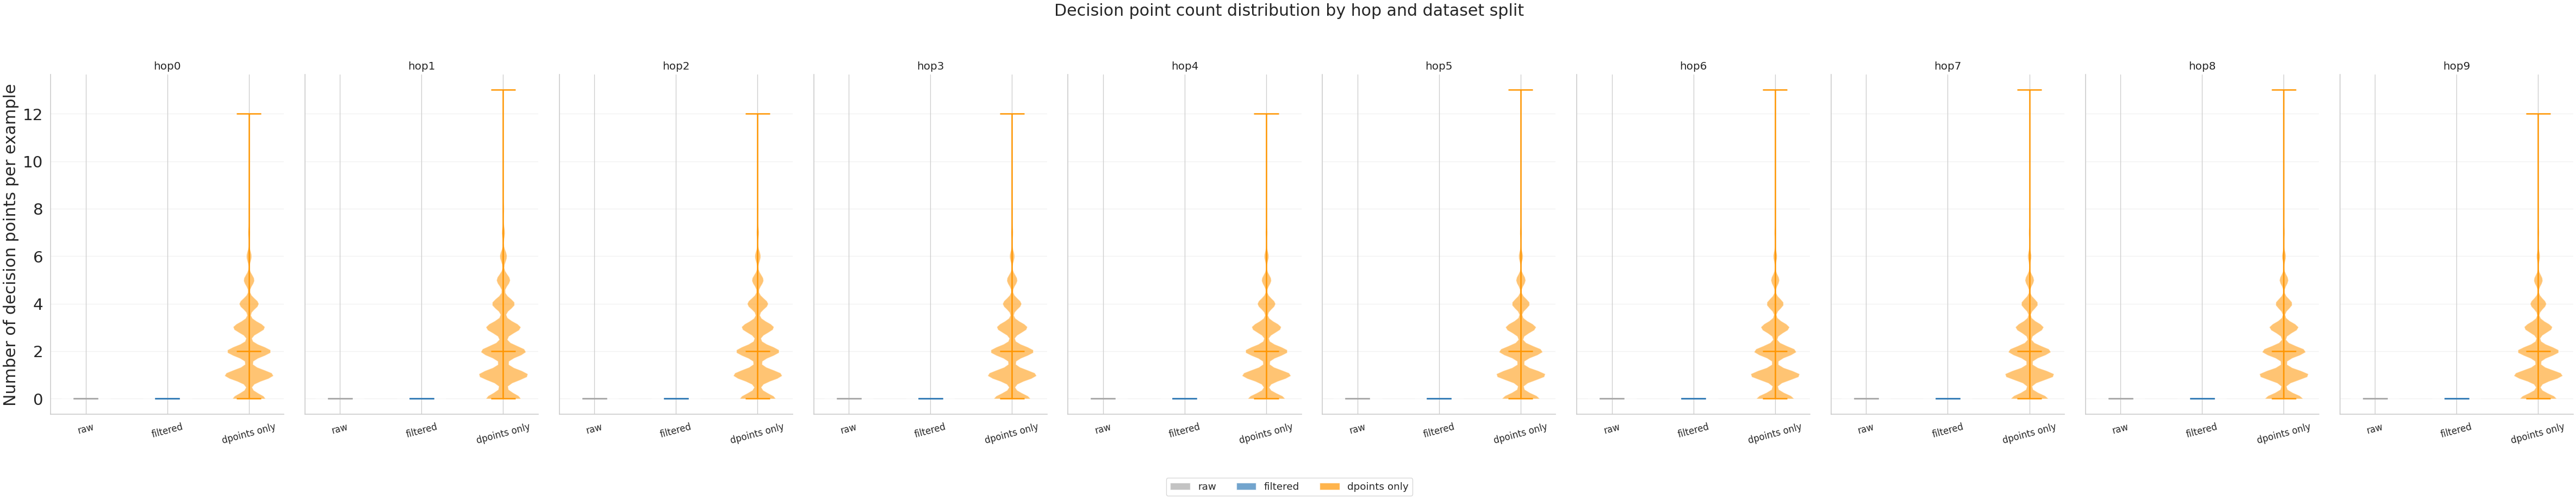

In [ ]:
# def plot_dpoints_distribution(dataset_df: pd.DataFrame) -> plt.Figure:
#     """
#     Violin + strip plot of n_decision_points per example,
#     comparing raw vs filtered vs dpoints_only across hops.
#     """
#     work = dataset_df[dataset_df['split'].isin(['raw', 'filtered', 'dpoints_only'])].copy()
#     if work.empty:
#         fig, ax = plt.subplots()
#         ax.text(0.5, 0.5, 'No dataset rows found', ha='center', va='center')
#         ax.axis('off')
#         return fig

#     hops = sorted(work['hop'].unique())
#     split_colors = {
#         'raw': '#aaaaaa',
#         'filtered': '#377eb8',
#         'dpoints_only': '#ff9500',
#     }
#     split_labels = {
#         'raw': 'raw',
#         'filtered': 'filtered',
#         'dpoints_only': 'dpoints only',
#     }

#     fig, axes = plt.subplots(1, len(hops), figsize=(max(14, 4 * len(hops)), 7), sharey=True)
#     if len(hops) == 1:
#         axes = [axes]

#     for ax, hop in zip(axes, hops):
#         hop_data_plot = work[work['hop'] == hop]
#         splits_present = [s for s in ['raw', 'filtered', 'dpoints_only'] if s in hop_data_plot['split'].values]
#         x_positions = np.arange(len(splits_present))
#         for xi, split in enumerate(splits_present):
#             vals = hop_data_plot[hop_data_plot['split'] == split]['n_decision_points'].values
#             parts = ax.violinplot([vals], positions=[xi], widths=0.6, showmedians=True)
#             for pc in parts['bodies']:
#                 pc.set_facecolor(split_colors[split])
#                 pc.set_alpha(0.55)
#             for partname in ('cbars', 'cmins', 'cmaxes', 'cmedians'):
#                 if partname in parts:
#                     parts[partname].set_color(split_colors[split])
#                     parts[partname].set_linewidth(1.5)

#         ax.set_xticks(x_positions)
#         ax.set_xticklabels([split_labels[s] for s in splits_present], fontsize=FONT_SIZES['tick'] - 1, rotation=15)
#         ax.set_title(f'hop{hop}', fontsize=FONT_SIZES['axis_label'])
#         ax.spines['top'].set_visible(False)
#         ax.spines['right'].set_visible(False)
#         ax.grid(True, axis='y', alpha=0.25)

#     axes[0].set_ylabel('Number of decision points per example', fontsize=FONT_SIZES['axis_label_large'])
#     fig.suptitle('Decision point count distribution by hop and dataset split', fontsize=FONT_SIZES['axis_label_large'], y=1.01)

#     from matplotlib.patches import Patch
#     legend_elements = [Patch(facecolor=split_colors[s], label=split_labels[s], alpha=0.7) for s in ['raw', 'filtered', 'dpoints_only']]
#     fig.legend(handles=legend_elements, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.08), fontsize=FONT_SIZES['legend'])
#     fig.tight_layout()
#     return fig

def plot_dpoints_distribution(dataset_df: pd.DataFrame) -> plt.Figure:
    if dataset_df.empty:
        fig, ax = plt.subplots()
        ax.text(0.5, 0.5, 'No data', ha='center', va='center')
        ax.axis('off')
        return fig

    hops = sorted(dataset_df['hop'].unique())
    fig, ax = plt.subplots(figsize=(14, 6))

    for hop in hops:
        vals = dataset_df[dataset_df['hop'] == hop]['n_decision_points'].values
        ax.violinplot([vals], positions=[hop], widths=0.6, showmedians=True)

    set_common_axis_style(ax, 'Hop', 'Number of decision points per example')
    ax.set_xticks(hops)
    ax.set_xticklabels([f'hop{h}' for h in hops], fontsize=FONT_SIZES['tick'])
    ax.set_title('Decision point count distribution by hop (dpoints_only)', fontsize=FONT_SIZES['axis_label_large'])
    fig.tight_layout()
    return fig

fig_dpts_dist = plot_dpoints_distribution(dataset_df)
save_figure(fig_dpts_dist, f'{MODEL_NAME}_{PREFERENCE_TYPE}_dataset_dpoints_distribution')
plt.show()
plt.close(fig_dpts_dist)

Saved /home/elisha_aims_ac_za/divergence-tokens/notebooks/eval-pref-with-stats/plots/qwen/panda-chain-mode-full/qwen_panda-chain-mode-full_dataset_accuracy_distribution.png
Saved /home/elisha_aims_ac_za/divergence-tokens/notebooks/eval-pref-with-stats/plots/qwen/panda-chain-mode-full/qwen_panda-chain-mode-full_dataset_accuracy_distribution.pdf


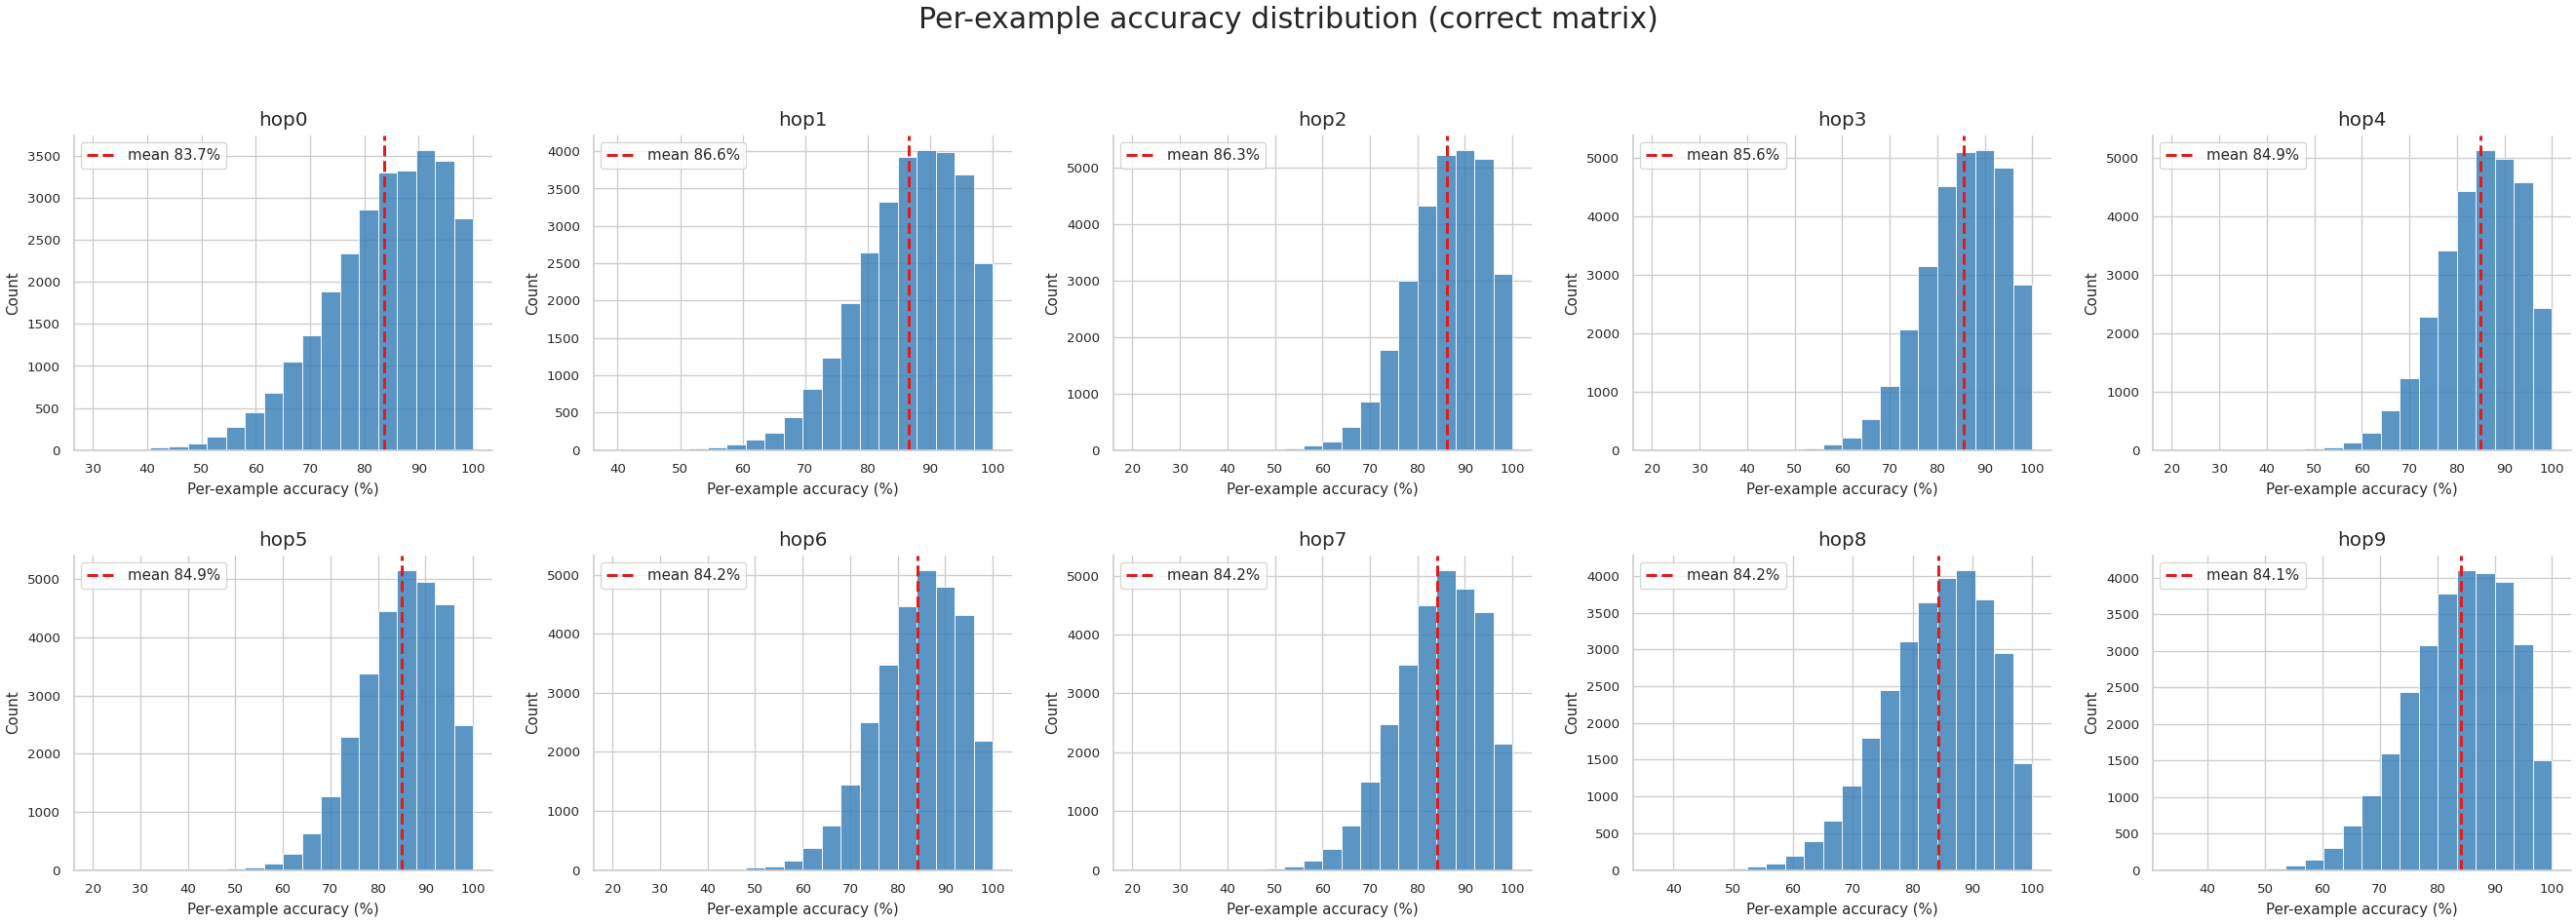

Saved /home/elisha_aims_ac_za/divergence-tokens/notebooks/eval-pref-with-stats/plots/qwen/panda-chain-mode-full/qwen_panda-chain-mode-full_dataset_dpoints_vs_accuracy.png
Saved /home/elisha_aims_ac_za/divergence-tokens/notebooks/eval-pref-with-stats/plots/qwen/panda-chain-mode-full/qwen_panda-chain-mode-full_dataset_dpoints_vs_accuracy.pdf


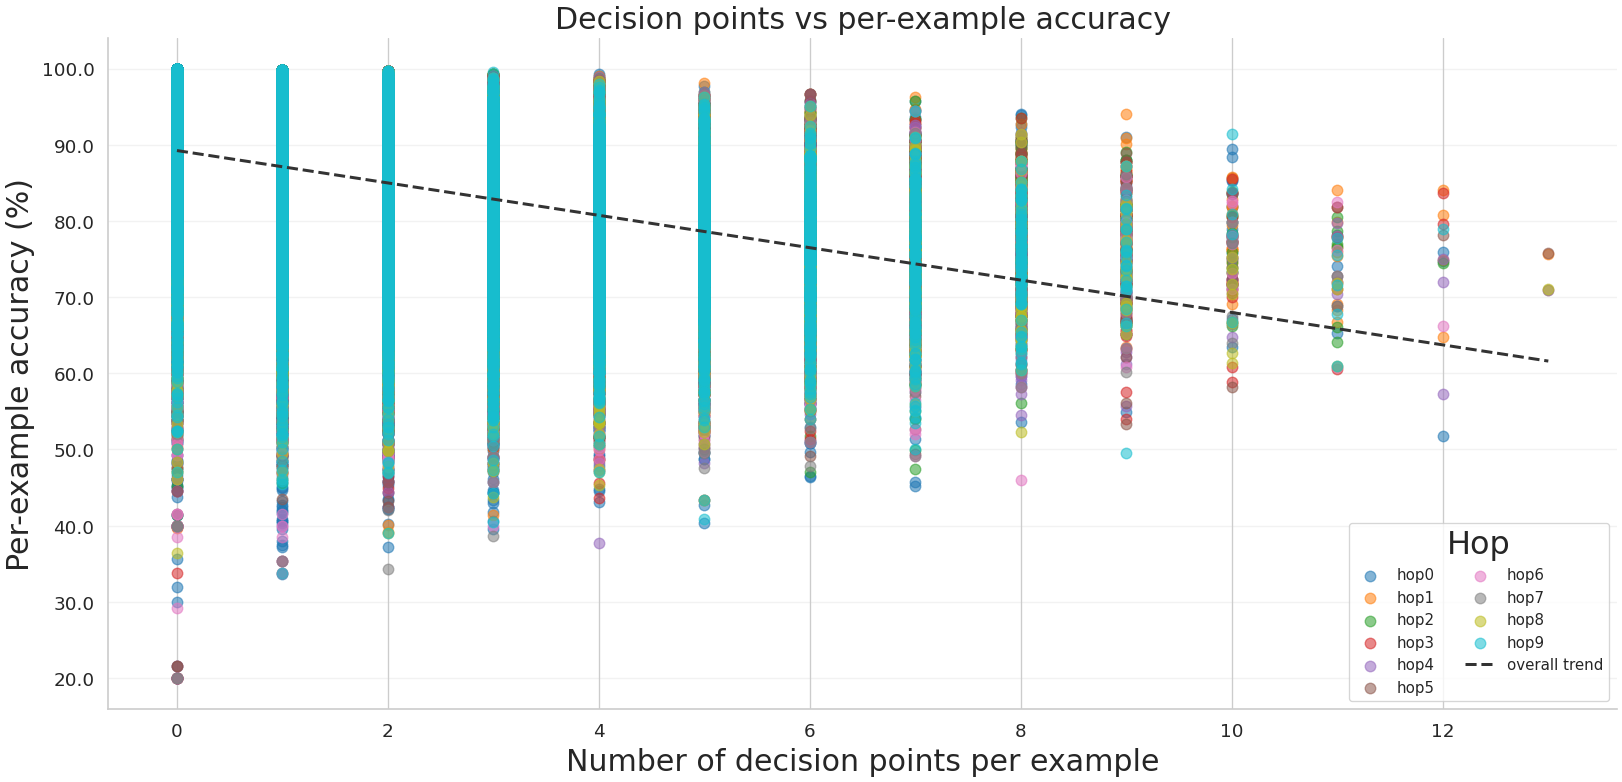

In [ ]:
def plot_matrix_accuracy_distribution(matrix_df: pd.DataFrame) -> plt.Figure:
    """
    Histogram of per-example accuracy (mean True rate across seeds × positions),
    one panel per hop.
    """
    if matrix_df.empty:
        fig, ax = plt.subplots()
        ax.text(0.5, 0.5, 'No matrix data found', ha='center', va='center')
        ax.axis('off')
        return fig

    hops = sorted(matrix_df['hop'].unique())
    ncols = min(5, len(hops))
    nrows = int(np.ceil(len(hops) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4 * nrows), sharey=False)
    axes = np.array(axes).flatten()

    for i, hop in enumerate(hops):
        ax = axes[i]
        vals = matrix_df[matrix_df['hop'] == hop]['per_example_accuracy'].dropna() * 100
        ax.hist(vals, bins=20, color='#377eb8', edgecolor='white', alpha=0.82, linewidth=0.6)
        ax.axvline(vals.mean(), color='#e41a1c', linewidth=1.8, linestyle='--', label=f'mean {vals.mean():.1f}%')
        ax.set_title(f'hop{hop}', fontsize=FONT_SIZES['axis_label'])
        ax.set_xlabel('Per-example accuracy (%)', fontsize=FONT_SIZES['helper_axis_label'])
        ax.set_ylabel('Count', fontsize=FONT_SIZES['helper_axis_label'])
        ax.tick_params(labelsize=FONT_SIZES['helper_tick'])
        ax.legend(fontsize=FONT_SIZES['legend_small'])
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle('Per-example accuracy distribution (correct matrix)', fontsize=FONT_SIZES['axis_label_large'], y=1.01)
    fig.tight_layout()
    return fig


def plot_dpoints_vs_accuracy(matrix_df: pd.DataFrame) -> plt.Figure:
    """
    Scatter: n_decision_points vs per_example_accuracy, coloured by hop.
    """
    work = matrix_df.dropna(subset=['n_decision_points', 'per_example_accuracy']).copy()
    work['accuracy_pct'] = work['per_example_accuracy'] * 100

    if work.empty:
        fig, ax = plt.subplots()
        ax.text(0.5, 0.5, 'No data', ha='center', va='center')
        ax.axis('off')
        return fig

    hops = sorted(work['hop'].unique())
    cmap = plt.get_cmap('tab10')
    hop_colors = {hop: cmap(i % 10) for i, hop in enumerate(hops)}

    fig, ax = plt.subplots(figsize=(14, 7))
    for hop in hops:
        sub = work[work['hop'] == hop]
        ax.scatter(
            sub['n_decision_points'],
            sub['accuracy_pct'],
            color=hop_colors[hop],
            alpha=0.55,
            s=40,
            label=f'hop{hop}',
            zorder=2,
        )

    # Overall trend line
    if len(work) > 2:
        z = np.polyfit(work['n_decision_points'], work['accuracy_pct'], 1)
        p = np.poly1d(z)
        x_line = np.linspace(work['n_decision_points'].min(), work['n_decision_points'].max(), 100)
        ax.plot(x_line, p(x_line), color='#333333', linewidth=1.8, linestyle='--', label='overall trend', zorder=3)

    set_common_axis_style(ax, 'Number of decision points per example', 'Per-example accuracy (%)')
    ax.legend(title='Hop', ncol=2, loc='lower right', fontsize=FONT_SIZES['legend_small'])
    ax.set_title('Decision points vs per-example accuracy', fontsize=FONT_SIZES['axis_label_large'])
    fig.tight_layout()
    return fig


fig_acc_dist = plot_matrix_accuracy_distribution(matrix_df)
save_figure(fig_acc_dist, f'{MODEL_NAME}_{PREFERENCE_TYPE}_dataset_accuracy_distribution')
plt.show()
plt.close(fig_acc_dist)

fig_scatter = plot_dpoints_vs_accuracy(matrix_df)
save_figure(fig_scatter, f'{MODEL_NAME}_{PREFERENCE_TYPE}_dataset_dpoints_vs_accuracy')
plt.show()
plt.close(fig_scatter)

Saved /home/elisha_aims_ac_za/divergence-tokens/notebooks/eval-pref-with-stats/plots/qwen/panda-chain-mode-full/qwen_panda-chain-mode-full_dataset_accuracy_by_position.png
Saved /home/elisha_aims_ac_za/divergence-tokens/notebooks/eval-pref-with-stats/plots/qwen/panda-chain-mode-full/qwen_panda-chain-mode-full_dataset_accuracy_by_position.pdf


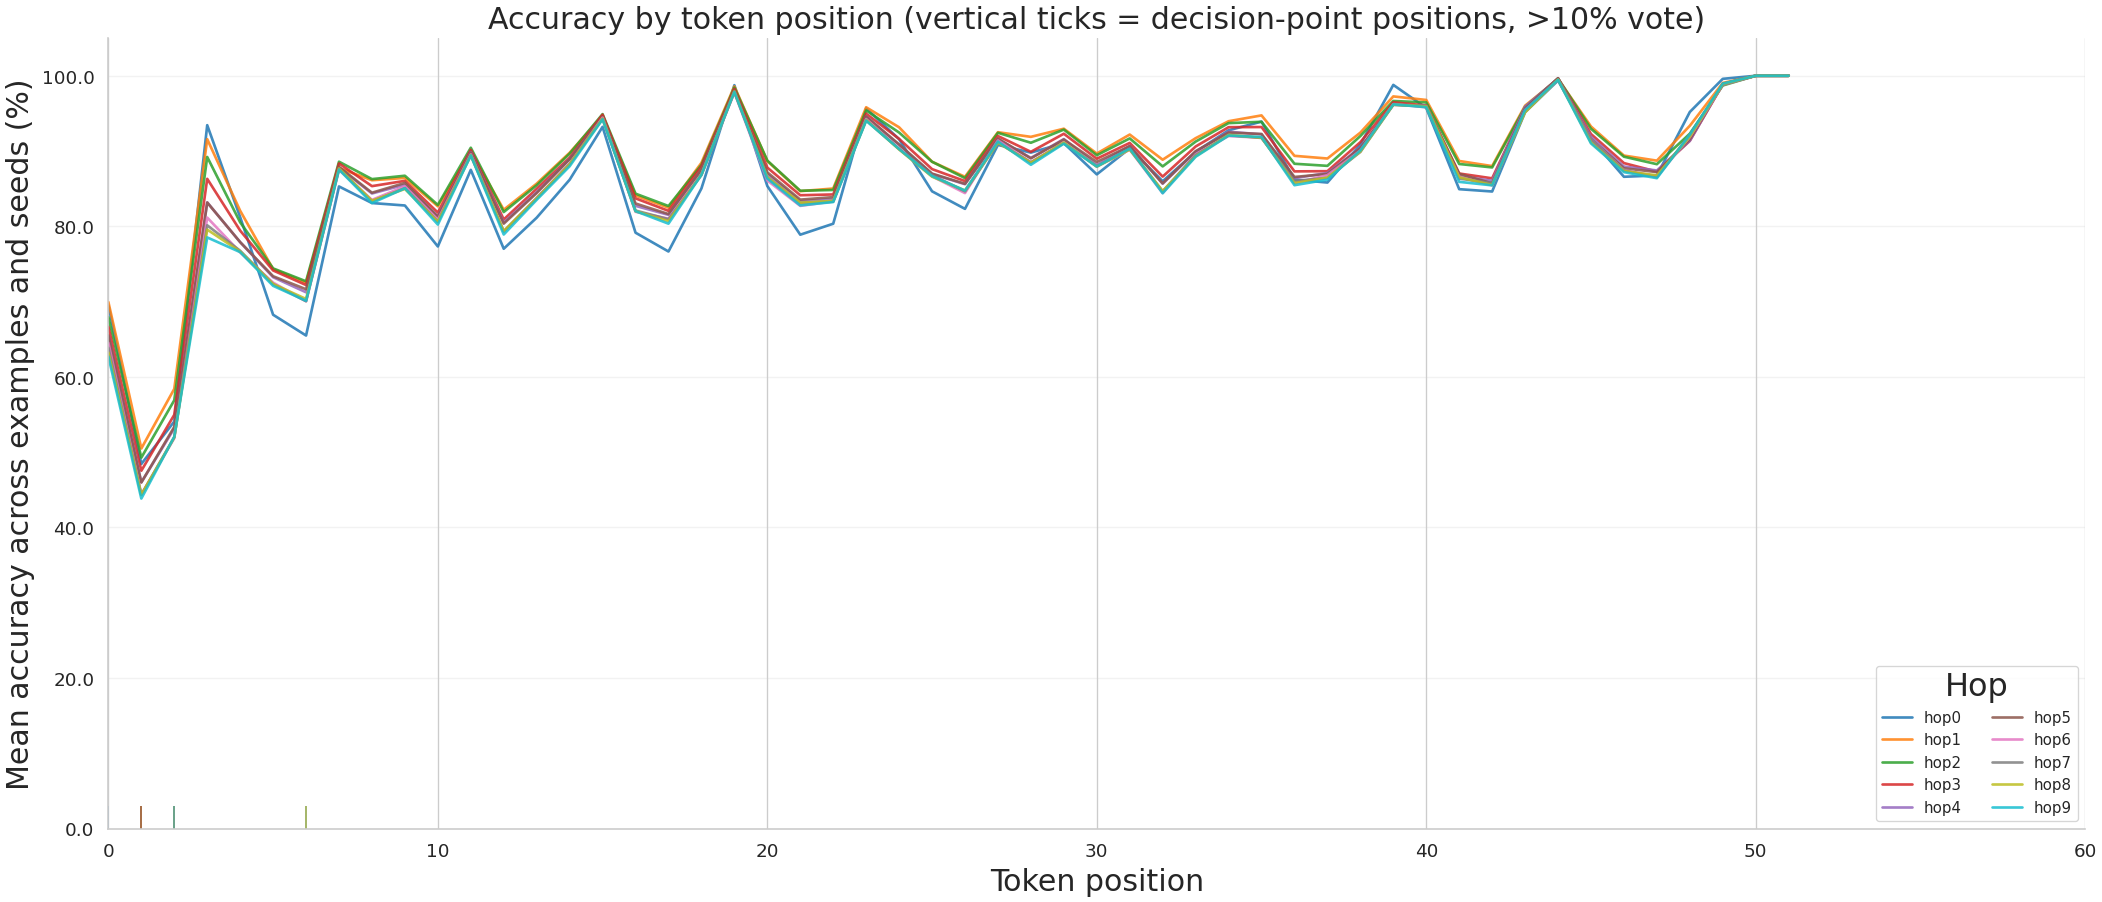

Saved /home/elisha_aims_ac_za/divergence-tokens/notebooks/eval-pref-with-stats/plots/qwen/panda-chain-mode-full/qwen_panda-chain-mode-full_dataset_accuracy_by_position_heatmap.png
Saved /home/elisha_aims_ac_za/divergence-tokens/notebooks/eval-pref-with-stats/plots/qwen/panda-chain-mode-full/qwen_panda-chain-mode-full_dataset_accuracy_by_position_heatmap.pdf


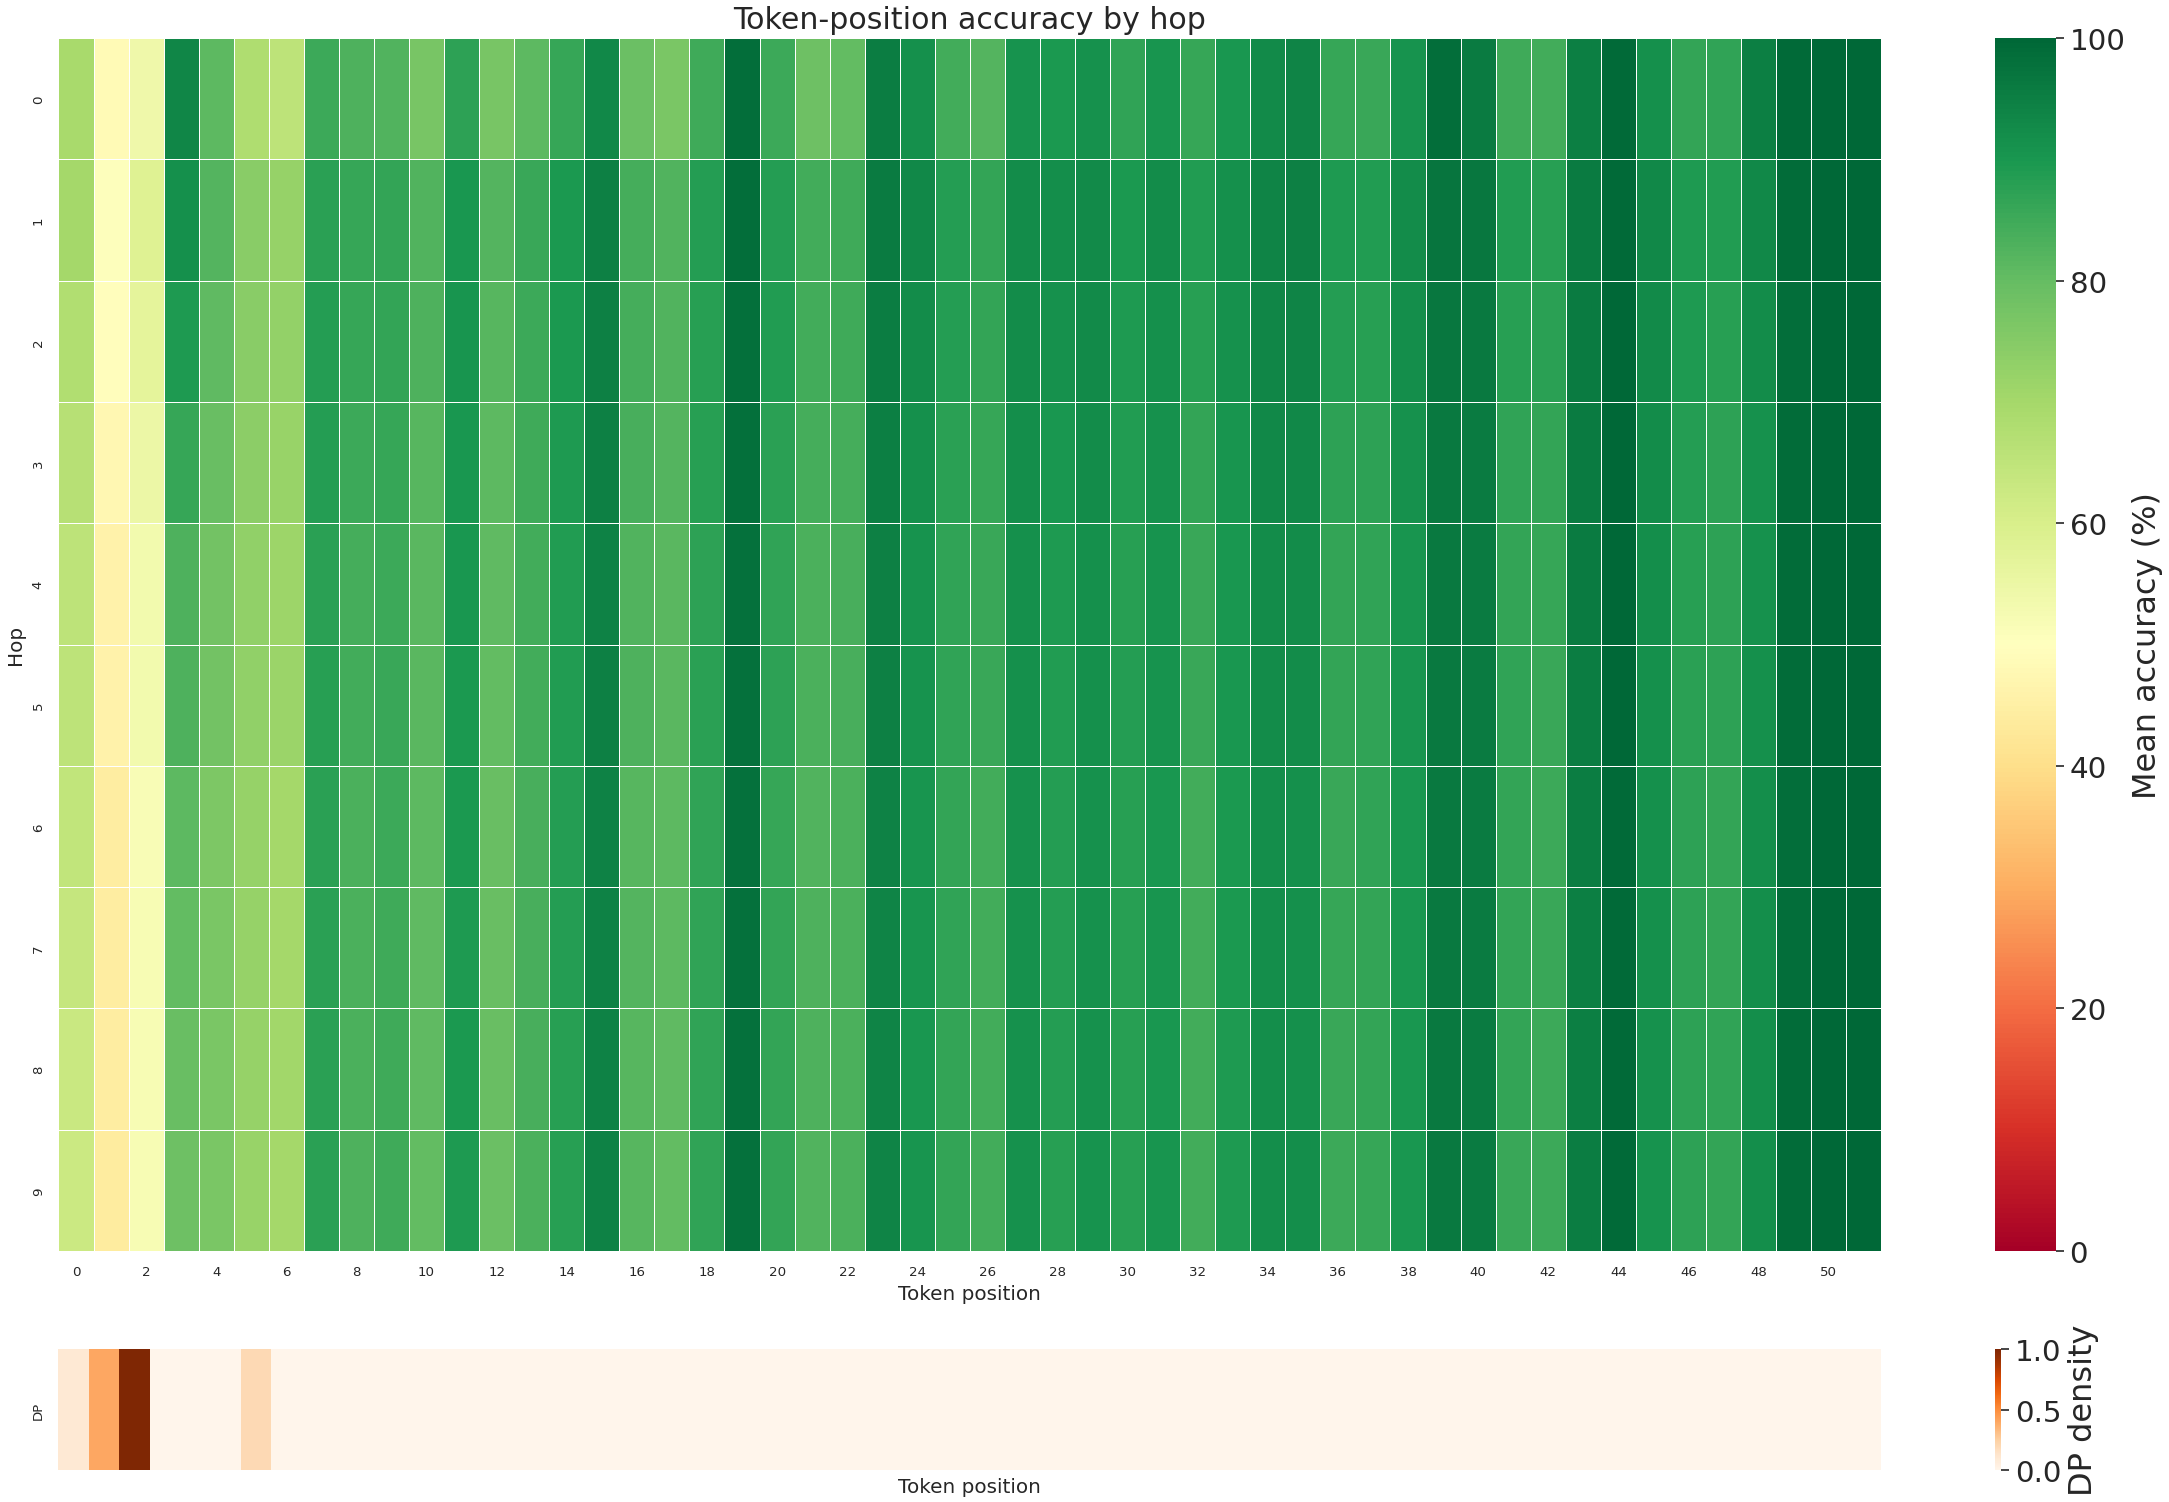

Dataset analysis plots saved to: /home/elisha_aims_ac_za/divergence-tokens/notebooks/eval-pref-with-stats/plots/qwen/panda-chain-mode-full
All sections complete.


In [ ]:
def plot_accuracy_by_position(position_df: pd.DataFrame, max_pos: int = 60) -> plt.Figure:
    """
    For each hop, plot mean accuracy at each token position.
    Decision-point positions (voted by >10% of examples) are marked with vertical ticks.
    """
    if position_df.empty:
        fig, ax = plt.subplots()
        ax.text(0.5, 0.5, 'No position accuracy data', ha='center', va='center')
        ax.axis('off')
        return fig

    hops = sorted(position_df['hop'].unique())
    cmap = plt.get_cmap('tab10')
    hop_colors = {hop: cmap(i % 10) for i, hop in enumerate(hops)}

    fig, ax = plt.subplots(figsize=(18, 8))

    for hop in hops:
        sub = position_df[(position_df['hop'] == hop) & (position_df['position'] < max_pos)].sort_values('position')
        if sub.empty:
            continue
        color = hop_colors[hop]
        ax.plot(sub['position'], sub['mean_accuracy'] * 100, color=color, linewidth=1.6, label=f'hop{hop}', alpha=0.85)

        # Mark decision-point positions with small ticks at the bottom
        dp_positions = sub[sub['is_decision_point']]['position'].values
        if len(dp_positions):
            ax.vlines(dp_positions, ymin=0, ymax=3, color=color, linewidth=1.0, alpha=0.5)

    set_common_axis_style(ax, 'Token position', 'Mean accuracy across examples and seeds (%)')
    ax.set_xlim(left=0, right=max_pos)
    ax.set_ylim(bottom=0, top=105)
    ax.set_title(
        f'Accuracy by token position (vertical ticks = decision-point positions, >10% vote)',
        fontsize=FONT_SIZES['axis_label_large'],
    )
    ax.legend(title='Hop', ncol=2, loc='lower right', fontsize=FONT_SIZES['legend_small'])
    fig.tight_layout()
    return fig


def plot_accuracy_by_position_heatmap(position_df: pd.DataFrame, max_pos: int = 60) -> plt.Figure:
    """
    Heatmap: rows = hops, columns = token positions, values = mean accuracy.
    Decision-point positions annotated with a small marker row.
    """
    if position_df.empty:
        fig, ax = plt.subplots()
        ax.text(0.5, 0.5, 'No position accuracy data', ha='center', va='center')
        ax.axis('off')
        return fig

    work = position_df[position_df['position'] < max_pos].copy()
    pivot = work.pivot_table(values='mean_accuracy', index='hop', columns='position', aggfunc='mean')
    pivot = pivot[sorted(pivot.columns)]
    pivot = pivot.reindex(sorted(pivot.index))
    pivot_pct = pivot * 100

    # Decision-point row: fraction of hops where this position is a decision point
    dp_row = work.groupby('position')['is_decision_point'].mean().reindex(sorted(work['position'].unique()))
    dp_row = dp_row.reindex(range(max_pos), fill_value=0.0)

    fig, (ax_heat, ax_dp) = plt.subplots(
        2, 1, figsize=(20, 6 + len(pivot_pct) * 0.7),
        gridspec_kw={'height_ratios': [len(pivot_pct), 1]},
    )

    sns.heatmap(
        pivot_pct, ax=ax_heat,
        cmap='RdYlGn', vmin=0, vmax=100,
        linewidths=0.3, linecolor='white',
        cbar_kws={'label': 'Mean accuracy (%)'},
        annot=False,
    )
    ax_heat.set_xlabel('Token position', fontsize=FONT_SIZES['axis_label'])
    ax_heat.set_ylabel('Hop', fontsize=FONT_SIZES['axis_label'])
    ax_heat.set_title('Token-position accuracy by hop', fontsize=FONT_SIZES['axis_label_large'])
    ax_heat.tick_params(labelsize=FONT_SIZES['helper_tick'])

    # Decision point density strip
    dp_display = dp_row.values[:max_pos].reshape(1, -1)
    sns.heatmap(
        dp_display, ax=ax_dp,
        cmap='Oranges', vmin=0, vmax=1,
        cbar_kws={'label': 'DP density'},
        linewidths=0, xticklabels=False,
        yticklabels=['DP'],
    )
    ax_dp.set_xlabel('Token position', fontsize=FONT_SIZES['axis_label'])
    ax_dp.tick_params(labelsize=FONT_SIZES['helper_tick'])

    fig.tight_layout()
    return fig


fig_pos_line = plot_accuracy_by_position(position_df, max_pos=60)
save_figure(fig_pos_line, f'{MODEL_NAME}_{PREFERENCE_TYPE}_dataset_accuracy_by_position')
plt.show()
plt.close(fig_pos_line)

fig_pos_heat = plot_accuracy_by_position_heatmap(position_df, max_pos=60)
save_figure(fig_pos_heat, f'{MODEL_NAME}_{PREFERENCE_TYPE}_dataset_accuracy_by_position_heatmap')
plt.show()
plt.close(fig_pos_heat)

print(f'Dataset analysis plots saved to: {OUTPUT_DIR}')
print(f'All sections complete.')

In [ ]:
# =============================================================================
# Decision Point Analysis — full dataset investigation
# =============================================================================

import re
from collections import Counter

def char_to_number_index(completion: str, char_pos: int) -> tuple[int | None, str | None]:
    """
    Given a char position in the completion, return which output number (0-indexed)
    it falls inside, and what that number string is.
    Numbers are found by regex so format-agnostic (newline, comma, bracket, semicolon).
    """
    for m in re.finditer(r'\d+', completion):
        if m.start() <= char_pos < m.end():
            return (list(re.finditer(r'\d+', completion)).index(m), m.group())
    return None, None


def analyze_decision_points(completion: str, decision_points: list[int]) -> dict:
    """
    For a single example, return a rich dict describing every decision point.
    """
    numbers = [(m.group(), m.start(), m.end()) for m in re.finditer(r'\d+', completion)]
    n_numbers = len(numbers)
    completion_len = len(completion)

    dp_details = []
    for dp in decision_points:
        detail = {
            'dp': dp,
            'in_range': dp < completion_len,
            'char': completion[dp] if dp < completion_len else None,
        }

        # Which number does this DP fall inside or immediately after?
        matched_num_idx = None
        matched_num_str = None
        position_within_number = None
        for num_idx, (num_str, start, end) in enumerate(numbers):
            if start <= dp < end:
                matched_num_idx = num_idx
                matched_num_str = num_str
                position_within_number = dp - start   # 0=first digit, 1=second, 2=third
                break
            # DP lands on separator AFTER this number (comma, space, newline, bracket)
            if dp == end or (end <= dp < end + 3 and dp < completion_len and not completion[dp].isdigit()):
                matched_num_idx = num_idx
                matched_num_str = num_str
                position_within_number = 'after'
                break

        detail['number_index'] = matched_num_idx          # which output number (0-based)
        detail['number_value'] = matched_num_str
        detail['position_within_number'] = position_within_number  # 0,1,2 = digit pos; 'after' = separator
        detail['context'] = completion[max(0, dp-5): dp+6]

        # Is this DP at the START of a number (first digit)?
        detail['is_first_digit'] = (position_within_number == 0)
        # Is this DP at the last digit of a number?
        detail['is_last_digit'] = (
            isinstance(position_within_number, int)
            and matched_num_str is not None
            and position_within_number == len(matched_num_str) - 1
        )

        dp_details.append(detail)

    # Derived summary
    dp_number_indices = [d['number_index'] for d in dp_details if d['number_index'] is not None]
    unique_numbers_with_dp = sorted(set(dp_number_indices))

    return {
        'completion': completion,
        'completion_len': completion_len,
        'n_output_numbers': n_numbers,
        'output_numbers': [num for num, _, _ in numbers],
        'n_decision_points': len(decision_points),
        'decision_points': decision_points,
        'dp_details': dp_details,
        'numbers_with_dp': unique_numbers_with_dp,       # which output numbers have at least one DP
        'fraction_numbers_with_dp': len(unique_numbers_with_dp) / n_numbers if n_numbers else 0,
        'all_dps_on_first_digit': all(d['is_first_digit'] for d in dp_details if d['in_range']),
        'all_dps_on_last_digit': all(d['is_last_digit'] for d in dp_details if d['in_range']),
        'digit_positions_hit': [d['position_within_number'] for d in dp_details],
    }


def analyze_dataset_file(path: Path, label: str = '', max_print: int = 5) -> pd.DataFrame:
    """
    Load a jsonl file and run analyze_decision_points on every example.
    Returns a flat DataFrame with one row per decision point.
    Also prints a human-readable summary.
    """
    examples = load_jsonl(path)
    if not examples:
        print(f'[{label}] No examples found at {path}')
        return pd.DataFrame()

    rows = []
    for ex_idx, ex in enumerate(examples):
        completion = ex.get('completion', '')
        dps = ex.get('decision_points', [])
        analysis = analyze_decision_points(completion, dps)

        # One row per DP (for easy aggregation)
        for dp_detail in analysis['dp_details']:
            rows.append({
                'file': label,
                'example_idx': ex_idx,
                'completion_len': analysis['completion_len'],
                'n_output_numbers': analysis['n_output_numbers'],
                'n_decision_points': analysis['n_decision_points'],
                'dp': dp_detail['dp'],
                'dp_char': dp_detail['char'],
                'number_index': dp_detail['number_index'],
                'number_value': dp_detail['number_value'],
                'position_within_number': dp_detail['position_within_number'],
                'is_first_digit': dp_detail['is_first_digit'],
                'is_last_digit': dp_detail['is_last_digit'],
                'context': dp_detail['context'],
                'in_range': dp_detail['in_range'],
            })

        # Also one row for examples with NO decision points
        if not dps:
            rows.append({
                'file': label,
                'example_idx': ex_idx,
                'completion_len': analysis['completion_len'],
                'n_output_numbers': analysis['n_output_numbers'],
                'n_decision_points': 0,
                'dp': None,
                'dp_char': None,
                'number_index': None,
                'number_value': None,
                'position_within_number': None,
                'is_first_digit': None,
                'is_last_digit': None,
                'context': None,
                'in_range': None,
            })

    df = pd.DataFrame(rows)

    # ------------------------------------------------------------------ summary
    print(f"\n{'='*70}")
    print(f"FILE: {label}  ({path.name})   examples={len(examples)}")
    print(f"{'='*70}")

    dp_rows = df[df['dp'].notna()]
    no_dp_examples = df[df['n_decision_points'] == 0]['example_idx'].nunique()

    print(f"  Examples total:              {len(examples)}")
    print(f"  Examples with 0 DPs:         {no_dp_examples}  ({100*no_dp_examples/len(examples):.1f}%)")
    print(f"  Examples with ≥1 DP:         {len(examples)-no_dp_examples}  ({100*(len(examples)-no_dp_examples)/len(examples):.1f}%)")
    print(f"  Total DP entries:            {len(dp_rows)}")
    if len(dp_rows):
        print(f"  DPs per example (mean):      {df.groupby('example_idx')['n_decision_points'].first().mean():.2f}")
        print(f"  DPs per example (median):    {df.groupby('example_idx')['n_decision_points'].first().median():.1f}")
        print(f"  DPs per example (max):       {df.groupby('example_idx')['n_decision_points'].first().max()}")
        print(f"  Out-of-range DPs:            {(~dp_rows['in_range']).sum()}")
        print()
        print(f"  Digit position breakdown (where in the 3-digit number does DP land?):")
        pos_counts = Counter(dp_rows['position_within_number'].tolist())
        for pos, cnt in sorted(pos_counts.items(), key=lambda x: str(x[0])):
            pct = 100 * cnt / len(dp_rows)
            print(f"    position={pos!r:12s}  count={cnt:6d}  ({pct:.1f}%)")
        print()
        print(f"  DP character breakdown (which char does the DP index land on?):")
        char_counts = Counter(dp_rows['dp_char'].tolist())
        for ch, cnt in sorted(char_counts.items(), key=lambda x: -x[1])[:15]:
            pct = 100 * cnt / len(dp_rows)
            print(f"    char={repr(ch):8s}  count={cnt:6d}  ({pct:.1f}%)")
        print()
        print(f"  Which output number index gets DPs? (0=first output number, 1=second...)")
        num_idx_counts = Counter(dp_rows['number_index'].dropna().astype(int).tolist())
        for idx, cnt in sorted(num_idx_counts.items()):
            pct = 100 * cnt / len(dp_rows)
            print(f"    output_number[{idx}]:  count={cnt:6d}  ({pct:.1f}%)")

    # Print a few concrete examples for manual inspection
    print(f"\n  --- First {max_print} examples (verbose) ---")
    for ex_idx, ex in enumerate(examples[:max_print]):
        completion = ex.get('completion', '')
        dps = ex.get('decision_points', [])
        a = analyze_decision_points(completion, dps)
        print(f"\n  ex[{ex_idx}] completion={repr(completion[:60])}{'...' if len(completion)>60 else ''}")
        print(f"          output numbers: {a['output_numbers']}")
        print(f"          decision_points: {dps}")
        for d in a['dp_details']:
            print(f"            dp={d['dp']:3d} → char={repr(d['char'])} | "
                  f"output_number[{d['number_index']}]={d['number_value']} | "
                  f"digit_pos={d['position_within_number']} | "
                  f"context={repr(d['context'])}")
        if not dps:
            print(f"            (no decision points)")

    return df


# =============================================================================
# Run on all hops and all three dataset splits
# =============================================================================

all_dp_dfs = []

for hop in sorted(hop_data.keys()):
    hop_dir = PARENT_DIR / f'hop{hop}'
    for fname, label_suffix in [
        ('filtered_dataset.jsonl',            'filtered'),
        ('filtered_dataset_dpoints_only.jsonl', 'dpoints_only'),
        ('raw_dataset.jsonl',                 'raw'),
    ]:
        fpath = hop_dir / fname
        if not fpath.exists():
            continue
        df_part = analyze_dataset_file(fpath, label=f'hop{hop}/{label_suffix}', max_print=3)
        if not df_part.empty:
            df_part['hop'] = hop
            df_part['split'] = label_suffix
            all_dp_dfs.append(df_part)

full_dp_df = pd.concat(all_dp_dfs, ignore_index=True) if all_dp_dfs else pd.DataFrame()

print(f"\n\n{'='*70}")
print(f"AGGREGATE SUMMARY across all hops and splits")
print(f"{'='*70}")
if not full_dp_df.empty:
    dp_only = full_dp_df[full_dp_df['dp'].notna()]
    print(f"Total DP entries across all files: {len(dp_only)}")
    print()
    print("Digit position hit (aggregated across all hops/splits):")
    display(
        dp_only.groupby(['split', 'position_within_number'])
        .size().rename('count').reset_index()
        .pivot_table(values='count', index='split', columns='position_within_number', fill_value=0)
    )
    print()
    print("DPs per example by hop and split (mean):")
    display(
        full_dp_df.groupby(['hop', 'split', 'example_idx'])['n_decision_points']
        .first().reset_index()
        .groupby(['hop', 'split'])['n_decision_points']
        .agg(['mean', 'median', 'max', lambda x: (x == 0).mean()])
        .rename(columns={'<lambda_0>': 'frac_zero'})
        .round(3)
    )


FILE: hop0/filtered  (filtered_dataset.jsonl)   examples=27633
  Examples total:              27633
  Examples with 0 DPs:         27633  (100.0%)
  Examples with ≥1 DP:         0  (0.0%)
  Total DP entries:            0

  --- First 3 examples (verbose) ---

  ex[0] completion='785\n672\n489\n563\n392\n874\n651\n437\n762\n389'
          output numbers: ['785', '672', '489', '563', '392', '874', '651', '437', '762', '389']
          decision_points: []
            (no decision points)

  ex[1] completion='(678, 592, 814, 703, 656, 732, 821, 689, 754, 587)'
          output numbers: ['678', '592', '814', '703', '656', '732', '821', '689', '754', '587']
          decision_points: []
            (no decision points)

  ex[2] completion='694 656 712 748 670 686 702 728 662 648'
          output numbers: ['694', '656', '712', '748', '670', '686', '702', '728', '662', '648']
          decision_points: []
            (no decision points)

FILE: hop0/dpoints_only  (filtered_dataset_dpoints_on

position_within_number,0,1,2,after
split,,,,
dpoints_only,172277.0,193227.0,190963.0,46608.0



DPs per example by hop and split (mean):


mean  median  max  frac_zero
hop split                                      
0   dpoints_only  2.139     2.0   12      0.168
    filtered      0.000     0.0    0      1.000
    raw           0.000     0.0    0      1.000
1   dpoints_only  2.286     2.0   13      0.164
    filtered      0.000     0.0    0      1.000
    raw           0.000     0.0    0      1.000
2   dpoints_only  2.173     2.0   12      0.177
    filtered      0.000     0.0    0      1.000
    raw           0.000     0.0    0      1.000
3   dpoints_only  2.084     2.0   12      0.186
    filtered      0.000     0.0    0      1.000
    raw           0.000     0.0    0      1.000
4   dpoints_only  2.025     2.0   12      0.193
    filtered      0.000     0.0    0      1.000
    raw           0.000     0.0    0      1.000
5   dpoints_only  2.017     2.0   13      0.192
    filtered      0.000     0.0    0      1.000
    raw           0.000     0.0    0      1.000
6   dpoints_only  1.963     2.0   13      0.198
    filtered      0.000     0.0    0      1.000
    raw           0.000     0.0    0      1.000
7   dpoints_only  1.960     2.0   13      0.198
    filtered      0.000     0.0    0      1.000
    raw           0.000     0.0    0      1.000
8   dpoints_only  1.962     2.0   13      0.198
    filtered      0.000     0.0    0      1.000
    raw           0.000     0.0    0      1.000
9   dpoints_only  1.958     2.0   12      0.197
    filtered      0.000     0.0    0      1.000
    raw           0.000     0.0    0      1.000

In [ ]:
# =============================================================================
# Decision Point Analysis — dpoints_only files only
# =============================================================================

all_dp_dfs = []

for hop in sorted(hop_data.keys()):
    hop_dir = PARENT_DIR / f'hop{hop}'
    fpath = hop_dir / 'filtered_dataset_dpoints_only.jsonl'
    if not fpath.exists():
        print(f'hop{hop}: filtered_dataset_dpoints_only.jsonl not found, skipping')
        continue
    df_part = analyze_dataset_file(fpath, label=f'hop{hop}', max_print=3)
    if not df_part.empty:
        df_part['hop'] = hop
        all_dp_dfs.append(df_part)

full_dp_df = pd.concat(all_dp_dfs, ignore_index=True) if all_dp_dfs else pd.DataFrame()


FILE: hop0  (filtered_dataset_dpoints_only.jsonl)   examples=27633
  Examples total:              27633
  Examples with 0 DPs:         4651  (16.8%)
  Examples with ≥1 DP:         22982  (83.2%)
  Total DP entries:            59113
  DPs per example (mean):      2.14
  DPs per example (median):    2.0
  DPs per example (max):       12
  Out-of-range DPs:            -117500

  Digit position breakdown (where in the 3-digit number does DP land?):
    position=0             count= 17823  (30.2%)
    position=1             count= 19502  (33.0%)
    position=2             count= 19099  (32.3%)
    position=None          count=   109  (0.2%)
    position='after'       count=  2580  (4.4%)

  DP character breakdown (which char does the DP index land on?):
    char='3'       count=  6841  (11.6%)
    char='4'       count=  6409  (10.8%)
    char='2'       count=  6386  (10.8%)
    char='8'       count=  6365  (10.8%)
    char='5'       count=  5978  (10.1%)
    char='7'       count=  5806  (9

In [ ]:
print(f"\n\n{'='*70}")
print(f"AGGREGATE SUMMARY across all hops (dpoints_only)")
print(f"{'='*70}")

if not full_dp_df.empty:
    dp_only = full_dp_df[full_dp_df['dp'].notna()]

    print(f"Total DP entries across all hops: {len(dp_only)}")
    print(f"Total examples across all hops:   {full_dp_df.groupby(['hop','example_idx']).ngroups}")
    print()

    print("Digit position hit — where in the 3-digit number does DP land?")
    display(
        dp_only.groupby(['hop', 'position_within_number'])
        .size().rename('count').reset_index()
        .pivot_table(values='count', index='hop', columns='position_within_number', fill_value=0)
    )
    print()

    print("DPs per example by hop (mean / median / max / frac_zero):")
    display(
        full_dp_df.groupby(['hop', 'example_idx'])['n_decision_points']
        .first().reset_index()
        .groupby('hop')['n_decision_points']
        .agg(['mean', 'median', 'max', lambda x: (x == 0).mean()])
        .rename(columns={'<lambda_0>': 'frac_zero'})
        .round(3)
    )
    print()

    print("Which output number index gets DPs? (0=first output number generated)")
    display(
        dp_only.groupby(['hop', 'number_index'])
        .size().rename('count').reset_index()
        .pivot_table(values='count', index='hop', columns='number_index', fill_value=0)
    )
    print()

    print("DP character breakdown aggregated across all hops:")
    char_counts = Counter(dp_only['dp_char'].tolist())
    for ch, cnt in sorted(char_counts.items(), key=lambda x: -x[1])[:15]:
        pct = 100 * cnt / len(dp_only)
        print(f"  char={repr(ch):8s}  count={cnt:6d}  ({pct:.1f}%)")



AGGREGATE SUMMARY across all hops (dpoints_only)
Total DP entries across all hops: 604237
Total examples across all hops:   293953

Digit position hit — where in the 3-digit number does DP land?


position_within_number,0,1,2,after
hop,,,,
0,17823.0,19502.0,19099.0,2580.0
1,19130.0,21994.0,21838.0,3309.0
2,18273.0,21100.0,20783.0,3825.0
3,17528.0,19973.0,19698.0,4324.0
4,17031.0,19036.0,19040.0,4872.0
5,17017.0,18900.0,18907.0,4881.0
6,16508.0,18180.0,18111.0,5336.0
7,16421.0,18135.0,17967.0,5610.0
8,16283.0,18275.0,17783.0,5838.0



DPs per example by hop (mean / median / max / frac_zero):


,mean,median,max,frac_zero
hop,,,,
0,2.139,2.0,12,0.168
1,2.286,2.0,13,0.164
2,2.173,2.0,12,0.177
3,2.084,2.0,12,0.186
4,2.025,2.0,12,0.193
5,2.017,2.0,13,0.192
6,1.963,2.0,13,0.198
7,1.960,2.0,13,0.198
8,1.962,2.0,13,0.198



Which output number index gets DPs? (0=first output number generated)


number_index,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0
hop,,,,,,,,,,
0,9958.0,8074.0,6929.0,6378.0,5818.0,5164.0,4974.0,4502.0,3666.0,3541.0
1,10252.0,9264.0,7885.0,7146.0,6831.0,6278.0,5488.0,4939.0,4228.0,3960.0
2,9890.0,9267.0,7716.0,6898.0,6499.0,5867.0,5218.0,4742.0,4124.0,3760.0
3,9555.0,8816.0,7578.0,6665.0,6216.0,5607.0,4914.0,4602.0,3950.0,3620.0
4,9376.0,8742.0,7439.0,6421.0,6077.0,5445.0,4905.0,4477.0,3728.0,3369.0
5,9351.0,8645.0,7414.0,6436.0,6029.0,5383.0,4850.0,4394.0,3744.0,3459.0
6,9064.0,8477.0,7196.0,6327.0,5833.0,5370.0,4723.0,4232.0,3576.0,3337.0
7,9052.0,8457.0,7296.0,6337.0,5845.0,5405.0,4726.0,4136.0,3583.0,3296.0
8,9003.0,8581.0,7374.0,6206.0,5924.0,5382.0,4749.0,4165.0,3544.0,3251.0



DP character breakdown aggregated across all hops:
  char='3'       count= 68986  (11.4%)
  char='2'       count= 66850  (11.1%)
  char='4'       count= 61880  (10.2%)
  char='8'       count= 61335  (10.2%)
  char='5'       count= 59373  (9.8%)
  char='6'       count= 55564  (9.2%)
  char='7'       count= 55479  (9.2%)
  char='1'       count= 52993  (8.8%)
  char='9'       count= 50884  (8.4%)
  char='0'       count= 23123  (3.8%)
  char=' '       count= 18136  (3.0%)
  char='\n'      count= 10939  (1.8%)
  char=','       count=  9370  (1.6%)
  char=nan       count=  4953  (0.8%)
  char=';'       count=  2494  (0.4%)
